# Weather Data Retrieval Testing

The purpose of this notebook is to test the outputs of the weather data retrieval module to ensure data is in the correct format, and retrieved as requested.

### Importing Libraries

In [1]:
import numpy as np
import polars as pl
import pandas as pd

import geopandas as gpd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from datetime import date as dt_date, datetime as dt_datetime, timedelta
from dateutil.parser import parse as parse_dt

import os
import math
import zipfile
import magic
from pathlib import Path

from PIL import Image
import imageio.v2 as iio


### Helper Functions

In [2]:
def show_dir_contents(path='.'):
    """List contents of current directory"""
    base = Path(path).resolve()
    print("Contents of current directory:")
    for p in base.rglob('*'):
        print("  -> " + str(p.relative_to(base)))

In [3]:
def print_directory_tree(start_path='.', show_files=False):
    """Print directory tree similar to 'tree' command"""
    for root, dirs, files in os.walk(start_path):
        # Calculate indentation
        level = root.replace(start_path, '').count(os.sep)
        indent = '│   ' * level

        if root == start_path:
            print(f"📁 {os.path.basename(root) or '.'}")
        else:
            print(f"{indent}└── 📁 {os.path.basename(root)}")

        subindent = '│   ' * (level + 1)

        if show_files:
            for f in sorted(files):
                print(f"{subindent}└── 📄 {f}")

In [4]:
def get_mime_type(path):
    """Get MIME type of file using python-magic"""
    m = magic.Magic(mime=True)
    return m.from_file(path)


In [5]:
def read_magic(path, n=8):
    """Read first n bytes of file to determine MIME type"""
    with open(path, 'rb') as f:
        return f.read(n)

In [6]:
def is_grib(path):
    """Check if file is GRIB by reading first 4 bytes"""
    try:
        with open(path, 'rb') as f:
            return f.read(4) == b'GRIB'
    except OSError:
        return False

In [7]:
def is_zip(path):
    """Check if file is ZIP by using zipfile module"""
    return zipfile.is_zipfile(path)

In [8]:
def testing_filepaths(path):
    print(f"Testing filepath for [{os.path.basename(path)}]:")
    print(f"  - MIME type: {get_mime_type(path)}")
    print(f"  - Magic bytes: {read_magic(path)}")

#### Visualisations

In [9]:
def plot_day_polars_direct(df, date, column):
    """
    Plot directly from Polars without pandas conversion
    """
    # Ensure timestamp is datetime and filter
    df = df.with_columns(pl.col('time').cast(pl.Datetime))
    target_date = pd.to_datetime(date).date()
    day_data = df.filter(pl.col('time').dt.date() == target_date)

    # Extract data as numpy arrays
    timestamps = day_data['time'].to_numpy()
    values = day_data[column].to_numpy()

    plt.figure(figsize=(12, 5))
    plt.plot(timestamps, values, marker='o', linestyle='-', markersize=3)
    plt.title(f'{column.replace("_", " ").title()} on {date}')
    plt.xlabel('Time')
    plt.ylabel(column.replace('_', ' ').title())
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return day_data


In [10]:
def plot_polars_time_series_grid(
    df: pl.DataFrame | pl.LazyFrame,
    plot_specs: list[dict],
    *,
    max_cols: int = 3,
    figsize_per_col: float = 5.5,
    figsize_per_row: float = 4.4,
    marker: str = "o",
    linestyle: str = "-",
    markersize: float = 3,
    linewidth: float = 1.2,
    sharex: bool = False,
    sharey: bool = False,
    sort_time: bool = True,
    hide_empty_axes: bool = True,
    title_fontsize: float = 11,
    subtitle_fontsize: float = 8.5,
    title_pad: float = 18,
    multiseries_alpha: float = 0.25,
    multiseries_linewidth: float = 0.9,
    percentile_shading: bool = True,
    shade_lower_percentile: float = 25,
    shade_upper_percentile: float = 75,
    shade_alpha: float = 0.3,
    shade_color: str = None,
    format_y_axes: bool = True,  # New flag for y-axis formatting
    y_padding_percent: float = 10,  # Percentage padding above max
    y_force_zero_bottom: bool = True,  # Force y-axis to start at 0 if all values >= 0
):
    """
    Plot one or more variables from a Polars DataFrame/LazyFrame as a grid of subplots.

    Each plot spec can define:
    - variables
    - optional filters
    - optional start timestamp
    - optional window_hours (default 24)
    - optional date shorthand (equivalent to start at 00:00)
    - optional title_prefix
    - optional avg_multiseries flag

    Supported keys in each spec
    ---------------------------
    - "variables": str | list[str]            Required
    - "filters": pl.Expr | list[pl.Expr]      Optional
    - "start": str | datetime                 Optional
    - "window_hours": int | float             Optional, default 24
    - "date": str | date | datetime           Optional shorthand for start at 00:00
    - "title_prefix": str                     Optional
    - "avg_multiseries": bool                  Optional, default False

    Multi-series behavior
    ---------------------
    If filtered data contains multiple (latitude, longitude) series:

    - avg_multiseries=False:
        Plot each series separately with light overlay.
    - avg_multiseries=True:
        Plot the mean line across all series with percentile shading.

    Y-axis formatting (when format_y_axes=True):
    - Bottom: Starts at 0 if all values are >= 0, otherwise uses matplotlib's default
    - Top: Adds y_padding_percent% headroom above the maximum value

    Returns
    -------
    fig, axes_flat, extracted_data
        fig : matplotlib Figure
        axes_flat : flattened array of axes
        extracted_data : dict[str, pl.DataFrame]
    """
    if not plot_specs:
        raise ValueError("plot_specs must contain at least one spec.")

    lf = df.lazy() if isinstance(df, pl.DataFrame) else df
    schema_names = lf.collect_schema().names()

    if "time" not in schema_names:
        raise ValueError("Input data must contain a 'time' column.")

    has_latlon = ("latitude" in schema_names) and ("longitude" in schema_names)

    def _normalize_filters(filters):
        if filters is None:
            return []
        if isinstance(filters, pl.Expr):
            return [filters]
        if isinstance(filters, (list, tuple)):
            return list(filters)
        raise TypeError(
            "'filters' must be None, a Polars expression, or a list/tuple of expressions."
        )

    def _normalize_start(value):
        if value is None:
            return None
        if isinstance(value, dt_datetime):
            return value
        if isinstance(value, dt_date):
            return dt_datetime.combine(value, dt_datetime.min.time())
        if isinstance(value, str):
            return parse_dt(value)
        raise TypeError("'start' must be None, str, date, or datetime.")

    def _normalize_date_to_start(value):
        if value is None:
            return None
        if isinstance(value, dt_datetime):
            return dt_datetime.combine(value.date(), dt_datetime.min.time())
        if isinstance(value, dt_date):
            return dt_datetime.combine(value, dt_datetime.min.time())
        if isinstance(value, str):
            parsed = parse_dt(value)
            return dt_datetime.combine(parsed.date(), dt_datetime.min.time())
        raise TypeError("'date' must be None, str, date, or datetime.")

    def _build_title_lines(
        variable: str,
        title_prefix: str = "",
        start: dt_datetime | None = None,
        end: dt_datetime | None = None,
        avg_multiseries: bool = False,
        n_series: int = 1,
    ) -> tuple[str, str | None]:
        line1 = variable if not title_prefix else f"{variable} | {title_prefix}"

        if n_series > 1:
            if avg_multiseries:
                line1 = f"{line1} | mean of {n_series} series"
            else:
                line1 = f"{line1} | {n_series} series"

        if start is not None and end is not None:
            line2 = f"{start:%Y-%m-%d %H:%M} to {end:%Y-%m-%d %H:%M}"
            return line1, line2

        return line1, None

    def _format_y_axis(ax, values, padding_percent=10, force_zero_bottom=True):
        """Apply consistent y-axis formatting"""
        if len(values) == 0:
            return

        vmin = np.min(values)
        vmax = np.max(values)

        # Add padding to top
        padding = vmax * (padding_percent / 100)
        new_top = vmax + padding

        # Determine bottom limit
        if force_zero_bottom and vmin >= 0:
            new_bottom = 0
        else:
            # Add small padding to bottom as well if values go negative
            bottom_padding = abs(vmin) * (padding_percent / 100) if vmin < 0 else 0
            new_bottom = vmin - bottom_padding

        ax.set_ylim(bottom=new_bottom, top=new_top)

    # Expand grouped specs into one panel per variable
    panels = []
    for spec_idx, spec in enumerate(plot_specs, start=1):
        if "variables" not in spec:
            raise ValueError(f"Spec {spec_idx} is missing the 'variables' key.")

        variables = spec["variables"]
        if isinstance(variables, str):
            variables = [variables]

        filters = _normalize_filters(spec.get("filters"))
        title_prefix = spec.get("title_prefix", "")
        window_hours = spec.get("window_hours", 24)
        avg_multiseries = spec.get("avg_multiseries", False)

        if window_hours <= 0:
            raise ValueError(f"Spec {spec_idx}: 'window_hours' must be positive.")

        start = _normalize_start(spec.get("start"))
        if start is None and "date" in spec:
            start = _normalize_date_to_start(spec.get("date"))

        end = start + timedelta(hours=window_hours) if start is not None else None

        for var in variables:
            if var not in schema_names:
                raise ValueError(f"Column '{var}' not found in input schema.")

            panels.append(
                {
                    "variable": var,
                    "filters": filters,
                    "start": start,
                    "end": end,
                    "title_prefix": title_prefix,
                    "avg_multiseries": avg_multiseries,
                }
            )

    n_panels = len(panels)
    if n_panels == 1:
        ncols = 1
    elif n_panels == 2:
        ncols = 2
    else:
        ncols = min(max_cols, 3, n_panels)

    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_col * ncols, figsize_per_row * nrows),
        sharex=sharex,
        sharey=sharey,
        squeeze=False,
        constrained_layout=True,
    )
    axes_flat = axes.flatten()

    extracted_data = {}

    for ax, panel in zip(axes_flat, panels):
        var = panel["variable"]
        filters = panel["filters"]
        start = panel["start"]
        end = panel["end"]
        title_prefix = panel["title_prefix"]
        avg_multiseries = panel["avg_multiseries"]

        q = lf.with_columns(pl.col("time").cast(pl.Datetime("us")))

        for expr in filters:
            q = q.filter(expr)

        if start is not None:
            q = q.filter(
                (pl.col("time") >= pl.lit(start)) &
                (pl.col("time") < pl.lit(end))
            )

        select_cols = ["time", var]
        if has_latlon:
            select_cols += ["latitude", "longitude"]

        q = q.select(select_cols)

        if sort_time:
            sort_cols = ["time"]
            if has_latlon:
                sort_cols = ["latitude", "longitude", "time"]
            q = q.sort(sort_cols)

        subset = q.collect()

        # Detect number of remaining series
        if has_latlon:
            n_series = subset.select(["latitude", "longitude"]).unique().height
        else:
            # Fallback if no lat/lon columns exist
            # Multiple rows per timestamp implies multiple series/observations
            max_rows_per_time = (
                subset.group_by("time")
                .agg(pl.len().alias("n"))
                .select(pl.col("n").max())
                .item()
            )
            n_series = max_rows_per_time if max_rows_per_time is not None else 1

        line1, line2 = _build_title_lines(
            variable=var,
            title_prefix=title_prefix,
            start=start,
            end=end,
            avg_multiseries=avg_multiseries,
            n_series=n_series,
        )
        title_key = line1 if line2 is None else f"{line1} | {line2}"

        ax.set_title(
            line1,
            pad=title_pad,
            fontsize=title_fontsize,
            fontweight="bold",
        )
        if line2 is not None:
            ax.text(
                0.5,
                1.02,
                line2,
                transform=ax.transAxes,
                ha="center",
                va="bottom",
                fontsize=subtitle_fontsize,
            )

        # Store the original data (always store the raw subset)
        extracted_data[title_key] = subset

        if subset.height == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=11,
            )
            ax.grid(True, alpha=0.3)
            continue

        # Collect values for y-axis formatting
        all_values = []

        # Plot logic
        if n_series <= 1:
            timestamps = subset["time"].to_numpy()
            values = subset[var].to_numpy()
            all_values.extend(values)

            ax.plot(
                timestamps,
                values,
                marker=marker,
                linestyle=linestyle,
                markersize=markersize,
                linewidth=linewidth,
            )

        elif avg_multiseries:
            # Calculate statistics across series at each timestamp
            stats_df = (
                subset.group_by("time")
                .agg([
                    pl.col(var).mean().alias("mean"),
                    pl.col(var).quantile(shade_lower_percentile/100).alias("lower"),
                    pl.col(var).quantile(shade_upper_percentile/100).alias("upper"),
                    pl.col(var).min().alias("min"),
                    pl.col(var).max().alias("max"),
                    pl.col(var).count().alias("count")
                ])
                .sort("time")
            )

            timestamps = stats_df["time"].to_numpy()
            mean_values = stats_df["mean"].to_numpy()
            lower_values = stats_df["lower"].to_numpy()
            upper_values = stats_df["upper"].to_numpy()

            # Collect all relevant values for y-axis formatting
            all_values.extend(mean_values)
            all_values.extend(lower_values)
            all_values.extend(upper_values)

            # Plot the mean line
            line = ax.plot(
                timestamps,
                mean_values,
                marker=marker,
                linestyle=linestyle,
                markersize=markersize,
                linewidth=linewidth,
                label=f"Mean (n={stats_df['count'].mean():.0f} series)"
            )[0]

            # Add percentile shading
            if percentile_shading:
                shade_color = shade_color or line.get_color()
                ax.fill_between(
                    timestamps,
                    lower_values,
                    upper_values,
                    alpha=shade_alpha,
                    color=shade_color,
                    label=f"{shade_lower_percentile:.0f}-{shade_upper_percentile:.0f}th percentile"
                )

            ax.legend(loc='upper right', fontsize=8)

        else:
            # Plot each series separately
            if has_latlon:
                grouped = subset.partition_by(["latitude", "longitude"], maintain_order=True)

                for g in grouped:
                    timestamps = g["time"].to_numpy()
                    values = g[var].to_numpy()
                    all_values.extend(values)

                    ax.plot(
                        timestamps,
                        values,
                        marker=None,
                        linestyle=linestyle,
                        linewidth=multiseries_linewidth,
                        alpha=multiseries_alpha,
                    )
            else:
                # Fallback if no lat/lon - assume each row is a separate series
                # Group by time to identify unique timestamps
                unique_times = subset["time"].unique().sort()

                # If we have multiple rows per timestamp, treat each as separate series
                if len(unique_times) * n_series == len(subset):
                    # We can reconstruct series by their position within each timestamp
                    for series_idx in range(n_series):
                        series_data = subset.group_by("time", maintain_order=True).agg(
                            pl.col(var).nth(series_idx).alias(var)
                        ).sort("time")

                        timestamps = series_data["time"].to_numpy()
                        values = series_data[var].to_numpy()
                        all_values.extend(values)

                        ax.plot(
                            timestamps,
                            values,
                            marker=None,
                            linestyle=linestyle,
                            linewidth=multiseries_linewidth,
                            alpha=multiseries_alpha,
                        )
                else:
                    # Simple fallback - just plot all points
                    timestamps = subset["time"].to_numpy()
                    values = subset[var].to_numpy()
                    all_values.extend(values)

                    ax.plot(
                        timestamps,
                        values,
                        marker=None,
                        linestyle=linestyle,
                        linewidth=multiseries_linewidth,
                        alpha=multiseries_alpha,
                    )

        ax.set_xlabel("Time")
        ax.set_ylabel(var)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=45)

        # Apply y-axis formatting if enabled
        if format_y_axes and len(all_values) > 0:
            _format_y_axis(ax, np.array(all_values), y_padding_percent, y_force_zero_bottom)

        if start is not None:
            ax.set_xlim(start, end)

    for ax in axes_flat[n_panels:]:
        if hide_empty_axes:
            ax.set_visible(False)

    plt.show()

    return fig, axes_flat, extracted_data

### Defining Filepaths

#### Checking Directory Structure

In [11]:
!pwd

/Users/Daniel/Desktop/open-source-marginal-emissions.nosync/notebooks


In [12]:
current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)
# print_directory_tree(start_path=base_dir, show_files=False)

In [13]:
# # RDS / HPC working
# project_dir = current_dir + '/open-source-marginal-emissions'
# data_dir = project_dir + '/data'
# era5_dir = data_dir + '/era5-world'
# interim_dir = era5_dir + '/interim'
# processed_dir = era5_dir + '/processed'
# raw_dir = era5_dir + '/raw'

# interim_consolidation_dir = interim_dir + '/consolidation'
# interim_interpolated_dir = interim_dir + '/interpolated'
# interim_masked_dir = interim_dir + '/masked'

In [14]:
data_dir = base_dir + "/data"
show_dir_contents(data_dir)
era5_dir = data_dir + '/era5-world'
interim_dir = era5_dir + '/interim'
processed_dir = era5_dir + '/processed'
raw_dir = era5_dir + '/raw'

interim_consolidation_dir = interim_dir + '/consolidation'
interim_interpolated_dir = interim_dir + '/interpolated'
interim_masked_dir = interim_dir + '/masked'

Contents of current directory:
  -> .DS_Store
  -> README.md
  -> grid_data
  -> geoBoundaries
  -> era5-world
  -> era5-land
  -> grid_data/.DS_Store
  -> grid_data/processed
  -> grid_data/raw
  -> grid_data/processed/.DS_Store
  -> grid_data/processed/carbontracker_grid-data_2018-11_2026-02_step2_half-hourly.parquet
  -> grid_data/processed/carbontracker_grid-data_2018-11_2026-02_step3_final.parquet
  -> grid_data/processed/carbontracker_grid-data_2018-11_2026-02_step1_gapfilled.parquet
  -> grid_data/processed/gap_filling_checkpoints
  -> grid_data/processed/gap_filling_checkpoints/.DS_Store
  -> grid_data/processed/gap_filling_checkpoints/checkpoint_step03_linear_40min.parquet
  -> grid_data/processed/gap_filling_checkpoints/checkpoint_step04_gradient_pass2.parquet
  -> grid_data/processed/gap_filling_checkpoints/checkpoint_step01_linear_80min.parquet
  -> grid_data/processed/gap_filling_checkpoints/checkpoint_step02_gradient_pass1.parquet
  -> grid_data/raw/.DS_Store
  -> grid_da

In [15]:
# RDS / HPC working
print(processed_dir)
show_dir_contents(processed_dir)

/Users/Daniel/Desktop/open-source-marginal-emissions.nosync/data/era5-world/processed
Contents of current directory:
  -> .DS_Store
  -> ADM0
  -> ADM0/.DS_Store
  -> ADM0/era5-world_INDIA_916d3fbb_2018_ADM0_halfhourly.parquet


#### Defining GeoFilepaths

In [15]:
# geoboundaries_folder = data_dir + "geoBoundaries/"
geoboundaries_folder = data_dir + "/geoBoundaries"

show_dir_contents(geoboundaries_folder)

Contents of current directory:
  -> geoBoundariesCGAZ_ADM1.zip
  -> geoBoundariesCGAZ_ADM0.zip
  -> geoBoundariesCGAZ_ADM2.zip
  -> .DS_Store
  -> images
  -> extracted
  -> masks
  -> images/.DS_Store
  -> images/era5-world_INDIA_mask_overview.png
  -> images/era5-world_INDIA_mask_combined0.9_59b010b0_detail.png
  -> images/era5-world_INDIA_mask_centroid_916d3fbb_detail.png
  -> images/era5-world_INDIA_mask_combined0.8_b6b709f9_detail.png
  -> images/era5-world_INDIA_mask_intersection_66c055b4_detail.png
  -> extracted/India.geojson
  -> masks/.DS_Store
  -> masks/era5-world_INDIA_mask_intersection_66c055b4.parquet
  -> masks/mask_metadata
  -> masks/era5-world_INDIA_mask_combined0.9_59b010b0.parquet
  -> masks/era5-world_INDIA_mask_centroid_916d3fbb.parquet
  -> masks/era5-world_INDIA_mask_combined0.8_b6b709f9.parquet
  -> masks/mask_metadata/era5-world_INDIA_mask_intersection_66c055b4.json
  -> masks/mask_metadata/era5-world_INDIA_mask_combined0.8_b6b709f9.json
  -> masks/mask_metad

In [16]:
adm0_path = Path(geoboundaries_folder,'geoBoundariesCGAZ_ADM0.zip')
adm1_path = Path(geoboundaries_folder,'geoBoundariesCGAZ_ADM1.zip')
adm2_path = Path(geoboundaries_folder,'geoBoundariesCGAZ_ADM2.zip')

overview_png_path = Path(geoboundaries_folder,'images/era5-world_INDIA_mask_overview.png')
centroid_detail_png_path = Path(geoboundaries_folder,'images/era5-world_INDIA_mask_centroid_916d3fbb_detail.png')

In [17]:
print(adm0_path)

/Users/Daniel/Desktop/open-source-marginal-emissions.nosync/data/geoBoundaries/geoBoundariesCGAZ_ADM0.zip


In [18]:
print(overview_png_path)

/Users/Daniel/Desktop/open-source-marginal-emissions.nosync/data/geoBoundaries/images/era5-world_INDIA_mask_overview.png


#### Defining Data Filepaths

In [16]:

interim_cons_consolidated = interim_consolidation_dir + '/consolidated'
interim_cons_trimmed = interim_consolidation_dir + '/trimmed'

In [17]:
step0_raw_data_2018_01_path = Path(raw_dir, 'era5-world_N37W68S6E98_d514a3a3c256_2018-01.grib')
step0_raw_data_2018_03_path = Path(raw_dir,'era5-world_N37W68S6E98_d514a3a3c256_2018-03.grib')
step0_raw_data_2018_12_path = Path(raw_dir,'era5-world_N37W68S6E98_d514a3a3c256_2018-12.grib')


step1_masked_data_2018_01_path = Path(interim_masked_dir, 'era5-world_INDIA_916d3fbb_2018_01.parquet')
step1_masked_data_2018_03_path = Path(interim_masked_dir, 'era5-world_INDIA_916d3fbb_2018_03.parquet')
step1_masked_data_2018_12_path = Path(interim_masked_dir, 'era5-world_INDIA_916d3fbb_2018_12.parquet')

step2_trimmed_data_2018_01_path = Path(interim_cons_trimmed, 'era5-world_INDIA_916d3fbb_2018_01.parquet')
step2_trimmed_data_2018_03_path = Path(interim_cons_trimmed, 'era5-world_INDIA_916d3fbb_2018_03.parquet')
step2_trimmed_data_2018_12_path = Path(interim_cons_trimmed, 'era5-world_INDIA_916d3fbb_2018_12.parquet')

step3_consolidated_data_2018_path = Path(interim_cons_consolidated, 'era5-world_INDIA_916d3fbb_2018.parquet')
step3_consolidated_data_2019_path = Path(interim_cons_consolidated, 'era5-world_INDIA_916d3fbb_2019.parquet')

step4_interpolated_data_2018_path = Path(interim_interpolated_dir, '4a_halfhourly','era5-world_INDIA_916d3fbb_2018_halfhourly.parquet')
step4_interpolated_data_2019_path = Path(interim_interpolated_dir, '4a_halfhourly','era5-world_INDIA_916d3fbb_2019_halfhourly.parquet')

step5_interpolated_boundary_fixed_data_2018_path = Path(interim_interpolated_dir, '4c_fixed', 'era5-world_INDIA_916d3fbb_2018_halfhourly_fixed.parquet')
step5_interpolated_boundary_fixed_data_2019_path = Path(interim_interpolated_dir, '4c_fixed', 'era5-world_INDIA_916d3fbb_2019_halfhourly_fixed.parquet')

step6_interpolated_final_data_2018_path = Path(interim_interpolated_dir, 'boundary_fixed', 'era5-world_INDIA_916d3fbb_2018_halfhourly.parquet')
step6_interpolated_final_data_2019_path = Path(interim_interpolated_dir, 'boundary_fixed', 'era5-world_INDIA_916d3fbb_2019_halfhourly.parquet')

step7_processed_data_ADM0_path = Path(processed_dir, 'ADM0', 'era5-world_INDIA_916d3fbb_2018-01_2026-01_ADM0_halfhourly.parquet')
step8_processed_data_ADM0_path = Path(processed_dir, 'ADM0', 'era5-world_INDIA_916d3fbb_2018-01_2026-01_ADM0_halfhourly_tz-kolkata.parquet')

step7_processed_data_ADM1_path = Path(processed_dir, 'ADM1', 'era5-world_INDIA_916d3fbb_2018-01_2026-01_ADM1_halfhourly.parquet')
step8_processed_data_ADM1_path = Path(processed_dir, 'ADM1', 'era5-world_INDIA_916d3fbb_2018-01_2026-01_ADM1_halfhourly_tz-kolkata.parquet')


### Inspecting Data

#### GeoData

In [21]:
print('Loading shapefiles...')
gdf_adm0 = gpd.read_file(adm0_path)
gdf_adm1 = gpd.read_file(adm1_path)
gdf_adm2 = gpd.read_file(adm2_path)
print('Done.')

Loading shapefiles...
Done.


In [22]:
# ── Sample rows to see what values look like ────────────────────────────────
for level, gdf in [('ADM0', gdf_adm0), ('ADM1', gdf_adm1), ('ADM2', gdf_adm2)]:
    print(f'\n── {level} sample (5 rows, no geometry) ──')
    display(gdf.drop(columns='geometry').head())


── ADM0 sample (5 rows, no geometry) ──


,shapeGroup,shapeType,shapeName
0,AFG,ADM0,Afghanistan
1,GBR,ADM0,United Kingdom
2,ALB,ADM0,Albania
3,DZA,ADM0,Algeria
4,USA,ADM0,United States



── ADM1 sample (5 rows, no geometry) ──


,shapeName,shapeID,shapeGroup,shapeType
0,Kandahar,12653393B40111500734429,AFG,ADM1
1,Zabul,12653393B56617740339660,AFG,ADM1
2,Uruzgan,12653393B46006342616872,AFG,ADM1
3,Daykundi,12653393B78791504725813,AFG,ADM1
4,Ghanzi,12653393B29313712249365,AFG,ADM1



── ADM2 sample (5 rows, no geometry) ──


,shapeName,shapeID,shapeGroup,shapeType
0,Deh Bala,17698898B67359070524975,AFG,ADM2
1,Gulran,17698898B98443198567384,AFG,ADM2
2,Koshk,17698898B82675281335003,AFG,ADM2
3,Chaparhar,17698898B74585757664988,AFG,ADM2
4,Koshki Kohna,17698898B84066352785355,AFG,ADM2


In [23]:
COUNTRY  = 'IND'
NAME_FIELD = 'shapeGroup'

india_adm0 = gdf_adm0[gdf_adm0[NAME_FIELD] == COUNTRY]
india_adm1 = gdf_adm1[gdf_adm1[NAME_FIELD].str.contains(COUNTRY, na=False) |
                       gdf_adm1.get('shapeGroup', gdf_adm1[NAME_FIELD]).str.contains('IND', na=False)]
india_adm2 = gdf_adm2[gdf_adm2.get('shapeGroup', gdf_adm2[NAME_FIELD]).str.contains('IND', na=False)]

print(f'ADM0 features for {COUNTRY}: {len(india_adm0)}')
print(f'ADM1 features for {COUNTRY}: {len(india_adm1)}')
print(f'ADM2 features for {COUNTRY}: {len(india_adm2)}')

ADM0 features for IND: 1
ADM1 features for IND: 36
ADM2 features for IND: 735


In [24]:
# ── Show all columns and unique values for ADM1 (most useful for config) ────
print('ADM1 — all columns and non-null unique value counts:')
for col in india_adm1.columns:
    if col == 'geometry':
        continue
    n_unique = india_adm1[col].nunique()
    sample   = india_adm1[col].dropna().unique()[:5].tolist()
    print(f'  {col:25s}  {n_unique:4d} unique   sample={sample}')

ADM1 — all columns and non-null unique value counts:
  shapeName                    36 unique   sample=['Puducherry', 'Mah?r?shtra', 'N?g?land', 'Lakshadweep', 'Uttar Pradesh']
  shapeID                      36 unique   sample=['1811400B81659894240990', '1811400B15614733245507', '1811400B74762431478096', '1811400B55669546485086', '1811400B11231190780494']
  shapeGroup                    1 unique   sample=['IND']
  shapeType                     1 unique   sample=['ADM1']


In [25]:
# ── Same for ADM2 ───────────────────────────────────────────────────────────
print('ADM2 — all columns and non-null unique value counts:')
for col in india_adm2.columns:
    if col == 'geometry':
        continue
    n_unique = india_adm2[col].nunique()
    sample   = india_adm2[col].dropna().unique()[:5].tolist()
    print(f'  {col:25s}  {n_unique:4d} unique   sample={sample}')

ADM2 — all columns and non-null unique value counts:
  shapeName                   728 unique   sample=['Ashoknagar', 'Raisen', 'Chhindwara', 'Betul', 'Hoshangabad']
  shapeID                     735 unique   sample=['76128533B75548370501185', '76128533B57893545331548', '76128533B70646408240587', '76128533B82559220423608', '76128533B45314020251888']
  shapeGroup                    1 unique   sample=['IND']
  shapeType                     1 unique   sample=['ADM2']


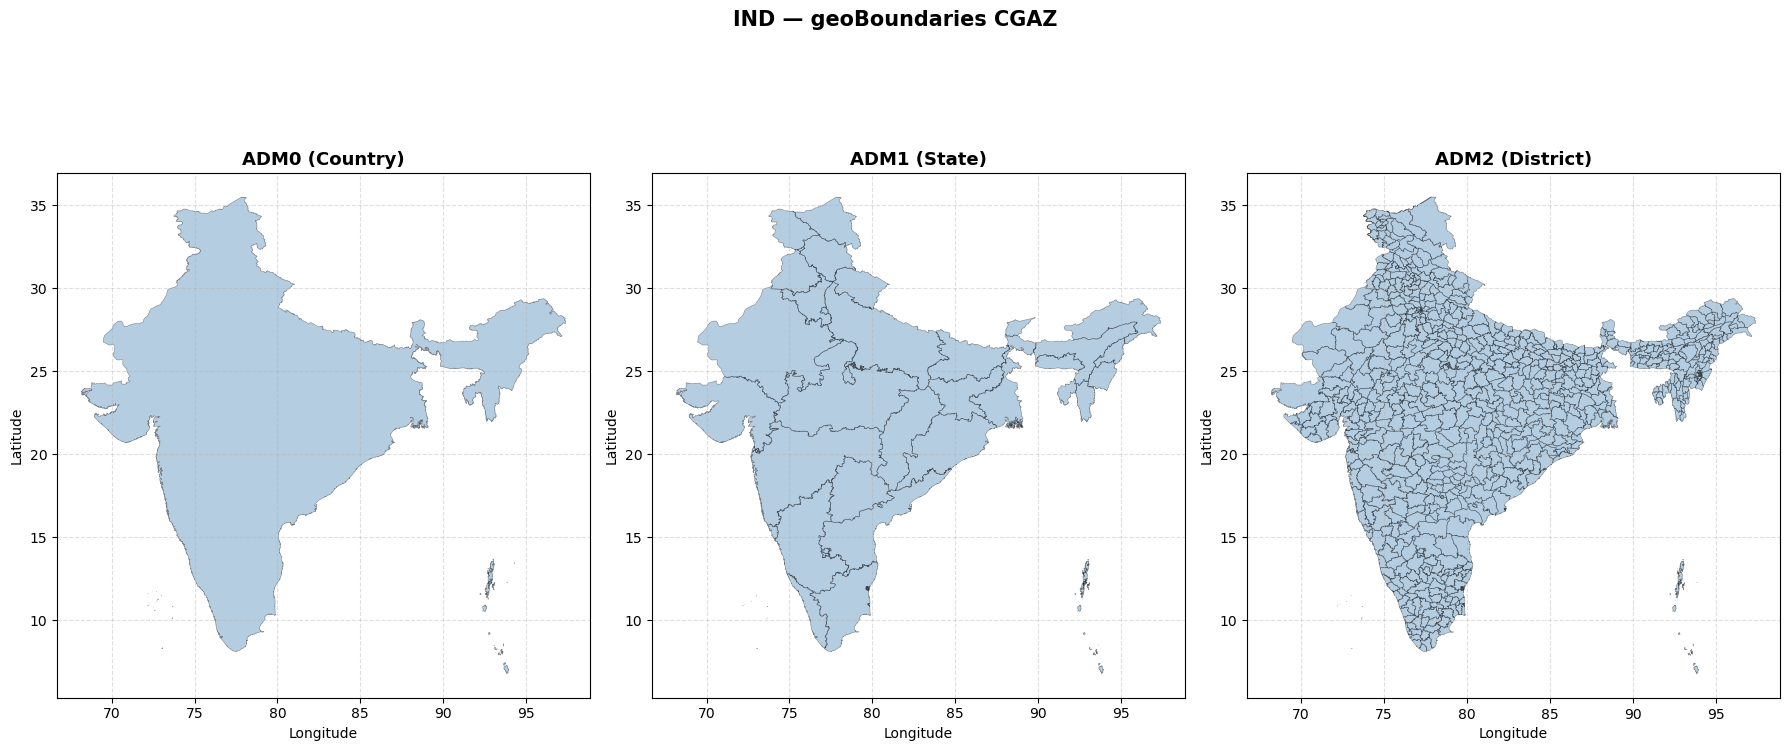

In [26]:
# ── Visualise all three levels together ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, (label, gdf) in zip(axes, [
    ('ADM0 (Country)', india_adm0),
    ('ADM1 (State)',   india_adm1),
    ('ADM2 (District)',india_adm2),
]):
    gdf.plot(ax=ax, edgecolor='black', linewidth=0.4,
             facecolor='steelblue', alpha=0.4)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(f'{COUNTRY} — geoBoundaries CGAZ', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

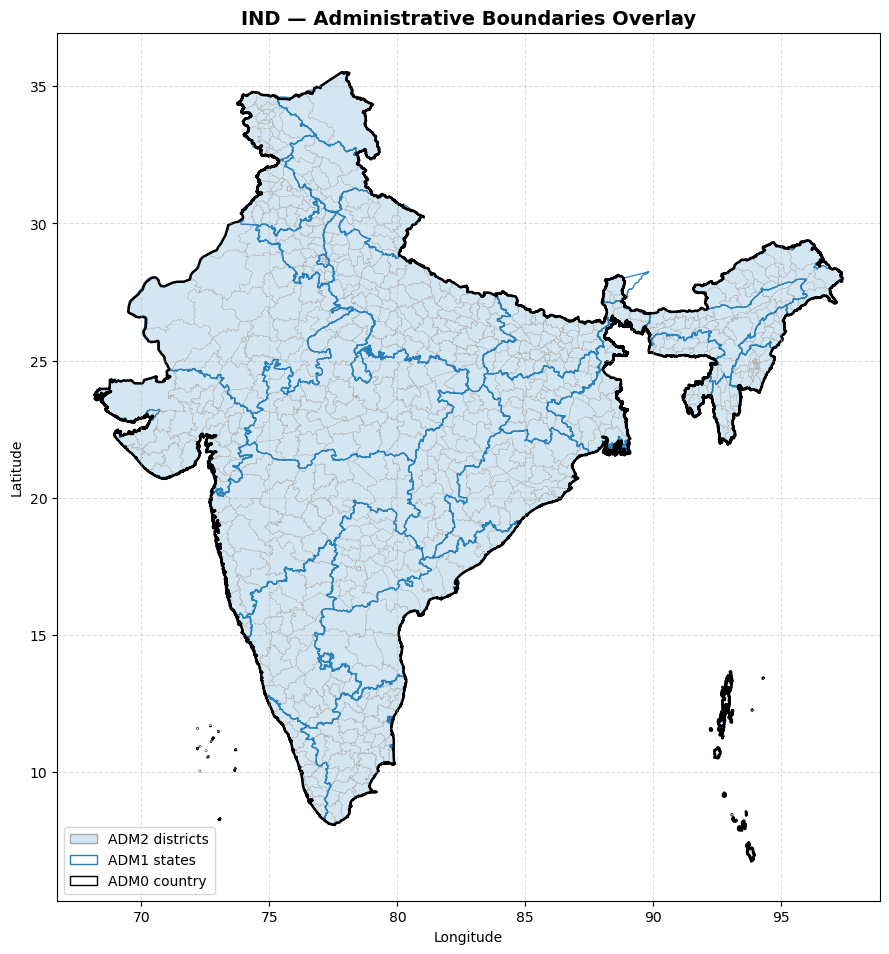

In [27]:
# ── Overlay all levels on one map ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 11))

india_adm2.plot(ax=ax, facecolor='#d4e6f1', edgecolor='#aaa', linewidth=0.3, label='ADM2')
india_adm1.plot(ax=ax, facecolor='none',    edgecolor='#2980b9', linewidth=0.9, label='ADM1')
india_adm0.plot(ax=ax, facecolor='none',    edgecolor='black',   linewidth=1.8, label='ADM0')

patches = [
    mpatches.Patch(facecolor='#d4e6f1', edgecolor='#aaa',    label='ADM2 districts'),
    mpatches.Patch(facecolor='none',    edgecolor='#2980b9', label='ADM1 states'),
    mpatches.Patch(facecolor='none',    edgecolor='black',   label='ADM0 country'),
]
ax.legend(handles=patches, loc='lower left', fontsize=10)
ax.set_title(f'{COUNTRY} — Administrative Boundaries Overlay', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [28]:
overview_img = Image.open(overview_png_path)
overview_img.show()

In [29]:
centroid_image = Image.open(centroid_detail_png_path)
centroid_image.show()

#### Data

In [30]:
testing_filepaths(step0_raw_data_2018_01_path)
testing_filepaths(step0_raw_data_2018_03_path)
testing_filepaths(step0_raw_data_2018_12_path)

testing_filepaths(step1_masked_data_2018_01_path)
testing_filepaths(step1_masked_data_2018_03_path)
testing_filepaths(step1_masked_data_2018_12_path)

testing_filepaths(step2_trimmed_data_2018_01_path)
testing_filepaths(step2_trimmed_data_2018_03_path)
testing_filepaths(step2_trimmed_data_2018_12_path)

testing_filepaths(step3_consolidated_data_2018_path)
testing_filepaths(step3_consolidated_data_2019_path)

testing_filepaths(step4_interpolated_data_2018_path)
testing_filepaths(step4_interpolated_data_2019_path)

testing_filepaths(step5_interpolated_boundary_fixed_data_2018_path)
testing_filepaths(step5_interpolated_boundary_fixed_data_2019_path)

testing_filepaths(step6_interpolated_final_data_2018_path)
testing_filepaths(step6_interpolated_final_data_2019_path)

testing_filepaths(step7_processed_data_ADM0_path)
testing_filepaths(step8_processed_data_ADM0_path)

testing_filepaths(step7_processed_data_ADM1_path)
testing_filepaths(step8_processed_data_ADM1_path)

Testing filepath for [era5-world_N37W68S6E98_d514a3a3c256_2018-01.grib]:
  - MIME type: application/grib;edition=1
  - Magic bytes: b'GRIB\x00v\x96\x01'
Testing filepath for [era5-world_N37W68S6E98_d514a3a3c256_2018-03.grib]:
  - MIME type: application/grib;edition=1
  - Magic bytes: b'GRIB\x00v\x96\x01'
Testing filepath for [era5-world_N37W68S6E98_d514a3a3c256_2018-12.grib]:


FileNotFoundError: [Errno 2] No such file or directory: '/Users/Daniel/Desktop/open-source-marginal-emissions.nosync/data/era5-world/raw/era5-world_N37W68S6E98_d514a3a3c256_2018-12.grib'

In [ ]:
# step1_masked_data_2018_01_pldf = pl.read_parquet(source=step1_masked_data_2018_01_path)
# step1_masked_data_2018_03_pldf = pl.read_parquet(source=step1_masked_data_2018_03_path)
# step1_masked_data_2018_12_pldf = pl.read_parquet(source=step1_masked_data_2018_12_path)
# step2_trimmed_data_2018_01_pldf = pl.read_parquet(source=step2_trimmed_data_2018_01_path)
# step2_trimmed_data_2018_03_pldf = pl.read_parquet(source=step2_trimmed_data_2018_03_path)
# step2_trimmed_data_2018_12_pldf = pl.read_parquet(source=step2_trimmed_data_2018_12_path)
# step3_consolidated_data_2018_pldf = pl.read_parquet(source=step3_consolidated_data_2018_path)
# step3_consolidated_data_2019_pldf = pl.read_parquet(source=step3_consolidated_data_2019_path)
# step4_interpolated_data_2018_pldf = pl.read_parquet(source=step4_interpolated_data_2018_path)
# step4_interpolated_data_2019_pldf = pl.read_parquet(source=step4_interpolated_data_2019_path)
# step5_interpolated_boundary_fixed_data_2018_pldf = pl.read_parquet(source=step5_interpolated_boundary_fixed_data_2018_path)
# step5_interpolated_boundary_fixed_data_2019_pldf = pl.read_parquet(source=step5_interpolated_boundary_fixed_data_2019_path)
# step6_interpolated_final_data_2018_pldf = pl.read_parquet(step6_interpolated_final_data_2018_path)
# step6_interpolated_final_data_2019_pldf = pl.read_parquet(source=step6_interpolated_final_data_2019_path)
# step7_processed_data_ADM0_pldf = pl.read_parquet(source=step7_processed_data_ADM0_path)
# step8_processed_data_ADM0_pldf = pl.read_parquet(source=step8_processed_data_ADM0_path)
# step7_processed_data_ADM1_pldf = pl.read_parquet(source=step7_processed_data_ADM1_path)
# step8_processed_data_ADM1_pldf = pl.read_parquet(source=step8_processed_data_ADM1_path)

In [18]:
plot_specs_2018 = [
    {
        "variables": ["ssrd", "t2m", "u100","tp", "tcc", ],
        "filters": [
            pl.col("latitude") == 35.25,
            pl.col("longitude") == 78.0,
        ],
        "start": "2018-01-15 18:00",
        "window_hours": 24,
        "title_prefix": "Grid cell (35.25, 78.0)",
    },
        {
        "variables": ["ssr", "ssrd", "t2m", "u100"],
        "filters": [
            pl.col("adm2_code") == "76128533B57183548666997",
        ],
        "start": "2018-01-15 18:00",
        "window_hours": 24,
                "avg_multiseries": True,
        "title_prefix": "ADM2 Leh(Ladakh)",

    }
]

plot_specs_2019 = [
    {
        "variables": ["ssrd", "t2m", "u100","tp", "tcc", ],
        "filters": [
            pl.col("latitude") == 35.25,
            pl.col("longitude") == 78.0,
        ],
        "start": "2019-01-15 18:00",
        "window_hours": 24,
        "title_prefix": "Grid cell (35.25, 78.0)",
    },
        {
        "variables": ["ssr", "ssrd", "t2m", "u100"],
        "filters": [
            pl.col("adm2_code") == "76128533B57183548666997",
        ],
        "start": "2019-01-15 18:00",
        "window_hours": 24,
                "avg_multiseries": True,
        "title_prefix": "ADM2 Leh(Ladakh)",

    }
]

eo_plot_specs_2018 = [
    {
        "variables": ["ssrd", "t2m", "u100","tp", "tcc", ],
        "filters": [
            pl.col("latitude") == 35.25,
            pl.col("longitude") == 78.0,
        ],
        "start": "2018-12-31 00:00",
        "window_hours": 24,
        "title_prefix": "Grid cell (35.25, 78.0)",
    },
        {
        "variables": ["ssr", "ssrd", "t2m", "u100"],
        "filters": [
            pl.col("adm2_code") == "76128533B57183548666997",
        ],
        "start": "2018-12-31 00:00",
        "window_hours": 24,
                "avg_multiseries": True,
        "title_prefix": "ADM2 Leh(Ladakh)",

    }
]

eo_plot_specs_2019 = [
    {
        "variables": ["ssrd", "t2m", "u100","tp", "tcc", ],
        "filters": [
            pl.col("latitude") == 35.25,
            pl.col("longitude") == 78.0,
        ],
        "start": "2019-12-31 00:00",
        "window_hours": 24,
        "title_prefix": "Grid cell (35.25, 78.0)",
    },
        {
        "variables": ["ssr", "ssrd", "t2m", "u100"],
        "filters": [
            pl.col("adm2_code") == "76128533B57183548666997",
        ],
        "start": "2019-12-31 00:00",
        "window_hours": 24,
                "avg_multiseries": True,
        "title_prefix": "ADM2 Leh(Ladakh)",

    }
]

##### Step 1 Data

In [31]:
# Describe
step1_masked_data_2018_01_pldf = pl.read_parquet(source=step1_masked_data_2018_01_path)
step1_masked_data_2018_03_pldf = pl.read_parquet(source=step1_masked_data_2018_03_path)
step1_masked_data_2018_12_pldf = pl.read_parquet(source=step1_masked_data_2018_12_path)

print('Step 1 Masked Data 2018-01 Description')
display(step1_masked_data_2018_01_pldf.describe())
print('Step 1 Masked Data 2018-03 Description')
display(step1_masked_data_2018_03_pldf.describe())
print('Step 1 Masked Data 2018-12 Description')
display(step1_masked_data_2018_12_pldf.describe())

Step 1 Masked Data 2018-01 Description


statistic,latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str
"""count""",3.358152e6,3.358152e6,"""3358152""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.358152e6,"""3358152""","""3358152""","""3358152""","""3358152""","""3358152""","""3358152"""
"""null_count""",0.0,0.0,"""0""",53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",22.886875,79.613519,"""2018-01-16 12:30:00""",-0.351464,-0.888849,-0.178635,-0.516106,289.690674,609923.3125,0.279998,0.663284,564936.75,0.066978,-16.497999,1.776128,1.627019,0.065957,0.061619,582850.125,608595.0,717708.25,748963.75,-314977.625,-333587.4375,1.120844e6,1.1010e6,0.162325,0.000009,814553.8125,839555.875,-1.0134e6,-1.0220e6,77395.328125,1.0,null,null,null,null,null,null
"""std""",5.504277,5.880584,null,2.772204,2.121214,1.632763,1.256959,10.166892,861944.375,0.31615,0.325827,822113.75,0.203259,19.83663,1.241123,0.715686,0.192645,0.167814,825875.6875,852993.6875,997127.375,1.0279e6,128049.90625,113481.773438,172052.5,174847.734375,0.285761,0.000085,1.1119e6,1.1408e6,105084.382812,96098.226562,109323.125,0.0,null,null,null,null,null,null
"""min""",8.25,68.25,"""2017-12-31 19:00:00""",-10.011185,-10.840759,-7.533813,-8.027176,229.620056,0.0,0.0,0.0,0.0,0.0,-89.317909,0.0,0.0,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-870358.0,-864090.5,323103.375,332315.6875,0.0,0.0,0.0,0.0,-1.273476e6,-1.265231e6,0.0,1.0,"""India""","""IND""","""Andhra Pradesh""","""1811400B11231190780494""","""Adilabad""","""76128533B10727492375508"""
"""25%""",19.5,75.5,"""2018-01-08 16:00:00""",-2.201477,-2.239334,-1.377945,-1.398041,285.546509,0.0,0.00238,0.416563,0.0,0.0,-29.786163,0.980957,1.153442,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-400384.375,-411577.0625,1.0471e6,1.0381e6,0.0,0.0,0.0,0.0,-1.072172e6,-1.076325e6,0.0,1.0,null,null,null,null,null,null
"""50%""",23.5,78.25,"""2018-01-16 13:00:00""",-0.395096,-0.855118,-0.268677,-0.556458,290.952026,0.0,0.149811,0.755631,0.0,0.0,-19.621788,1.920044,1.560791,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-277176.0,-288893.0,1127272.5,1.1160e6,0.0,0.0,0.0,0.0,-1.029763e6,-1.034184e6,0.0,1.0,null,null,null,null,null,null
"""75%""",26.75,82.5,"""2018-01-24 09:00:00""",1.364853,0.468353,0.941086,0.340149,296.254761,1.297024e6,0.504298,0.976124,1.13344e6,0.0,-4.634796,2.310913,2.165894,0.004578,0.012146,1.191552e6,1.279552e6,1.525888e6,1.630272e6,-232995.375,-249491.0,1.2204e6,1.2023e6,0.194061,0.0,1.729408e6,1.803136e6,-983334.0,-989749.0,159952.0,1.0,null,null,null,null,null,null
"""max""",35.25,97.25,"""2018-02-01 06:00:00""",11.976593,9.605347,8.431534,5.483978,309.279175,3.029888e6,1.0,1.0,3.05984e6,1.0,38.759247,6.252563,3.683105,1.0,1.0,3.058816e6,3.15776e6,3.475264e6,3.45952e6,103486.1875,-93737.1875,1.6290e6,1.576104e6,1.0,0.009217,4.01024e6,4.108288e6,-451954.0,-507424.0,408032.0,1.0,"""India""","""IND""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""","""NONE_DEFINED"""


Step 1 Masked Data 2018-03 Description


statistic,latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str
"""count""",3.358152e6,3.358152e6,"""3358152""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.358152e6,"""3358152""","""3358152""","""3358152""","""3358152""","""3358152""","""3358152"""
"""null_count""",0.0,0.0,"""0""",53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",22.886875,79.613519,"""2018-03-16 12:30:00""",0.505887,-0.333618,0.322759,-0.161102,297.637695,829446.9375,0.279998,0.663284,722734.1875,0.136995,13.828256,1.713849,1.5804,0.045455,0.120052,748057.0625,811981.1875,935403.875,1.0132e6,-343439.03125,-368020.09375,1.261911e6,1.2354e6,0.242144,0.000034,1073794.5,1.1374e6,-1.013309e6,-1.0470e6,105457.304688,1.0,null,null,null,null,null,null
"""std""",5.504277,5.880584,null,3.154688,2.696287,1.91698,1.586312,10.346111,1.088636e6,0.31615,0.325827,998566.1875,0.271542,16.186184,1.193714,0.706669,0.160582,0.218157,994359.5,1.0566e6,1.2182e6,1.2894e6,157640.03125,142857.234375,180002.875,185670.71875,0.320921,0.000241,1.3601e6,1.4266e6,127743.59375,96374.09375,139469.9375,0.0,null,null,null,null,null,null
"""min""",8.25,68.25,"""2018-02-28 19:00:00""",-11.633621,-11.934555,-9.442978,-8.083618,234.584061,0.0,0.0,0.0,0.0,0.0,-117.629463,0.0,0.0,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-1.093134e6,-1.09246e6,352711.625,336971.0,0.0,0.0,0.0,0.0,-1.409894e6,-1.414566e6,0.0,1.0,"""India""","""IND""","""Andhra Pradesh""","""1811400B11231190780494""","""Adilabad""","""76128533B10727492375508"""
"""25%""",19.5,75.5,"""2018-03-08 16:00:00""",-1.506302,-2.123947,-0.970047,-1.300034,294.84906,0.0,0.00238,0.416563,0.0,0.0,4.775963,0.969238,1.089111,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-438697.0,-456178.0,1.2000e6,1.1900e6,0.0,0.0,0.0,0.0,-1.085565e6,-1.098862e6,0.0,1.0,null,null,null,null,null,null
"""50%""",23.5,78.25,"""2018-03-16 13:00:00""",0.417374,-0.398102,0.255768,-0.239258,298.846436,12480.0,0.149811,0.755631,7680.0,0.0,18.334229,1.837646,1.508789,0.0,0.001678,27904.0,29376.0,36992.0,40640.0,-299610.0,-316953.0,1.28216e6,1.265323e6,0.062592,0.0,72192.0,74240.0,-1.036711e6,-1.051778e6,4552.0,1.0,null,null,null,null,null,null
"""75%""",26.75,82.5,"""2018-03-24 09:00:00""",2.642899,1.370575,1.662552,0.921417,304.041504,1.788032e6,0.504298,0.976124,1.472384e6,0.10437,26.160278,2.280151,2.10376,0.0,0.150116,1.55168e6,1.721664e6,1.978432e6,2.202432e6,-237293.75,-262579.0,1.3657e6,1.3391e6,0.40686,0.0,2.270464e6,2.437248e6,-978025.0,-1.01535e6,219016.0,1.0,null,null,null,null,null,null
"""max""",35.25,97.25,"""2018-04-01 06:00:00""",12.165634,11.198059,9.615158,8.422836,317.553223,3.49632e6,1.0,1.0,3.457344e6,1.0,43.424789,6.187012,3.606445,1.0,1.0,3.404672e6,3.478208e6,3.985664e6,3.975488e6,72868.0,-119274.5625,1.7099e6,1651395.5,1.0,0.017243,4.456192e6,4.452736e6,-317591.0,-539888.0,488184.0,1.0,"""India""","""IND""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""","""NONE_DEFINED"""


Step 1 Masked Data 2018-12 Description


statistic,latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str
"""count""",3.358152e6,3.358152e6,"""3358152""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.358152e6,"""3358152""","""3358152""","""3358152""","""3358152""","""3358152""","""3358152"""
"""null_count""",0.0,0.0,"""0""",53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",22.886875,79.613519,"""2018-12-16 12:30:00""",-0.989594,-1.170574,-0.521021,-0.70364,289.785767,552462.8125,0.279998,0.663284,469498.65625,0.158924,-10.965674,1.821233,1.615951,0.087976,0.113414,509980.40625,562243.125,628383.25,691500.5625,-289858.15625,-318204.65625,1.147133e6,1.1176e6,0.276447,0.000026,739775.375,793102.8125,-980025.1875,-1.0074e6,67807.03125,1.0,null,null,null,null,null,null
"""std""",5.504277,5.880584,null,2.644537,2.248327,1.55704,1.337637,10.163112,792242.375,0.31615,0.325827,714301.125,0.317659,23.943171,1.276984,0.746989,0.210934,0.234818,740235.0625,797763.5625,895575.125,960732.375,125979.78125,106928.148438,198858.734375,191142.421875,0.361484,0.000223,1.024962e6,1.0906e6,115106.53125,91718.96875,97800.703125,0.0,null,null,null,null,null,null
"""min""",8.25,68.25,"""2018-11-30 19:00:00""",-16.060211,-14.622116,-10.977997,-10.636261,226.659988,0.0,0.0,0.0,0.0,0.0,-108.626312,0.0,0.0,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-859080.875,-834011.75,299944.0,299413.0625,0.0,0.0,0.0,0.0,-1.244348e6,-1.238414e6,0.0,1.0,"""India""","""IND""","""Andhra Pradesh""","""1811400B11231190780494""","""Adilabad""","""76128533B10727492375508"""
"""25%""",19.5,75.5,"""2018-12-08 16:00:00""",-2.841141,-2.554626,-1.638458,-1.55835,286.130646,0.0,0.00238,0.416563,0.0,0.0,-28.356659,0.979858,1.058594,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-358793.0,-381770.0,1.0446e6,1.0375e6,0.0,0.0,0.0,0.0,-1.0491e6,-1.060536e6,0.0,1.0,null,null,null,null,null,null
"""50%""",23.5,78.25,"""2018-12-16 13:00:00""",-0.985428,-1.042068,-0.613953,-0.706131,291.549774,0.0,0.149811,0.755631,0.0,0.0,-10.68718,1.971558,1.531494,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-265996.9375,-283170.1875,1146007.5,1129406.5,0.051575,0.0,0.0,0.0,-1.007858e6,-1.022177e6,0.0,1.0,null,null,null,null,null,null
"""75%""",26.75,82.5,"""2018-12-24 09:00:00""",0.710403,0.298325,0.552002,0.194153,296.161011,1.1536e6,0.504298,0.976124,872448.0,0.06488,6.877525,2.337402,2.205688,0.044556,0.095459,1.002752e6,1.172736e6,1.287104e6,1.485312e6,-210317.375,-241214.0,1.2791e6,1.2377e6,0.518494,0.0,1.53344e6,1.68192e6,-954925.0,-977552.0,134952.0,1.0,null,null,null,null,null,null
"""max""",35.25,97.25,"""2019-01-01 06:00:00""",12.276108,9.88089,8.913589,7.281311,308.931915,2.835712e6,1.0,1.0,2.816768e6,1.0,40.406448,6.343872,3.733643,1.0,1.0,2.908736e6,3.018048e6,3.254848e6,3.254784e6,126659.75,-67023.4375,1.6477e6,1.5820e6,1.0,0.021027,3.852416e6,3.948288e6,-301068.0,-500172.0,381280.0,1.0,"""India""","""IND""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""","""NONE_DEFINED"""


In [ ]:
print('Step 1 Masked Data 2018-01 — First 8 rows:')
display(step1_masked_data_2018_01_pldf.head(8))
print('Step 1 Masked Data 2018-01 — Last 8 rows:')
display(step1_masked_data_2018_01_pldf.tail(8))

Step 1 Masked Data 2018-01 — First 8 rows:


latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str,str,str
35.25,77.5,2017-12-31 19:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 20:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 21:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 22:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 23:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-01 00:00:00,1.377716,-0.158432,0.284775,-0.811127,240.809692,0.0,0.0,0.005654,0.0,0.0,-20.509537,0.0,0.284668,0.581116,0.473907,3.6000e-12,0.0,0.0,0.0,-126984.0,-145374.5,394172.25,374672.0,0.64978,0.000001,0.0,0.0,-538943.0,-534469.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-01 01:00:00,1.382904,-0.270203,0.245407,-0.813004,241.025314,0.0,0.0,0.005654,0.0,0.0,-20.390999,0.0,0.284668,0.758057,0.664978,3.6000e-12,0.0,0.0,0.0,-129250.0625,-141619.4375,388486.3125,373667.75,0.837372,0.000002,0.0,0.0,-535883.0,-531899.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-01 02:00:00,1.268295,0.019287,0.249374,-0.791077,240.921371,0.0,0.0,0.005654,0.0,0.0,-20.531189,0.0,0.284668,0.468719,0.502258,3.6000e-12,0.0,0.0,0.0,-132745.125,-138690.625,381255.875,372574.6875,0.653595,0.000001,0.0,0.0,-533275.0,-530085.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""


Step 1 Masked Data 2018-01 — Last 8 rows:


latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str,str,str
8.25,77.75,2018-01-31 23:00:00,-4.359802,-7.455994,-3.253738,-5.659195,297.857361,0.0,0.031433,0.958844,0.0,0.505951,24.949844,1.013184,0.768677,0.0,0.002869,3.6000e-12,0.0,0.0,0.0,-243240.0,-277451.5,1363437.5,1.3447e6,0.507385,0.0,0.0,0.0,-890226.0,-982130.0,0.0,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 00:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 01:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 02:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 03:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 04:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 05:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 06:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""


In [ ]:
print('Step 1 Masked Data 2018-03 — First 8 rows:')
display(step1_masked_data_2018_03_pldf.head(8))
print('Step 1 Masked Data 2018-03 — Last 8 rows:')
display(step1_masked_data_2018_03_pldf.tail(8))

Step 1 Masked Data 2018-03 — First 8 rows:


latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str,str,str
35.25,77.5,2018-02-28 19:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-02-28 20:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-02-28 21:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-02-28 22:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-02-28 23:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-03-01 00:00:00,1.270325,1.865829,0.297806,0.010498,251.97168,0.0,0.0,0.005654,0.0,0.008972,-12.020073,0.0,0.284668,0.997223,0.499878,3.6000e-12,0.0,0.0,0.0,-36813.8125,-257582.9375,697415.625,473943.0625,1.0,0.000104,0.0,0.0,-644510.0,-647064.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-03-01 01:00:00,1.005737,1.778397,0.252975,-0.068619,251.62442,0.0,0.0,0.005654,0.0,0.0,-11.947891,0.0,0.284668,0.993774,0.994995,3.6000e-12,0.0,0.0,0.0,-66497.5625,-274994.625,662521.5625,472942.375,1.0,0.000091,0.0,0.0,-633183.0,-655041.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-03-01 02:00:00,0.944382,1.793793,0.258514,-0.080811,252.231094,51072.0,0.0,0.005654,14208.0,0.065552,-11.815445,0.0,0.284668,0.993103,1.0,11968.0,16000.0,69248.0,95040.0,-57701.125,-264342.5625,671025.375,471949.0625,1.0,0.000092,68480.0,72704.0,-627804.0,-648954.0,8776.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""


Step 1 Masked Data 2018-03 — Last 8 rows:


latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str,str,str
8.25,77.75,2018-03-31 23:00:00,3.966568,0.761215,3.041595,0.917892,300.087402,0.0,0.031433,0.958844,0.0,0.0,23.485168,1.013184,0.752563,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-255085.6875,-266842.4375,1.3915e6,1.3987e6,0.0,0.0,0.0,0.0,-1.050148e6,-1.052402e6,0.0,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 00:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 01:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 02:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 03:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 04:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 05:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 06:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""


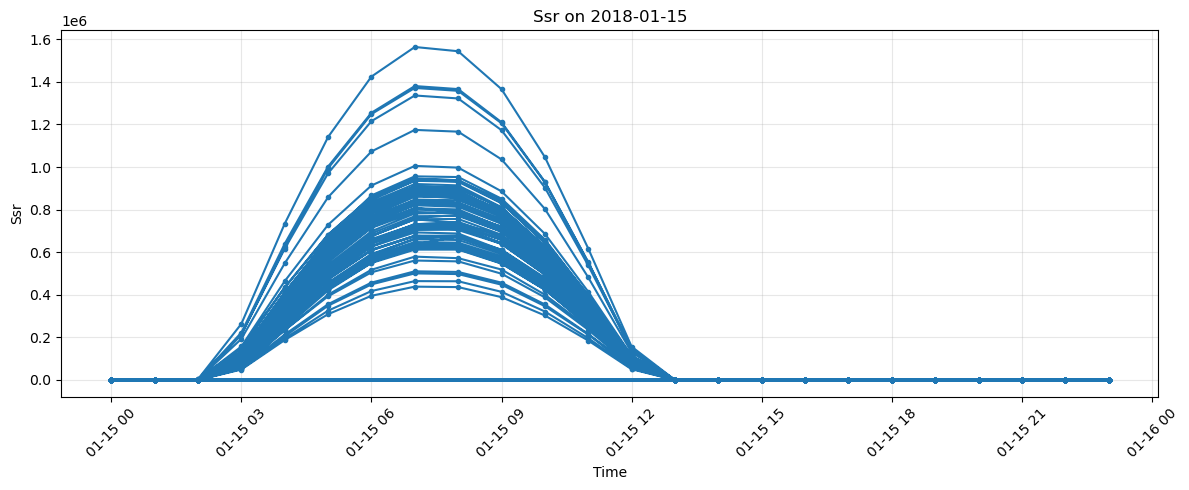

latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str,str,str
35.25,77.5,2018-01-15 00:00:00,1.913864,1.43219,0.61496,-0.352936,241.832947,0.0,0.0,0.005654,0.0,0.0,-36.866035,0.0,0.284668,0.972046,0.0,3.6000e-12,0.0,0.0,0.0,-157811.25,-225859.5625,421205.375,372718.75,0.972046,0.000004,0.0,0.0,-580215.0,-578913.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-15 01:00:00,1.70842,1.734161,0.591339,-0.286331,241.79158,0.0,0.0,0.005654,0.0,0.0,-35.825348,0.0,0.284668,0.974152,0.000702,3.6000e-12,0.0,0.0,0.0,-162705.125,-214641.9375,408939.25,373661.9375,0.974152,0.000003,0.0,0.0,-575022.0,-573343.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-15 02:00:00,1.671066,1.995972,0.626221,-0.147141,241.885132,0.0,0.0,0.005654,0.0,0.0,-34.497498,0.0,0.284668,0.854095,0.000702,3.6000e-12,0.0,0.0,0.0,-156233.4375,-204176.375,412409.9375,375943.5625,0.854095,0.000002,0.0,0.0,-572226.0,-568834.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-15 03:00:00,1.683121,2.038452,0.616745,-0.111084,241.973267,195968.0,0.0,0.005654,162112.0,0.0,-33.316917,0.0,0.284668,0.864075,0.001373,56960.0,62016.0,263360.0,276608.0,-163973.3125,-199126.125,410291.0,378653.9375,0.864777,0.000002,157184.0,160768.0,-572073.0,-567374.0,26768.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-15 04:00:00,1.781586,2.215454,0.581116,-0.021484,241.039505,826816.0,0.0,0.005654,777152.0,0.0,-32.895897,0.0,0.284668,0.837189,0.003448,213312.0,234432.0,1.008704e6,1.01952e6,-208546.5,-223967.5,403773.125,383083.5,0.837189,0.000001,429952.0,448896.0,-589513.0,-583209.0,104960.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
32.5,79.0,2018-01-15 19:00:00,0.158463,4.319534,-0.935532,0.681076,252.223267,0.0,0.0,0.756005,0.0,0.0,-45.892113,0.0,0.507568,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-180136.0,-219901.0,432245.8125,427934.5,0.0,0.0,0.0,0.0,-606640.0,-622395.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
32.5,79.0,2018-01-15 20:00:00,0.106522,4.36763,-0.906509,0.694977,251.528473,0.0,0.0,0.756005,0.0,0.0,-45.438629,0.0,0.507568,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-174010.0,-211746.0,434618.8125,426574.0625,0.0,0.0,0.0,0.0,-604125.0,-617411.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
32.5,79.0,2018-01-15 21:00:00,0.07579,4.460159,-0.926666,0.716568,252.132889,0.0,0.0,0.756005,0.0,0.0,-45.308502,0.0,0.507568,0.002502,0.0,3.6000e-12,0.0,0.0,0.0,-168112.0,-207650.0,438565.4375,424636.8125,0.002502,0.0,0.0,0.0,-604017.0,-614367.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""


In [32]:
plot_day_polars_direct(step1_masked_data_2018_01_pldf.filter(pl.col("adm2_code")=="76128533B57183548666997"), date='2018-01-15', column='ssr')

##### Step 2 Data

In [51]:
step2_trimmed_data_2018_01_pldf = pl.read_parquet(source=step2_trimmed_data_2018_01_path)
step2_trimmed_data_2018_03_pldf = pl.read_parquet(source=step2_trimmed_data_2018_03_path)
step2_trimmed_data_2018_12_pldf = pl.read_parquet(source=step2_trimmed_data_2018_12_path)

In [52]:
# Describe
print('Step 2 Trimmed Data 2018-01 Description')
display(step2_trimmed_data_2018_01_pldf.describe())
print('Step 2 Trimmed Data 2018-03 Description')
display(step2_trimmed_data_2018_03_pldf.describe())
print('Step 2 Trimmed Data 2018-12 Description')
display(step2_trimmed_data_2018_12_pldf.describe())

Step 2 Trimmed Data 2018-01 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""3304848""","""3304848""","""3304848""","""3304848""","""3304848""","""3304848""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,"""3304848""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,609923.3125,0.279998,0.663284,564936.75,1.0,0.066978,-16.497999,1.776128,1.627019,22.886875,0.065957,79.613518,0.061619,582850.125,608595.0,717708.25,748963.75,-314977.625,-333587.4375,1.120844e6,1.1010e6,289.690674,0.162325,"""2018-01-16 11:29:59.999999""",0.000009,814553.8125,839555.875,-1.0134e6,-1.0220e6,-0.178635,-0.351464,77395.328125,-0.516106,-0.888849
"""std""",null,null,null,null,null,null,861944.375,0.31615,0.325827,822113.75,0.0,0.203259,19.83663,1.241123,0.715686,5.504277,0.192645,5.880584,0.167814,825875.6875,852993.6875,997127.375,1.0279e6,128049.90625,113481.773438,172052.5,174847.734375,10.166892,0.285761,null,0.000085,1.1119e6,1.1408e6,105084.382812,96098.226562,1.632763,2.772204,109323.125,1.256959,2.121214
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-89.317909,0.0,0.0,8.25,0.0,68.25,0.0,3.6000e-12,0.0,0.0,0.0,-870358.0,-864090.5,323103.375,332315.6875,229.620056,0.0,"""2018-01-01 00:00:00""",0.0,0.0,0.0,-1.273476e6,-1.265231e6,-7.533813,-10.011185,0.0,-8.027176,-10.840759
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,-29.786163,0.980957,1.153442,19.5,0.0,75.5,0.0,3.6000e-12,0.0,0.0,0.0,-400384.375,-411577.0625,1.0471e6,1.0381e6,285.546509,0.0,"""2018-01-08 18:00:00""",0.0,0.0,0.0,-1.072172e6,-1.076325e6,-1.377945,-2.201477,0.0,-1.398041,-2.239334
"""50%""",null,null,null,null,null,null,0.0,0.149811,0.755631,0.0,1.0,0.0,-19.621788,1.920044,1.560791,23.5,0.0,78.25,0.0,3.6000e-12,0.0,0.0,0.0,-277176.0,-288893.0,1127272.5,1.1160e6,290.952026,0.0,"""2018-01-16 12:00:00""",0.0,0.0,0.0,-1.029763e6,-1.034184e6,-0.268677,-0.395096,0.0,-0.556458,-0.855118
"""75%""",null,null,null,null,null,null,1.297024e6,0.504298,0.976124,1.13344e6,1.0,0.0,-4.634796,2.310913,2.165894,26.75,0.004578,82.5,0.012146,1.191552e6,1.279552e6,1.525888e6,1.630272e6,-232995.375,-249491.0,1.2204e6,1.2023e6,296.254761,0.194061,"""2018-01-24 05:00:00""",0.0,1.729408e6,1.803136e6,-983334.0,-989749.0,0.941086,1.364853,159952.0,0.340149,0.468353
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",3.029888e6,1.0,1.0,3.05984e6,1.0,1.0,38.759247,6.252563,3.683105,35.25,1.0,97.25,1.0,3.058816e6,3.15776e6,3.475264e6,3.45952e6,103486.1875,-93737.1875,1.6290e6,1.576104e6,309.279175,1.0,"""2018-01-31 23:00:00""",0.009217,4.01024e6,4.108288e6,-451954.0,-507424.0,8.431534,11.976593,408032.0,5.483978,9.605347


Step 2 Trimmed Data 2018-03 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""3304848""","""3304848""","""3304848""","""3304848""","""3304848""","""3304848""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,"""3304848""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,829446.9375,0.279998,0.663284,722734.1875,1.0,0.136995,13.828256,1.713849,1.5804,22.886875,0.045455,79.613518,0.120052,748057.0625,811981.1875,935403.875,1.0132e6,-343439.03125,-368020.09375,1.261911e6,1.2354e6,297.637695,0.242144,"""2018-03-16 11:30:00""",0.000034,1073794.5,1.1374e6,-1.013309e6,-1.0470e6,0.322759,0.505887,105457.304688,-0.161102,-0.333618
"""std""",null,null,null,null,null,null,1.088636e6,0.31615,0.325827,998566.1875,0.0,0.271542,16.186184,1.193714,0.706669,5.504277,0.160582,5.880584,0.218157,994359.5,1.0566e6,1.2182e6,1.2894e6,157640.03125,142857.234375,180002.875,185670.71875,10.346111,0.320921,null,0.000241,1.3601e6,1.4266e6,127743.59375,96374.09375,1.91698,3.154688,139469.9375,1.586312,2.696287
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-117.629463,0.0,0.0,8.25,0.0,68.25,0.0,3.6000e-12,0.0,0.0,0.0,-1.093134e6,-1.09246e6,352711.625,336971.0,234.584061,0.0,"""2018-03-01 00:00:00""",0.0,0.0,0.0,-1.409894e6,-1.414566e6,-9.442978,-11.633621,0.0,-8.083618,-11.934555
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,4.775963,0.969238,1.089111,19.5,0.0,75.5,0.0,3.6000e-12,0.0,0.0,0.0,-438697.0,-456178.0,1.2000e6,1.1900e6,294.84906,0.0,"""2018-03-08 18:00:00""",0.0,0.0,0.0,-1.085565e6,-1.098862e6,-0.970047,-1.506302,0.0,-1.300034,-2.123947
"""50%""",null,null,null,null,null,null,12480.0,0.149811,0.755631,7680.0,1.0,0.0,18.334229,1.837646,1.508789,23.5,0.0,78.25,0.001678,27904.0,29376.0,36992.0,40640.0,-299610.0,-316953.0,1.28216e6,1.265323e6,298.846436,0.062592,"""2018-03-16 12:00:00""",0.0,72192.0,74240.0,-1.036711e6,-1.051778e6,0.255768,0.417374,4552.0,-0.239258,-0.398102
"""75%""",null,null,null,null,null,null,1.788032e6,0.504298,0.976124,1.472384e6,1.0,0.10437,26.160278,2.280151,2.10376,26.75,0.0,82.5,0.150116,1.55168e6,1.721664e6,1.978432e6,2.202432e6,-237293.75,-262579.0,1.3657e6,1.3391e6,304.041504,0.40686,"""2018-03-24 05:00:00""",0.0,2.270464e6,2.437248e6,-978025.0,-1.01535e6,1.662552,2.642899,219016.0,0.921417,1.370575
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",3.49632e6,1.0,1.0,3.457344e6,1.0,1.0,43.424789,6.187012,3.606445,35.25,1.0,97.25,1.0,3.404672e6,3.478208e6,3.985664e6,3.975488e6,72868.0,-119274.5625,1.7099e6,1651395.5,317.553223,1.0,"""2018-03-31 23:00:00""",0.017243,4.456192e6,4.452736e6,-317591.0,-539888.0,9.615158,12.165634,488184.0,8.422836,11.198059


Step 2 Trimmed Data 2018-12 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""3304848""","""3304848""","""3304848""","""3304848""","""3304848""","""3304848""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,"""3304848""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,552462.8125,0.279998,0.663284,469498.65625,1.0,0.158924,-10.965674,1.821233,1.615951,22.886875,0.087976,79.613518,0.113414,509980.40625,562243.125,628383.25,691500.5625,-289858.15625,-318204.65625,1.147133e6,1.1176e6,289.785767,0.276447,"""2018-12-16 11:29:59.999999""",0.000026,739775.375,793102.8125,-980025.1875,-1.0074e6,-0.521021,-0.989594,67807.03125,-0.70364,-1.170574
"""std""",null,null,null,null,null,null,792242.375,0.31615,0.325827,714301.125,0.0,0.317659,23.943171,1.276984,0.746989,5.504277,0.210934,5.880584,0.234818,740235.0625,797763.5625,895575.125,960732.375,125979.78125,106928.148438,198858.734375,191142.421875,10.163112,0.361484,null,0.000223,1.024962e6,1.0906e6,115106.53125,91718.96875,1.55704,2.644537,97800.703125,1.337637,2.248327
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-108.626312,0.0,0.0,8.25,0.0,68.25,0.0,3.6000e-12,0.0,0.0,0.0,-859080.875,-834011.75,299944.0,299413.0625,226.659988,0.0,"""2018-12-01 00:00:00""",0.0,0.0,0.0,-1.244348e6,-1.238414e6,-10.977997,-16.060211,0.0,-10.636261,-14.622116
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,-28.356659,0.979858,1.058594,19.5,0.0,75.5,0.0,3.6000e-12,0.0,0.0,0.0,-358793.0,-381770.0,1.0446e6,1.0375e6,286.130646,0.0,"""2018-12-08 18:00:00""",0.0,0.0,0.0,-1.0491e6,-1.060536e6,-1.638458,-2.841141,0.0,-1.55835,-2.554626
"""50%""",null,null,null,null,null,null,0.0,0.149811,0.755631,0.0,1.0,0.0,-10.68718,1.971558,1.531494,23.5,0.0,78.25,0.0,3.6000e-12,0.0,0.0,0.0,-265996.9375,-283170.1875,1146007.5,1129406.5,291.549774,0.051575,"""2018-12-16 12:00:00""",0.0,0.0,0.0,-1.007858e6,-1.022177e6,-0.613953,-0.985428,0.0,-0.706131,-1.042068
"""75%""",null,null,null,null,null,null,1.1536e6,0.504298,0.976124,872448.0,1.0,0.06488,6.877525,2.337402,2.205688,26.75,0.044556,82.5,0.095459,1.002752e6,1.172736e6,1.287104e6,1.485312e6,-210317.375,-241214.0,1.2791e6,1.2377e6,296.161011,0.518494,"""2018-12-24 05:00:00""",0.0,1.53344e6,1.68192e6,-954925.0,-977552.0,0.552002,0.710403,134952.0,0.194153,0.298325
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",2.835712e6,1.0,1.0,2.816768e6,1.0,1.0,40.406448,6.343872,3.733643,35.25,1.0,97.25,1.0,2.908736e6,3.018048e6,3.254848e6,3.254784e6,126659.75,-67023.4375,1.6477e6,1.5820e6,308.931915,1.0,"""2018-12-31 23:00:00""",0.021027,3.852416e6,3.948288e6,-301068.0,-500172.0,8.913589,12.276108,381280.0,7.281311,9.88089


In [ ]:
print('Step 2 Trimmed Data 2018-01 — First 8 rows:')
display(step2_trimmed_data_2018_01_pldf.head(8))
print('Step 2 Trimmed Data 2018-01 — Last 8 rows:')
display(step2_trimmed_data_2018_01_pldf.tail(8))

Step 2 Trimmed Data 2018-01 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.509537,0.0,0.284668,35.25,0.581116,77.5,0.473907,3.6000e-12,0.0,0.0,0.0,-126984.0,-145374.5,394172.25,374672.0,240.809692,0.64978,2018-01-01 00:00:00,0.000001,0.0,0.0,-538943.0,-534469.0,0.284775,1.377716,0.0,-0.811127,-0.158432
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.390999,0.0,0.284668,35.25,0.758057,77.5,0.664978,3.6000e-12,0.0,0.0,0.0,-129250.0625,-141619.4375,388486.3125,373667.75,241.025314,0.837372,2018-01-01 01:00:00,0.000002,0.0,0.0,-535883.0,-531899.0,0.245407,1.382904,0.0,-0.813004,-0.270203
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.531189,0.0,0.284668,35.25,0.468719,77.5,0.502258,3.6000e-12,0.0,0.0,0.0,-132745.125,-138690.625,381255.875,372574.6875,240.921371,0.653595,2018-01-01 02:00:00,0.000001,0.0,0.0,-533275.0,-530085.0,0.249374,1.268295,0.0,-0.791077,0.019287
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",181184.0,0.0,0.005654,177152.0,1.0,0.0,-21.180832,0.0,0.284668,35.25,0.580414,77.5,0.241852,47872.0,46144.0,258752.0,261184.0,-138297.0,-135713.0,379923.9375,371232.875,239.965469,0.597504,2018-01-01 03:00:00,9.5367e-7,146944.0,144640.0,-535470.0,-528148.0,0.247238,1.172256,25776.0,-0.786148,0.400345
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",783104.0,0.0,0.005654,716288.0,1.0,0.0,-21.873825,0.0,0.284668,35.25,0.609406,77.5,0.168884,170176.0,176256.0,952384.0,977856.0,-162683.0,-159374.0,386818.3125,370614.0625,237.582184,0.628021,2018-01-01 04:00:00,9.5367e-7,388864.0,392832.0,-553803.0,-540888.0,0.280487,1.242538,98704.0,-0.803772,0.582336
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.376256e6,0.0,0.005654,1.327552e6,1.0,0.0,-22.199249,0.0,0.284668,35.25,0.643738,77.5,0.202515,284288.0,289984.0,1.609984e6,1.628352e6,-192507.0,-194113.0,392493.5,371087.6875,240.023376,0.658051,2018-01-01 05:00:00,9.5367e-7,582784.0,582528.0,-572742.0,-560237.0,0.331802,1.392273,179832.0,-0.726242,0.680954
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.80192e6,0.0,0.005654,1.77952e6,1.0,0.0,-22.378044,0.0,0.284668,35.25,0.738007,77.5,0.199219,365568.0,370432.0,2.081408e6,2.089472e6,-228657.0,-227705.0,383090.75,371890.375,239.979141,0.748688,2018-01-01 06:00:00,9.5367e-7,711168.0,712832.0,-585433.0,-578824.0,0.376938,1.601379,237248.0,-0.59053,0.860504
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",2.004928e6,0.0,0.005654,1.983744e6,1.0,0.0,-20.380753,0.0,0.284668,35.25,0.731049,77.5,0.175751,404800.0,409280.0,2.30848e6,2.311616e6,-247917.9375,-247993.0,381401.6875,375739.5,240.514847,0.731049,2018-01-01 07:00:00,0.000003,776192.0,779776.0,-595411.0,-592267.0,0.407196,1.574203,267704.0,-0.530182,0.839294


Step 2 Trimmed Data 2018-01 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.952087,26.455223,1.013184,0.769043,8.25,0.0,77.75,0.005768,3.6000e-12,0.0,0.0,0.0,-225680.125,-236022.0,1.405376e6,1402256.5,299.746826,0.952087,2018-01-31 16:00:00,0.0,0.0,0.0,-916909.0,-985109.0,-3.996643,-5.261063,0.0,-4.559784,-6.034821
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.881561,26.458466,1.013184,0.768921,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-220780.0,-233535.0,1403821.5,1400808.5,299.206573,0.881561,2018-01-31 17:00:00,0.0,0.0,0.0,-950770.0,-982509.0,-3.967194,-5.296204,0.0,-4.862717,-6.479614
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.839111,25.56282,1.013184,0.768921,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-214624.0,-235053.0,1405818.5,1.3970e6,299.371521,0.839111,2018-01-31 18:00:00,0.0,0.0,0.0,-927215.0,-980962.0,-3.596283,-4.858612,0.0,-5.401962,-7.245346
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.95929,24.646439,1.013184,0.768799,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-220750.0,-243887.0,1.4028e6,1.385821e6,299.245239,0.95929,2018-01-31 19:00:00,0.0,0.0,0.0,-806730.0,-982491.0,-2.888184,-3.907913,0.0,-5.571381,-7.537567
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.90863,24.924934,1.013184,0.768799,8.25,0.0,77.75,0.002869,3.6000e-12,0.0,0.0,0.0,-234465.375,-255580.0,1385615.5,1.3768e6,298.742859,0.910065,2018-01-31 20:00:00,0.0,0.0,0.0,-870954.0,-982798.0,-2.890503,-3.82637,0.0,-5.492416,-7.450134
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.736328,23.94458,1.013184,0.768799,8.25,0.0,77.75,0.014191,3.6000e-12,0.0,0.0,0.0,-237314.5625,-262400.125,1377574.5,1365373.5,298.438293,0.744751,2018-01-31 21:00:00,0.0,0.0,0.0,-865185.0,-980812.0,-3.129944,-4.188705,0.0,-5.552292,-7.473129
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.826233,24.150993,1.013184,0.768677,8.25,0.0,77.75,0.013977,3.6000e-12,0.0,0.0,0.0,-233093.6875,-270168.6875,1.3777e6,1.354307e6,298.12326,0.826233,2018-01-31 22:00:00,0.0,0.0,0.0,-878244.0,-981324.0,-3.362762,-4.49469,0.0,-5.355682,-7.049881
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.505951,24.949844,1.013184,0.768677,8.25,0.0,77.75,0.002869,3.6000e-12,0.0,0.0,0.0,-243240.0,-277451.5,1363437.5,1.3447e6,297.857361,0.507385,2018-01-31 23:00:00,0.0,0.0,0.0,-890226.0,-982130.0,-3.253738,-4.359802,0.0,-5.659195,-7.455994


: 

In [ ]:
print('Step 2 Trimmed Data 2018-03 — First 8 rows:')
display(step2_trimmed_data_2018_03_pldf.head(8))
print('Step 2 Trimmed Data 2018-03 — Last 8 rows:')
display(step2_trimmed_data_2018_03_pldf.tail(8))

Step 2 Trimmed Data 2018-03 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.008972,-12.020073,0.0,0.284668,35.25,0.997223,77.5,0.499878,3.6000e-12,0.0,0.0,0.0,-36813.8125,-257582.9375,697415.625,473943.0625,251.97168,1.0,2018-03-01 00:00:00,0.000104,0.0,0.0,-644510.0,-647064.0,0.297806,1.270325,0.0,0.010498,1.865829
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-11.947891,0.0,0.284668,35.25,0.993774,77.5,0.994995,3.6000e-12,0.0,0.0,0.0,-66497.5625,-274994.625,662521.5625,472942.375,251.62442,1.0,2018-03-01 01:00:00,0.000091,0.0,0.0,-633183.0,-655041.0,0.252975,1.005737,0.0,-0.068619,1.778397
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",51072.0,0.0,0.005654,14208.0,1.0,0.065552,-11.815445,0.0,0.284668,35.25,0.993103,77.5,1.0,11968.0,16000.0,69248.0,95040.0,-57701.125,-264342.5625,671025.375,471949.0625,252.231094,1.0,2018-03-01 02:00:00,0.000092,68480.0,72704.0,-627804.0,-648954.0,0.258514,0.944382,8776.0,-0.080811,1.793793
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",581056.0,0.0,0.005654,264768.0,1.0,0.08078,-11.861122,0.0,0.284668,35.25,0.991028,77.5,1.0,104960.0,137856.0,613824.0,790592.0,-109138.6875,-276085.0625,632763.9375,472455.75,249.598297,1.0,2018-03-01 03:00:00,0.000093,374144.0,389888.0,-623647.0,-654137.0,0.295685,1.103256,77000.0,-0.144943,1.76387
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.331904e6,0.0,0.005654,619008.0,1.0,0.265015,-12.107979,0.0,0.284668,35.25,0.987549,77.5,0.68631,215040.0,281408.0,1.27744e6,1.641344e6,-117869.0625,-296970.4375,665898.25,475620.0,249.992188,0.999298,2018-03-01 04:00:00,0.000082,662144.0,673408.0,-625343.0,-665696.0,0.293777,1.071777,164168.0,0.021942,1.880524
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.994624e6,0.0,0.005654,1.174144e6,1.0,0.559662,-12.382011,0.0,0.284668,35.25,0.992401,77.5,0.629211,319808.0,403136.0,1.901248e6,2.373056e6,-179471.0,-335045.0,634822.3125,480837.4375,254.047775,0.999298,2018-03-01 05:00:00,0.000068,912384.0,901888.0,-653247.0,-687297.0,0.336197,0.987701,253312.0,0.146881,1.944427
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",2.480064e6,0.0,0.005654,1.600128e6,1.0,0.029999,-12.260254,0.0,0.284668,35.25,0.992401,77.5,0.919281,417856.0,491200.0,2.5072e6,2.903872e6,-225742.0,-352860.0,615257.25,485124.75,254.378189,0.999298,2018-03-01 06:00:00,0.000063,1.09312e6,1.063936e6,-641947.0,-698869.0,0.289185,0.921722,331792.0,0.334824,1.906845
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",2.731072e6,0.0,0.005654,1.904832e6,1.0,0.0,-10.992744,0.0,0.284668,35.25,0.991699,77.5,0.654907,502912.0,536832.0,2.98272e6,3.182528e6,-257006.25,-391578.1875,622508.0,495649.375,255.044144,1.0,2018-03-01 07:00:00,0.00007,1.209216e6,1.15392e6,-669484.0,-721969.0,0.223022,0.743546,378336.0,0.558609,1.914749


Step 2 Trimmed Data 2018-03 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.004303,26.783234,1.013184,0.752563,8.25,0.0,77.75,0.01413,3.6000e-12,0.0,0.0,0.0,-216802.375,-216808.125,1.4793e6,1.4699e6,303.12735,0.018433,2018-03-31 16:00:00,0.0,0.0,0.0,-1.023679e6,-1.039351e6,3.20816,4.735947,0.0,2.274216,2.53363
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,26.731018,1.013184,0.752563,8.25,0.0,77.75,0.029663,3.6000e-12,0.0,0.0,0.0,-216510.0,-214441.0,1472127.5,1.4685e6,302.55188,0.029663,2018-03-31 17:00:00,0.0,0.0,0.0,-1.032198e6,-1.03826e6,2.996185,4.444992,0.0,2.162338,2.365768
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,26.663734,1.013184,0.752563,8.25,0.0,77.75,0.008575,3.6000e-12,0.0,0.0,0.0,-219011.0,-217089.0,1461288.5,1461353.5,302.279053,0.008575,2018-03-31 18:00:00,0.0,0.0,0.0,-1.038207e6,-1.039799e6,2.934692,4.33754,0.0,2.190384,2.485764
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,20.260231,1.013184,0.752563,8.25,0.0,77.75,0.00412,3.6000e-12,0.0,0.0,0.0,-245275.0,-247007.0,1.4332e6,1.4276e6,301.813812,0.00412,2018-03-31 19:00:00,0.0,0.0,0.0,-1.04684e6,-1.05097e6,2.966461,4.290833,0.0,2.082916,2.436539
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,20.549934,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-255157.0,-258739.0,1.416194e6,1.418241e6,301.296387,0.0,2018-03-31 20:00:00,0.0,0.0,0.0,-1.053651e6,-1.053617e6,2.961044,4.195328,0.0,1.853287,2.184921
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,21.559776,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-254918.0,-262115.0,1.4075e6,1.4100e6,301.004059,0.0,2018-03-31 21:00:00,0.0,0.0,0.0,-1.052344e6,-1.053818e6,2.92337,4.069794,0.0,1.485596,1.735535
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,22.558411,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-253630.0,-264363.0,1.40075e6,1.404222e6,300.500305,0.0,2018-03-31 22:00:00,0.0,0.0,0.0,-1.050258e6,-1.052805e6,3.108322,4.285599,0.0,0.973419,0.889297
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,23.485168,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-255085.6875,-266842.4375,1.3915e6,1.3987e6,300.087402,0.0,2018-03-31 23:00:00,0.0,0.0,0.0,-1.050148e6,-1.052402e6,3.041595,3.966568,0.0,0.917892,0.761215


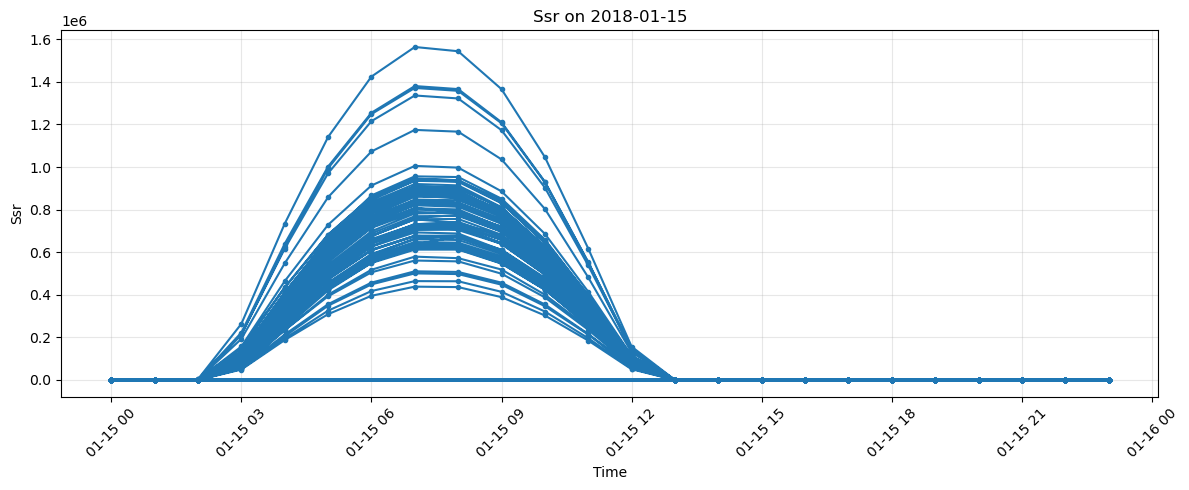

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-36.866035,0.0,0.284668,35.25,0.972046,77.5,0.0,3.6000e-12,0.0,0.0,0.0,-157811.25,-225859.5625,421205.375,372718.75,241.832947,0.972046,2018-01-15 00:00:00,0.000004,0.0,0.0,-580215.0,-578913.0,0.61496,1.913864,0.0,-0.352936,1.43219
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-35.825348,0.0,0.284668,35.25,0.974152,77.5,0.000702,3.6000e-12,0.0,0.0,0.0,-162705.125,-214641.9375,408939.25,373661.9375,241.79158,0.974152,2018-01-15 01:00:00,0.000003,0.0,0.0,-575022.0,-573343.0,0.591339,1.70842,0.0,-0.286331,1.734161
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-34.497498,0.0,0.284668,35.25,0.854095,77.5,0.000702,3.6000e-12,0.0,0.0,0.0,-156233.4375,-204176.375,412409.9375,375943.5625,241.885132,0.854095,2018-01-15 02:00:00,0.000002,0.0,0.0,-572226.0,-568834.0,0.626221,1.671066,0.0,-0.147141,1.995972
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",195968.0,0.0,0.005654,162112.0,1.0,0.0,-33.316917,0.0,0.284668,35.25,0.864075,77.5,0.001373,56960.0,62016.0,263360.0,276608.0,-163973.3125,-199126.125,410291.0,378653.9375,241.973267,0.864777,2018-01-15 03:00:00,0.000002,157184.0,160768.0,-572073.0,-567374.0,0.616745,1.683121,26768.0,-0.111084,2.038452
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",826816.0,0.0,0.005654,777152.0,1.0,0.0,-32.895897,0.0,0.284668,35.25,0.837189,77.5,0.003448,213312.0,234432.0,1.008704e6,1.01952e6,-208546.5,-223967.5,403773.125,383083.5,241.039505,0.837189,2018-01-15 04:00:00,0.000001,429952.0,448896.0,-589513.0,-583209.0,0.581116,1.781586,104960.0,-0.021484,2.215454
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-45.892113,0.0,0.507568,32.5,0.0,79.0,0.0,3.6000e-12,0.0,0.0,0.0,-180136.0,-219901.0,432245.8125,427934.5,252.223267,0.0,2018-01-15 19:00:00,0.0,0.0,0.0,-606640.0,-622395.0,-0.935532,0.158463,0.0,0.681076,4.319534
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-45.438629,0.0,0.507568,32.5,0.0,79.0,0.0,3.6000e-12,0.0,0.0,0.0,-174010.0,-211746.0,434618.8125,426574.0625,251.528473,0.0,2018-01-15 20:00:00,0.0,0.0,0.0,-604125.0,-617411.0,-0.906509,0.106522,0.0,0.694977,4.36763
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-45.308502,0.0,0.507568,32.5,0.002502,79.0,0.0,3.6000e-12,0.0,0.0,0.0,-168112.0,-207650.0,438565.4375,424636.8125,252.132889,0.002502,2018-01-15 21:00:00,0.0,0.0,0.0,-604017.0,-614367.0,-0.926666,0.07579,0.0,0.716568,4.460159


In [34]:
plot_day_polars_direct(step2_trimmed_data_2018_01_pldf.filter(pl.col("adm2_code")=="76128533B57183548666997"), date='2018-01-15', column='ssr')

##### Step 3 Data

In [35]:
step3_consolidated_data_2018_pldf = pl.read_parquet(source=step3_consolidated_data_2018_path)

In [ ]:
# Describe
print('Step 3 Consolidated Data 2018 Description')
display(step3_consolidated_data_2018_pldf.describe())

Step 3 Consolidated Data 2018 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""38911920""","""38911920""","""38911920""","""38911920""","""38911920""","""38911920""",3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,"""38911920""",3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,744183.75,0.279998,0.663284,537282.4375,1.0,0.339125,15.011622,1.794127,1.656656,22.886875,0.145379,79.613518,0.196464,619716.375,760950.5625,769735.25,940738.9375,-254741.625,-290712.96875,1.3417e6,1.303866e6,297.215485,0.446714,"""2018-07-02 11:30:00""",0.000134,980294.1875,1.1233e6,-935417.25,-1.0201e6,0.530054,0.814347,87792.46875,0.055114,0.051291
"""std""",null,null,null,null,null,null,990649.125,0.31615,0.325826,822262.875,0.0,0.415897,22.104488,1.230856,0.750643,5.504276,0.271267,5.880583,0.277514,854698.375,988673.8125,1.0494e6,1.2052e6,154294.3125,135913.5625,219353.21875,219202.4375,9.885744,0.413831,null,0.000579,1.250352e6,1.4062e6,173112.984375,83538.429688,2.261122,3.62109,121155.515625,1.616347,2.588896
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-117.629463,0.0,0.0,8.25,0.0,68.25,0.0,3.6000e-12,0.0,0.0,0.0,-1.288219e6,-1.316024e6,299944.0,299413.0625,226.659988,0.0,"""2018-01-01 00:00:00""",0.0,0.0,0.0,-1.442047e6,-1.448796e6,-14.483887,-19.481308,0.0,-18.665878,-20.938965
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,2.09494,0.981934,1.084717,19.5,0.0,75.5,0.0,3.6000e-12,0.0,0.0,0.0,-328607.0,-351867.125,1210556.5,1.189769e6,293.922363,0.009064,"""2018-04-02 06:00:00""",0.0,0.0,0.0,-1.054833e6,-1.069468e6,-1.014465,-1.585938,0.0,-1.005539,-1.55513
"""50%""",null,null,null,null,null,null,12544.0,0.149811,0.755631,1984.0,1.0,0.038879,23.122749,1.973877,1.619019,23.5,0.0,78.25,0.05777,26112.0,34176.0,33344.0,46336.0,-232399.0,-259054.0,1.379145e6,1345814.5,299.034027,0.333374,"""2018-07-02 12:00:00""",0.0,78336.0,90880.0,-991460.0,-1.019785e6,0.319214,0.51268,4184.0,-0.017532,-0.034744
"""75%""",null,null,null,null,null,null,1.59168e6,0.504298,0.976124,918144.0,1.0,0.844604,32.266884,2.349365,2.261597,26.75,0.146149,82.5,0.290527,1.183552e6,1.622464e6,1.500544e6,2.024384e6,-142565.1875,-194812.125,1.5153e6,1.462121e6,302.89035,0.945465,"""2018-10-01 17:00:00""",0.000012,2.00768e6,2.394496e6,-841265.0,-973936.0,1.951126,3.257156,167928.0,1.006317,1.555649
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",3.647936e6,1.0,1.0,3.732736e6,1.0,1.0,46.955696,6.530518,3.891846,35.25,1.0,97.25,1.0,3.5328e6,3.608896e6,4.344704e6,4.261632e6,126659.75,-64512.5,1871951.5,1.8728e6,322.637939,1.0,"""2018-12-31 23:00:00""",0.055838,4.530944e6,4.455808e6,-249522.0,-500172.0,12.241653,16.166748,542032.0,15.475861,19.226913


In [ ]:
print('Step 3 Consolidated Data 2018 — First 8 rows:')
display(step3_consolidated_data_2018_pldf.head(8))
print('Step 3 Consolidated Data 2018 — Last 8 rows:')
display(step3_consolidated_data_2018_pldf.tail(8))

Step 3 Consolidated Data 2018 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.509537,0.0,0.284668,35.25,0.581116,77.5,0.473907,3.6000e-12,0.0,0.0,0.0,-126984.0,-145374.5,394172.25,374672.0,240.809692,0.64978,2018-01-01 00:00:00,0.000001,0.0,0.0,-538943.0,-534469.0,0.284775,1.377716,0.0,-0.811127,-0.158432
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.390999,0.0,0.284668,35.25,0.758057,77.5,0.664978,3.6000e-12,0.0,0.0,0.0,-129250.0625,-141619.4375,388486.3125,373667.75,241.025314,0.837372,2018-01-01 01:00:00,0.000002,0.0,0.0,-535883.0,-531899.0,0.245407,1.382904,0.0,-0.813004,-0.270203
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.531189,0.0,0.284668,35.25,0.468719,77.5,0.502258,3.6000e-12,0.0,0.0,0.0,-132745.125,-138690.625,381255.875,372574.6875,240.921371,0.653595,2018-01-01 02:00:00,0.000001,0.0,0.0,-533275.0,-530085.0,0.249374,1.268295,0.0,-0.791077,0.019287
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",181184.0,0.0,0.005654,177152.0,1.0,0.0,-21.180832,0.0,0.284668,35.25,0.580414,77.5,0.241852,47872.0,46144.0,258752.0,261184.0,-138297.0,-135713.0,379923.9375,371232.875,239.965469,0.597504,2018-01-01 03:00:00,9.5367e-7,146944.0,144640.0,-535470.0,-528148.0,0.247238,1.172256,25776.0,-0.786148,0.400345
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",783104.0,0.0,0.005654,716288.0,1.0,0.0,-21.873825,0.0,0.284668,35.25,0.609406,77.5,0.168884,170176.0,176256.0,952384.0,977856.0,-162683.0,-159374.0,386818.3125,370614.0625,237.582184,0.628021,2018-01-01 04:00:00,9.5367e-7,388864.0,392832.0,-553803.0,-540888.0,0.280487,1.242538,98704.0,-0.803772,0.582336
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.376256e6,0.0,0.005654,1.327552e6,1.0,0.0,-22.199249,0.0,0.284668,35.25,0.643738,77.5,0.202515,284288.0,289984.0,1.609984e6,1.628352e6,-192507.0,-194113.0,392493.5,371087.6875,240.023376,0.658051,2018-01-01 05:00:00,9.5367e-7,582784.0,582528.0,-572742.0,-560237.0,0.331802,1.392273,179832.0,-0.726242,0.680954
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.80192e6,0.0,0.005654,1.77952e6,1.0,0.0,-22.378044,0.0,0.284668,35.25,0.738007,77.5,0.199219,365568.0,370432.0,2.081408e6,2.089472e6,-228657.0,-227705.0,383090.75,371890.375,239.979141,0.748688,2018-01-01 06:00:00,9.5367e-7,711168.0,712832.0,-585433.0,-578824.0,0.376938,1.601379,237248.0,-0.59053,0.860504
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",2.004928e6,0.0,0.005654,1.983744e6,1.0,0.0,-20.380753,0.0,0.284668,35.25,0.731049,77.5,0.175751,404800.0,409280.0,2.30848e6,2.311616e6,-247917.9375,-247993.0,381401.6875,375739.5,240.514847,0.731049,2018-01-01 07:00:00,0.000003,776192.0,779776.0,-595411.0,-592267.0,0.407196,1.574203,267704.0,-0.530182,0.839294


Step 3 Consolidated Data 2018 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,9.274918,1.014648,0.804321,8.25,0.117249,77.75,0.040009,3.6000e-12,0.0,0.0,0.0,-188829.0,-245570.0,1.4479e6,1.3914e6,299.48819,0.117249,2018-12-31 16:00:00,0.000028,0.0,0.0,-1.072781e6,-1.088873e6,-4.666702,-6.19519,0.0,-5.28537,-7.033463
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,7.898979,1.014648,0.804321,8.25,0.101105,77.75,0.048584,3.6000e-12,0.0,0.0,0.0,-198276.0,-247830.0,1.4336e6,1389082.5,299.294739,0.101105,2018-12-31 17:00:00,0.000018,0.0,0.0,-1.074217e6,-1.088706e6,-4.588669,-6.157425,0.0,-5.314468,-7.08223
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,7.855721,1.014526,0.804321,8.25,0.085358,77.75,0.017792,3.6000e-12,0.0,0.0,0.0,-215436.0,-250912.0,1410965.5,1384949.5,299.133911,0.089813,2018-12-31 18:00:00,0.000004,0.0,0.0,-1.079956e6,-1.088265e6,-4.243683,-5.769455,0.0,-5.311264,-7.110901
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,9.164925,1.014526,0.804199,8.25,0.054443,77.75,0.022217,3.6000e-12,0.0,0.0,0.0,-242511.0,-258781.0,1.380022e6,1.3702e6,298.832336,0.054443,2018-12-31 19:00:00,0.0,0.0,0.0,-1.079305e6,-1.083108e6,-3.582214,-4.901398,0.0,-5.203751,-6.953583
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,9.043724,1.014526,0.804199,8.25,0.0546875,77.75,0.008881,3.6000e-12,0.0,0.0,0.0,-242583.0,-263670.0,1.3766e6,1.3675e6,298.394226,0.0546875,2018-12-31 20:00:00,0.0,0.0,0.0,-1.075276e6,-1.081184e6,-2.97937,-4.107651,0.0,-5.258041,-7.04364
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,9.294281,1.014526,0.804077,8.25,0.088409,77.75,0.026672,3.6000e-12,0.0,0.0,0.0,-233610.0,-264361.0,1.3814e6,1.3640e6,297.969299,0.088409,2018-12-31 21:00:00,9.5367e-7,0.0,0.0,-1.072882e6,-1.079135e6,-2.268814,-3.149338,0.0,-5.388,-7.245392
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,9.605537,1.014526,0.804077,8.25,0.095886,77.75,0.026672,3.6000e-12,0.0,0.0,0.0,-211204.0,-266859.0,1.4013e6,1.3601e6,297.468658,0.095886,2018-12-31 22:00:00,0.000004,0.0,0.0,-1.063856e6,-1.076762e6,-1.957169,-2.679871,0.0,-5.608429,-7.423615
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,8.729355,1.014526,0.804077,8.25,0.052216,77.75,0.017792,3.6000e-12,0.0,0.0,0.0,-245998.3125,-269982.625,1.3606e6,1.3554e6,297.108917,0.052216,2018-12-31 23:00:00,0.000004,0.0,0.0,-1.068616e6,-1.074823e6,-1.501816,-2.109406,0.0,-6.121826,-8.166122


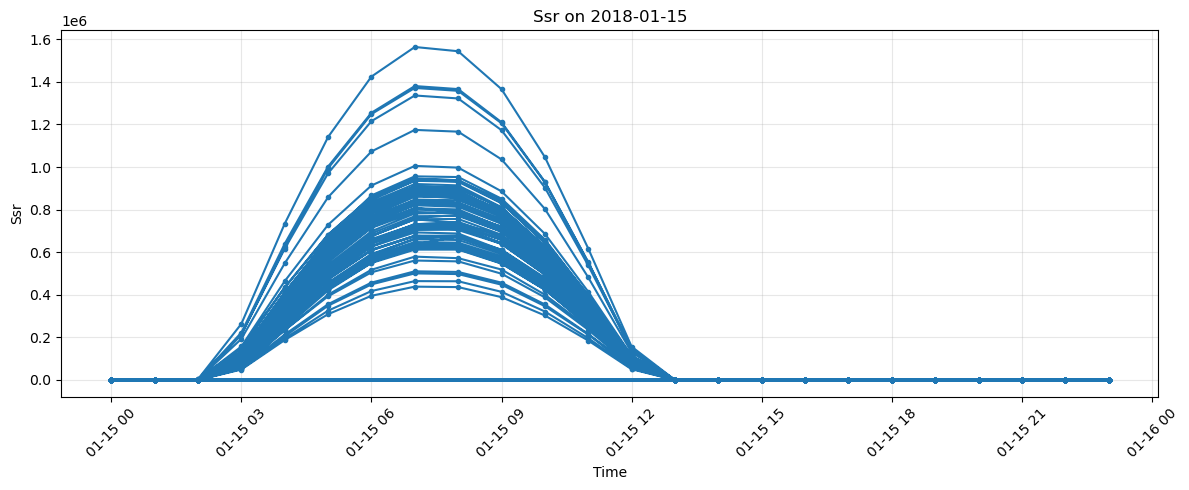

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-36.866035,0.0,0.284668,35.25,0.972046,77.5,0.0,3.6000e-12,0.0,0.0,0.0,-157811.25,-225859.5625,421205.375,372718.75,241.832947,0.972046,2018-01-15 00:00:00,0.000004,0.0,0.0,-580215.0,-578913.0,0.61496,1.913864,0.0,-0.352936,1.43219
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-35.825348,0.0,0.284668,35.25,0.974152,77.5,0.000702,3.6000e-12,0.0,0.0,0.0,-162705.125,-214641.9375,408939.25,373661.9375,241.79158,0.974152,2018-01-15 01:00:00,0.000003,0.0,0.0,-575022.0,-573343.0,0.591339,1.70842,0.0,-0.286331,1.734161
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-34.497498,0.0,0.284668,35.25,0.854095,77.5,0.000702,3.6000e-12,0.0,0.0,0.0,-156233.4375,-204176.375,412409.9375,375943.5625,241.885132,0.854095,2018-01-15 02:00:00,0.000002,0.0,0.0,-572226.0,-568834.0,0.626221,1.671066,0.0,-0.147141,1.995972
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",195968.0,0.0,0.005654,162112.0,1.0,0.0,-33.316917,0.0,0.284668,35.25,0.864075,77.5,0.001373,56960.0,62016.0,263360.0,276608.0,-163973.3125,-199126.125,410291.0,378653.9375,241.973267,0.864777,2018-01-15 03:00:00,0.000002,157184.0,160768.0,-572073.0,-567374.0,0.616745,1.683121,26768.0,-0.111084,2.038452
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",826816.0,0.0,0.005654,777152.0,1.0,0.0,-32.895897,0.0,0.284668,35.25,0.837189,77.5,0.003448,213312.0,234432.0,1.008704e6,1.01952e6,-208546.5,-223967.5,403773.125,383083.5,241.039505,0.837189,2018-01-15 04:00:00,0.000001,429952.0,448896.0,-589513.0,-583209.0,0.581116,1.781586,104960.0,-0.021484,2.215454
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-45.892113,0.0,0.507568,32.5,0.0,79.0,0.0,3.6000e-12,0.0,0.0,0.0,-180136.0,-219901.0,432245.8125,427934.5,252.223267,0.0,2018-01-15 19:00:00,0.0,0.0,0.0,-606640.0,-622395.0,-0.935532,0.158463,0.0,0.681076,4.319534
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-45.438629,0.0,0.507568,32.5,0.0,79.0,0.0,3.6000e-12,0.0,0.0,0.0,-174010.0,-211746.0,434618.8125,426574.0625,251.528473,0.0,2018-01-15 20:00:00,0.0,0.0,0.0,-604125.0,-617411.0,-0.906509,0.106522,0.0,0.694977,4.36763
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-45.308502,0.0,0.507568,32.5,0.002502,79.0,0.0,3.6000e-12,0.0,0.0,0.0,-168112.0,-207650.0,438565.4375,424636.8125,252.132889,0.002502,2018-01-15 21:00:00,0.0,0.0,0.0,-604017.0,-614367.0,-0.926666,0.07579,0.0,0.716568,4.460159


In [36]:
plot_day_polars_direct(step3_consolidated_data_2018_pldf.filter(pl.col("adm2_code")=="76128533B57183548666997"), date='2018-01-15', column='ssr')

In [ ]:
# step1_masked_data_2018_01_pldf = pl.read_parquet(source=step1_masked_data_2018_01_path)
# step1_masked_data_2018_03_pldf = pl.read_parquet(source=step1_masked_data_2018_03_path)
# step1_masked_data_2018_12_pldf = pl.read_parquet(source=step1_masked_data_2018_12_path)
# step2_trimmed_data_2018_01_pldf = pl.read_parquet(source=step2_trimmed_data_2018_01_path)
# step2_trimmed_data_2018_03_pldf = pl.read_parquet(source=step2_trimmed_data_2018_03_path)
# step2_trimmed_data_2018_12_pldf = pl.read_parquet(source=step2_trimmed_data_2018_12_path)
# step3_consolidated_data_2018_pldf = pl.read_parquet(source=step3_consolidated_data_2018_path)
# step3_consolidated_data_2019_pldf = pl.read_parquet(source=step3_consolidated_data_2019_path)
# step4_interpolated_data_2018_pldf = pl.read_parquet(source=step4_interpolated_data_2018_path)
# step4_interpolated_data_2019_pldf = pl.read_parquet(source=step4_interpolated_data_2019_path)
# step5_interpolated_boundary_fixed_data_2018_pldf = pl.read_parquet(source=step5_interpolated_boundary_fixed_data_2018_path)
# step5_interpolated_boundary_fixed_data_2019_pldf = pl.read_parquet(source=step5_interpolated_boundary_fixed_data_2019_path)
# step6_interpolated_final_data_2018_pldf = pl.read_parquet(step6_interpolated_final_data_2018_path)
# step6_interpolated_final_data_2019_pldf = pl.read_parquet(source=step6_interpolated_final_data_2019_path)
# step7_processed_data_ADM0_pldf = pl.read_parquet(source=step7_processed_data_ADM0_path)
# step8_processed_data_ADM0_pldf = pl.read_parquet(source=step8_processed_data_ADM0_path)
# step7_processed_data_ADM1_pldf = pl.read_parquet(source=step7_processed_data_ADM1_path)
# step8_processed_data_ADM1_pldf = pl.read_parquet(source=step8_processed_data_ADM1_path)

In [37]:
step3_consolidated_data_2019_pldf = pl.read_parquet(source=step3_consolidated_data_2019_path)

In [ ]:
# Describe
print('Step 3 Consolidated Data 2018 Description')
display(step3_consolidated_data_2019_pldf.describe())

Step 3 Consolidated Data 2018 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""38911920""","""38911920""","""38911920""","""38911920""","""38911920""","""38911920""",3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,"""38911920""",3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7,3.891192e7
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,736478.875,0.279998,0.663284,513012.9375,1.0,0.355985,18.172079,1.794127,1.656656,22.886875,0.164124,79.613518,0.218183,602274.75,754034.1875,750336.0,934731.5625,-238104.0625,-278538.84375,1.3577e6,1.315337e6,297.17395,0.483897,"""2019-07-02 11:30:00""",0.000164,967623.875,1.1219e6,-919582.9375,-1.0115e6,0.400158,0.592546,86148.421875,0.062008,0.0872
"""std""",null,null,null,null,null,null,983409.3125,0.31615,0.325826,800732.75,0.0,0.414131,19.705669,1.230856,0.750643,5.504276,0.28017,5.880583,0.288504,839174.25,982714.0625,1.0323e6,1.1996e6,149274.234375,130999.859375,218034.25,222985.90625,9.978211,0.405366,null,0.00065,1.2402e6,1.4056e6,173189.671875,81860.6875,2.212089,3.554847,119874.359375,1.661134,2.681506
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-124.856392,0.0,0.0,8.25,0.0,68.25,0.0,3.6000e-12,0.0,0.0,0.0,-1.16613e6,-1.146919e6,281736.625,282776.0,226.246216,0.0,"""2019-01-01 00:00:00""",0.0,0.0,0.0,-1.401714e6,-1.398382e6,-17.030457,-23.454788,0.0,-16.953857,-23.844971
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,7.488907,0.981934,1.084717,19.5,0.0,75.5,0.0,3.6000e-12,0.0,0.0,0.0,-308640.0,-335373.0,1.232198e6,1.201911e6,293.705505,0.043915,"""2019-04-02 06:00:00""",0.0,0.0,0.0,-1.041418e6,-1.059137e6,-1.098236,-1.778671,0.0,-1.011703,-1.560242
"""50%""",null,null,null,null,null,null,12032.0,0.149811,0.755631,1600.0,1.0,0.0867,25.432846,1.973877,1.619019,23.5,0.011139,78.25,0.088928,25024.0,33600.0,32192.0,45696.0,-214284.0,-249737.0,1.4062e6,1.3660e6,298.962219,0.429535,"""2019-07-02 12:00:00""",0.0,77184.0,90752.0,-973668.0,-1.009606e6,0.17804,0.286514,4072.0,-0.003189,0.02327
"""75%""",null,null,null,null,null,null,1.569344e6,0.504298,0.976124,844608.0,1.0,0.854218,33.237633,2.349365,2.261597,26.75,0.19165,82.5,0.320831,1.135936e6,1.601728e6,1.443712e6,2.006976e6,-127618.625,-183959.0,1.525233e6,1.4732e6,302.796875,0.953064,"""2019-10-01 17:00:00""",0.00003,1.964928e6,2.391424e6,-822817.0,-967365.0,1.781097,2.957474,162560.0,1.051437,1.684219
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",3.653824e6,1.0,1.0,3.749376e6,1.0,1.0,49.57196,6.530518,3.891846,35.25,1.0,97.25,1.0,3.455744e6,3.539392e6,4.302976e6,4.26112e6,146491.0,-71117.0,1.8937e6,1867319.5,323.096436,1.0,"""2019-12-31 23:00:00""",0.056358,4.534528e6,4.451072e6,-230268.0,-492501.0,19.403717,25.960983,541168.0,19.564102,27.010315


In [ ]:
print('Step 3 Consolidated Data 2019 — First 8 rows:')
display(step3_consolidated_data_2019_pldf.head(8))
print('Step 3 Consolidated Data 2019 — Last 8 rows:')
display(step3_consolidated_data_2019_pldf.tail(8))

Step 3 Consolidated Data 2019 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-24.683052,0.0,0.284668,35.25,0.840637,77.5,0.429077,3.6000e-12,0.0,0.0,0.0,-129598.8125,-174202.1875,422091.375,396466.0,241.923996,0.956573,2019-01-01 00:00:00,0.000003,0.0,0.0,-555753.0,-559332.0,0.379761,1.131012,0.0,-0.376511,1.480408
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-23.36898,0.0,0.284668,35.25,0.804108,77.5,0.413361,3.6000e-12,0.0,0.0,0.0,-112271.75,-167503.25,441282.5,398176.125,242.710541,0.941406,2019-01-01 01:00:00,0.000003,0.0,0.0,-557640.0,-556960.0,0.352295,0.965942,0.0,-0.384247,1.465958
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-22.150871,0.0,0.284668,35.25,0.834259,77.5,0.451965,3.6000e-12,0.0,0.0,0.0,-110761.3125,-168304.5,442508.5625,399913.6875,243.388046,0.961395,2019-01-01 02:00:00,0.000004,0.0,0.0,-557285.0,-558749.0,0.317902,0.822433,0.0,-0.374634,1.58963
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",176000.0,0.0,0.005654,122112.0,1.0,0.0,-20.825165,0.0,0.284668,35.25,0.858398,77.5,0.417511,59776.0,72960.0,234816.0,255360.0,-108656.0,-164144.0,454662.25,401767.125,242.158173,0.952789,2019-01-01 03:00:00,0.000004,161920.0,174848.0,-561983.0,-557944.0,0.314682,0.714188,24712.0,-0.410339,1.725586
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",766976.0,0.0,0.005654,539968.0,1.0,0.0,-18.930191,0.0,0.284668,35.25,0.933685,77.5,0.825653,211072.0,283968.0,851648.0,958720.0,-97706.0,-199576.0,522384.4375,405727.875,240.27037,1.0,2019-01-01 04:00:00,0.000007,460032.0,508416.0,-596936.0,-578249.0,0.369431,0.955704,89344.0,-0.402878,1.705994
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.349056e6,0.0,0.005654,897536.0,1.0,0.0,-18.083679,0.0,0.284668,35.25,0.947723,77.5,0.990692,353472.0,469440.0,1.41856e6,1.596096e6,-127624.0,-266160.0,550838.3125,411938.375,244.188599,0.990692,2019-01-01 05:00:00,0.000022,709376.0,775168.0,-607173.0,-615354.0,0.327591,1.020096,158048.0,-0.322693,1.646347
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.767744e6,0.0,0.005654,1.146624e6,1.0,0.0,-17.264687,0.0,0.284668,35.25,0.966187,77.5,1.0,461376.0,600192.0,1.857024e6,2.047808e6,-183815.0,-319538.0,532277.8125,419279.25,243.638504,1.0,2019-01-01 06:00:00,0.000034,878336.0,959872.0,-611214.0,-646222.0,0.317368,0.947388,220128.0,-0.220734,1.577805
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.965184e6,0.0,0.005654,1.068992e6,1.0,0.011047,-16.860565,0.0,0.284668,35.25,0.969604,77.5,1.0,495040.0,660736.0,2.012544e6,2.264576e6,-174880.0,-338630.0,567495.6875,425346.75,243.797028,1.0,2019-01-01 07:00:00,0.000053,948096.0,1.051264e6,-598366.0,-660037.0,0.25679,0.826294,239448.0,-0.093384,1.460449


Step 3 Consolidated Data 2019 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,1.0,23.839424,1.014648,0.804321,8.25,0.145813,77.75,0.064453,3.6000e-12,0.0,0.0,0.0,-197497.0,-217599.0,1.4281e6,1.4244e6,299.403931,1.0,2019-12-31 16:00:00,0.000047,0.0,0.0,-1.02343e6,-1.073846e6,-3.422058,-4.971405,0.0,-3.374878,-4.557709
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,1.0,26.963188,1.014648,0.804321,8.25,0.035706,77.75,0.063019,3.6000e-12,0.0,0.0,0.0,-182115.0,-213879.0,1442384.5,1.4275e6,298.876831,1.0,2019-12-31 17:00:00,0.000055,0.0,0.0,-1.000564e6,-1.07027e6,-3.057632,-4.484131,0.0,-3.569885,-4.829193
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.998566,28.535629,1.014526,0.804321,8.25,0.180786,77.75,0.257904,3.6000e-12,0.0,0.0,0.0,-166876.0,-212045.0,1.4566e6,1.4289e6,298.608521,0.998566,2019-12-31 18:00:00,0.000094,0.0,0.0,-971633.0,-1.06817e6,-2.70668,-3.986908,0.0,-3.809937,-5.126434
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.980133,25.382988,1.014526,0.804199,8.25,0.265808,77.75,0.207306,3.6000e-12,0.0,0.0,0.0,-193474.0,-221438.0,1.4302e6,1.419285e6,298.42688,0.989807,2019-12-31 19:00:00,0.000021,0.0,0.0,-981638.0,-1.065357e6,-2.413544,-3.512833,0.0,-4.14917,-5.559372
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,1.0,24.577087,1.014526,0.804199,8.25,0.255493,77.75,0.238831,3.6000e-12,0.0,0.0,0.0,-155148.0,-219160.0,1.4692e6,1.4214e6,298.190063,1.0,2019-12-31 20:00:00,0.000056,0.0,0.0,-1.01759e6,-1.065007e6,-1.901382,-2.793243,0.0,-4.308716,-5.858978
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,1.0,24.332771,1.014526,0.804077,8.25,0.143921,77.75,0.30014,3.6000e-12,0.0,0.0,0.0,-168590.1875,-220015.0,1.4541e6,1.4211e6,297.976013,1.0,2019-12-31 21:00:00,0.000146,0.0,0.0,-1.016138e6,-1.06368e6,-1.646088,-2.269562,0.0,-4.339722,-6.027771
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,1.0,25.3396,1.014526,0.804077,8.25,0.249786,77.75,0.268494,3.6000e-12,0.0,0.0,0.0,-151856.625,-219711.75,1.469749e6,1.4204e6,297.792358,1.0,2019-12-31 22:00:00,0.000135,0.0,0.0,-1.012095e6,-1.060127e6,-1.078506,-1.442764,0.0,-4.308243,-6.042618
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,1.0,26.876808,1.014526,0.804077,8.25,0.226074,77.75,0.313843,3.6000e-12,0.0,0.0,0.0,-160234.375,-220296.4375,1.4600e6,1.4183e6,297.499939,1.0,2019-12-31 23:00:00,0.000096,0.0,0.0,-914219.0,-1.055963e6,-0.851349,-1.145782,0.0,-4.686569,-6.512543


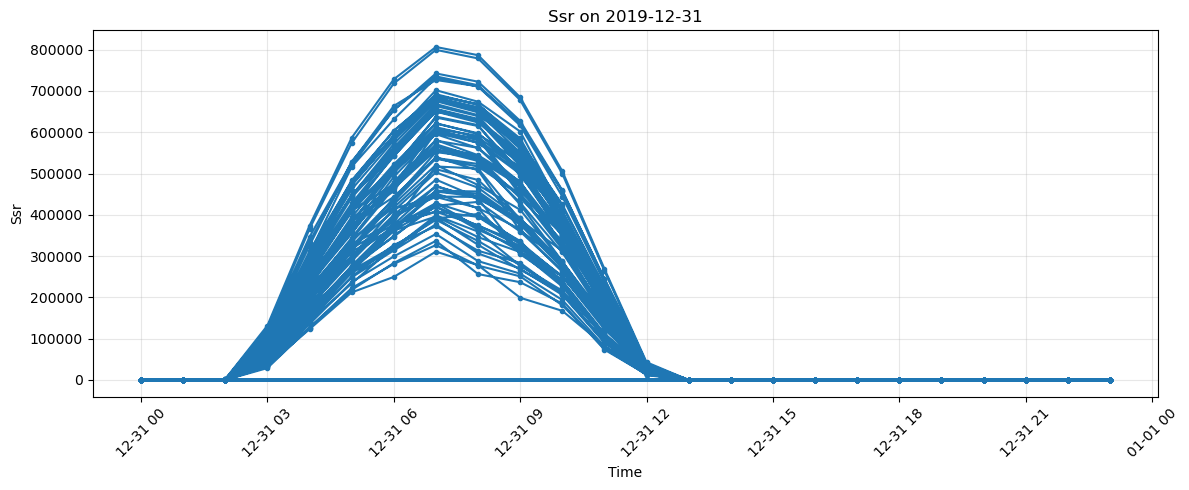

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-18.359283,0.0,0.284668,35.25,0.921356,77.5,0.999298,3.6000e-12,0.0,0.0,0.0,61708.5625,-196442.4375,642246.4375,377020.75,241.863647,0.999298,2019-12-31 00:00:00,0.000076,0.0,0.0,-547654.0,-559782.0,0.160522,0.337677,0.0,-0.490875,1.626144
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-17.64357,0.0,0.284668,35.25,0.92688,77.5,0.999298,3.6000e-12,0.0,0.0,0.0,36790.1875,-214423.4375,617155.375,378554.8125,241.941849,0.999298,2019-12-31 01:00:00,0.000101,0.0,0.0,-550069.0,-569789.0,0.145157,0.250931,0.0,-0.501465,1.641251
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-17.516228,0.0,0.284668,35.25,0.956879,77.5,1.0,3.6000e-12,0.0,0.0,0.0,55584.125,-208534.0625,640826.0,379280.75,242.400208,1.0,2019-12-31 02:00:00,0.00012,0.0,0.0,-555258.0,-566727.0,0.185165,0.360794,0.0,-0.507751,1.614075
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",175744.0,0.0,0.005654,11776.0,1.0,0.0,-17.122993,0.0,0.284668,35.25,0.985474,77.5,0.994995,31680.0,59840.0,149376.0,258112.0,53479.75,-215663.125,648426.875,379777.375,241.254272,1.0,2019-12-31 03:00:00,0.000135,134016.0,161792.0,-545860.0,-570370.0,0.221619,0.534164,20832.0,-0.494949,1.457901
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",757504.0,0.0,0.005654,94016.0,1.0,0.0,-17.240761,0.0,0.284668,35.25,0.98877,77.5,1.0,127040.0,228800.0,604096.0,960512.0,45321.0,-237973.0,673101.125,380635.9375,240.349884,1.0,2019-12-31 04:00:00,0.000144,397952.0,454528.0,-545995.0,-582429.0,0.245239,0.728531,73688.0,-0.486069,1.470245
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-29.206856,0.0,0.5078125,32.5,0.665405,79.0,0.095215,3.6000e-12,0.0,0.0,0.0,-164770.0,-195774.0,434955.3125,399220.9375,249.020645,0.700836,2019-12-31 19:00:00,0.000003,0.0,0.0,-590886.0,-579885.0,-0.850067,-0.626114,0.0,0.716064,3.76387
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-29.426819,0.0,0.5078125,32.5,0.580536,79.0,0.696289,3.6000e-12,0.0,0.0,0.0,-171180.0,-190040.0,416584.25,396876.3125,248.44397,0.876617,2019-12-31 20:00:00,0.000003,0.0,0.0,-577974.0,-574127.0,-0.852554,-0.681915,0.0,0.648315,3.662506
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-28.96801,0.0,0.5078125,32.5,0.547577,79.0,0.766663,3.6000e-12,0.0,0.0,0.0,-129038.1875,-182223.0,461003.6875,394454.125,247.661575,0.8414,2019-12-31 21:00:00,0.000002,0.0,0.0,-578682.0,-567168.0,-0.9664,-0.856476,0.0,0.536255,3.569885


In [38]:
plot_day_polars_direct(step3_consolidated_data_2019_pldf.filter(pl.col("adm2_code")=="76128533B57183548666997"), date='2019-12-31', column='ssr')

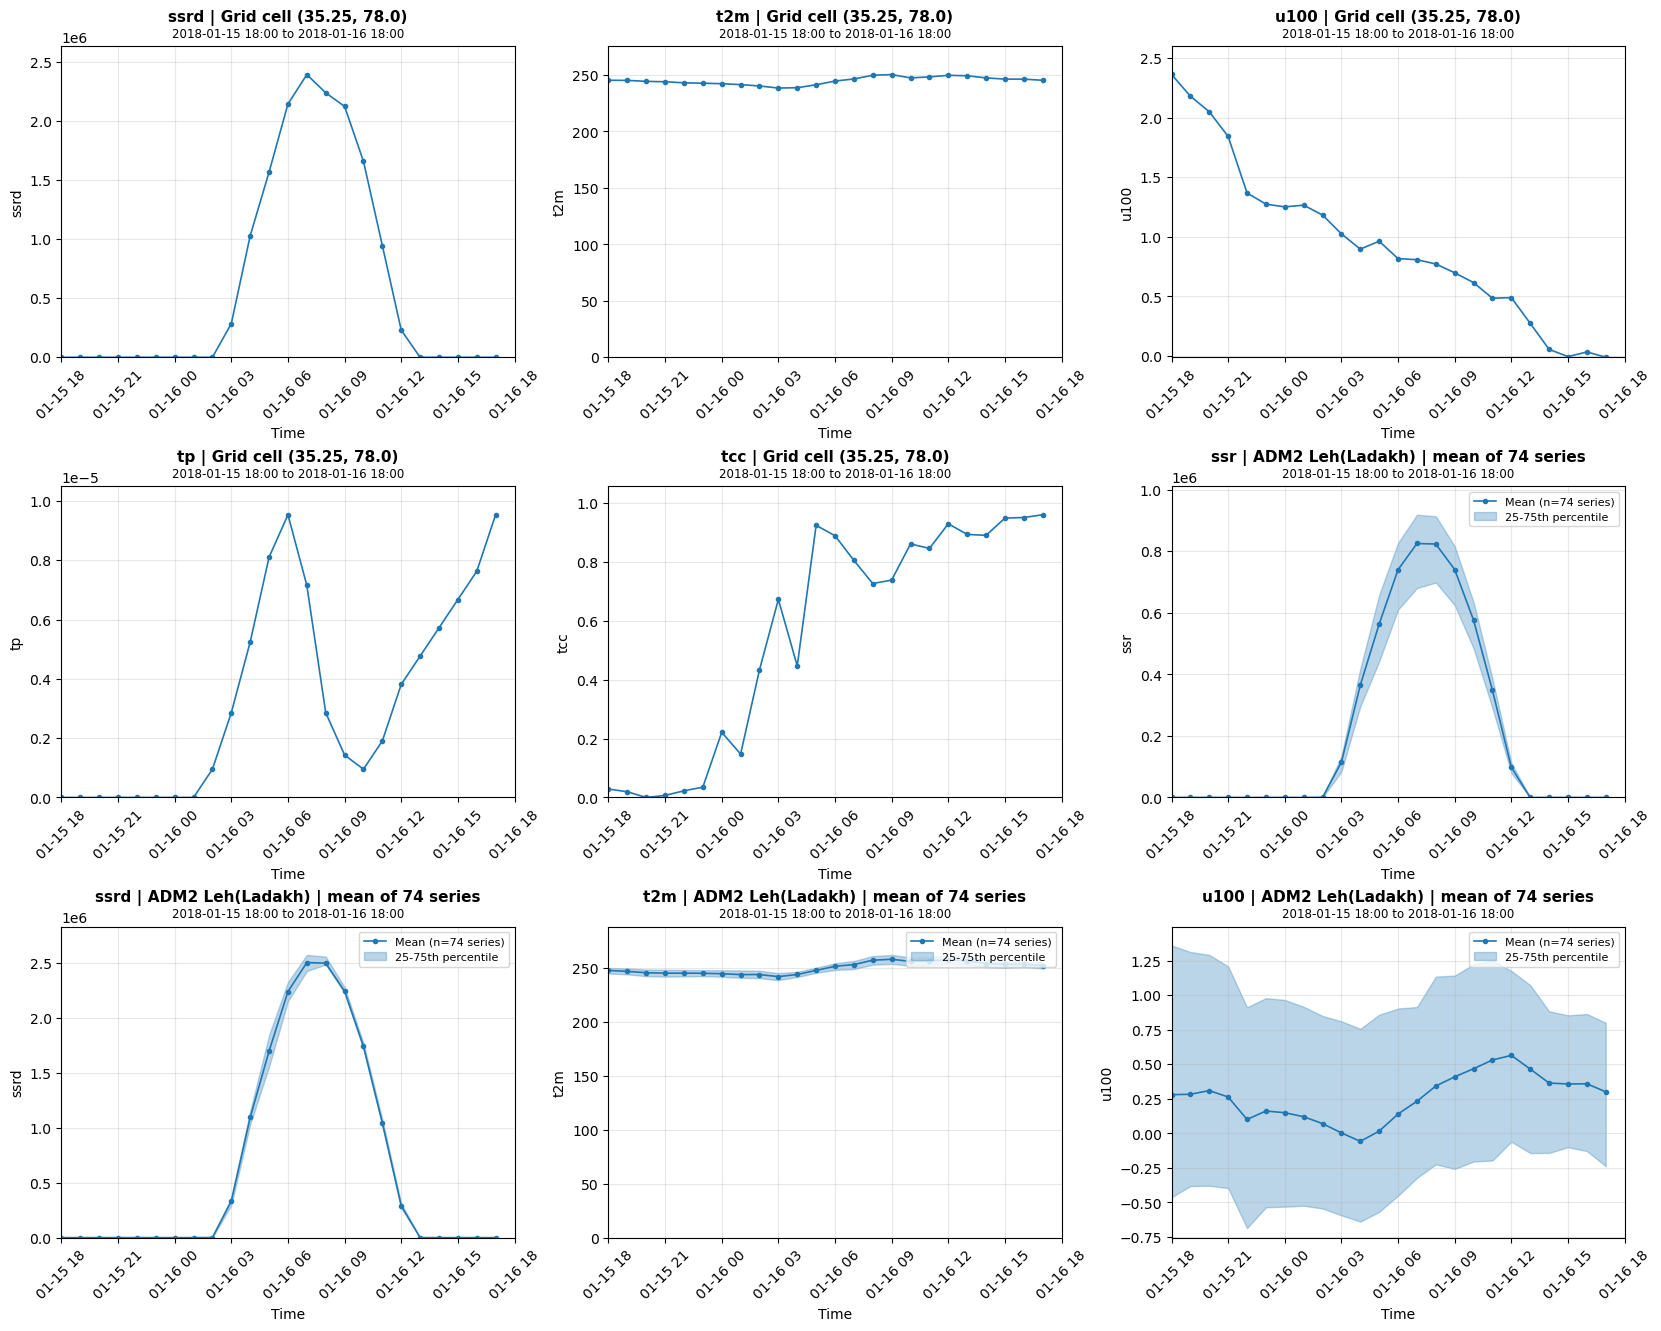

In [85]:
fig, axes, extracted = plot_polars_time_series_grid(df=step3_consolidated_data_2018_pldf, plot_specs=plot_specs_2018)

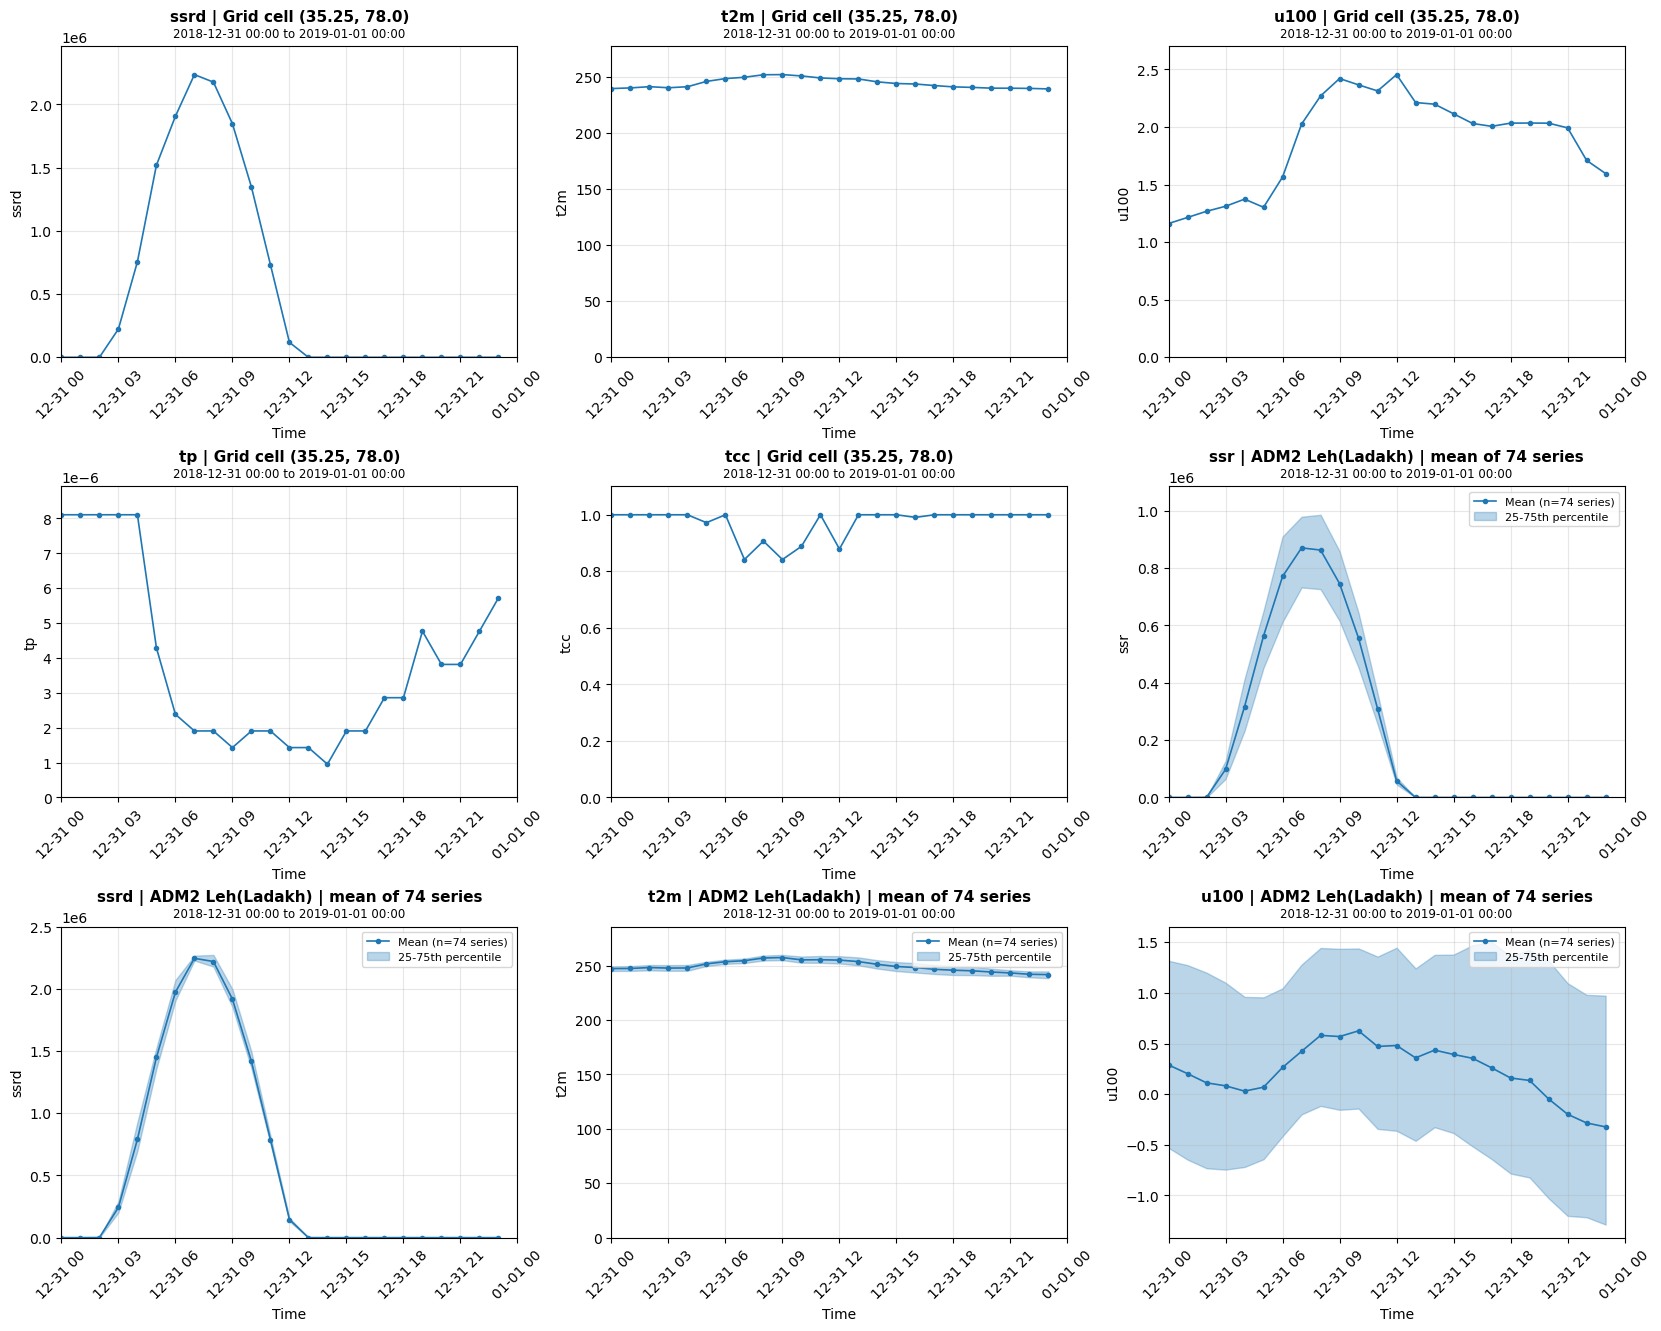

In [86]:
fig, axes, extracted = plot_polars_time_series_grid(df=step3_consolidated_data_2018_pldf, plot_specs=eo_plot_specs_2018)

##### Step 4 Data

In [19]:
step4_interpolated_data_2018_pldf = pl.read_parquet(source=step4_interpolated_data_2018_path)

In [20]:
# Describe
print('Step 4 Interpolated Data 2018 Description')
display(step4_interpolated_data_2018_pldf.describe())

Step 4 Interpolated Data 2018 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""77819398""","""77819398""","""77819398""","""77819398""","""77819398""","""77819398""",7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,"""77819398""",7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7,7.7819398e7
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,372113.09375,0.279998,0.663284,268656.53125,1.0,0.339136,15.013229,1.794127,1.656658,22.886875,0.145382,79.613518,0.196471,309875.875,380497.0,384889.59375,470396.3125,-127372.007812,-145357.96875,670863.4375,651939.9375,297.216278,0.446725,"""2018-07-02 11:30:00""",0.000067,490175.09375,561664.6875,-467708.28125,-510057.40625,0.530107,0.814456,43898.742188,0.055154,0.051368
"""std""",null,null,null,null,null,null,496895.34375,0.31615,0.325826,412497.21875,0.0,0.413967,22.094931,1.230855,0.750644,5.504276,0.268539,5.880583,0.274955,428682.53125,495822.78125,526315.875,604397.8125,79765.960938,68068.203125,109698.203125,109613.265625,9.872467,0.411804,null,0.000289,627013.875,705080.75,86646.085938,41791.820312,2.255089,3.613485,60773.738281,1.608774,2.578436
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-117.629463,0.0,0.0,8.25,0.0,68.25,0.0,9.0000e-13,0.0,0.0,0.0,-9.6494144e7,-661168.375,149618.6875,149703.953125,226.659988,0.0,"""2018-01-01 00:00:00""",0.0,0.0,0.0,-721858.4375,-724650.1875,-14.483887,-19.481308,0.0,-18.665878,-20.938965
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,2.105911,0.981934,1.084717,19.5,0.0,75.5,0.0,1.8000e-12,0.0,0.0,0.0,-164236.734375,-175913.84375,605270.4375,594875.5625,293.938171,0.010834,"""2018-04-02 05:30:00""",0.0,0.0,0.0,-527435.25,-534734.0,-1.009903,-1.580833,0.0,-0.999832,-1.54792
"""50%""",null,null,null,null,null,null,5483.404297,0.149811,0.755631,865.791992,1.0,0.045258,23.123985,1.973877,1.619019,23.5,0.0,78.25,0.060898,11806.269531,15417.821289,15096.882812,20967.796875,-116133.625,-129448.273438,689567.875,672913.25,299.038757,0.336029,"""2018-07-02 11:30:00""",0.0,35864.730469,41469.574219,-495754.40625,-509875.09375,0.317169,0.510361,1902.886841,-0.017502,-0.034332
"""75%""",null,null,null,null,null,null,797396.625,0.504298,0.976124,457922.875,1.0,0.837341,32.262726,2.349365,2.261597,26.75,0.149811,82.5,0.291458,592689.5625,810415.5625,751935.125,1.0162e6,-71233.992188,-97352.6875,757692.3125,731068.625,302.882324,0.941238,"""2018-10-01 17:30:00""",0.000006,1.0067e6,1.1965e6,-420648.71875,-486955.5625,1.9478,3.251923,84111.0625,0.999496,1.547913
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",1.8378e6,1.0,1.0,1.9950e6,1.0,1.0,46.955696,6.530518,3.891846,35.25,1.0,97.25,1.0,1.7732e6,1.812096e6,2.19841e6,2.1419e6,9.6503064e7,-32247.685547,938047.375,937519.5,322.637939,1.0,"""2018-12-31 23:00:00""",0.027919,2.2742e6,2243491.5,-117882.671875,-248044.53125,12.241653,16.166748,278455.46875,15.475861,19.226913


In [21]:
print('Step 4 Interpolated Data 2018 — First 8 rows:')
display(step4_interpolated_data_2018_pldf.head(8))
print('Step 4 Interpolated Data 2018 — Last 8 rows:')
display(step4_interpolated_data_2018_pldf.tail(8))

Step 4 Interpolated Data 2018 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.679626,23.215073,2.009766,2.217529,8.25,0.025208,77.25,0.00946,1.8000e-12,0.0,0.0,0.0,-103075.914062,-114321.546875,682848.75,684819.125,296.919067,0.685303,2018-01-01 00:00:00,0.0,0.0,0.0,-509683.21875,-515147.8125,-0.143936,-0.339081,0.0,-1.499603,-1.808823
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.462158,22.438404,2.009766,2.21759,8.25,0.041428,77.25,0.021362,9.0000e-13,0.0,0.0,0.0,-101169.679688,-114271.460938,682860.8125,683819.0,296.855988,0.486664,2018-01-01 00:30:00,0.0,0.0,0.0,-510147.8125,-514594.46875,-0.148972,-0.316956,0.0,-1.54351,-1.792931
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.24469,21.661736,2.009766,2.217651,8.25,0.057648,77.25,0.033264,2.7000e-12,0.0,0.0,0.0,-102304.382812,-114291.96875,681977.375,683064.8125,296.792908,0.288025,2018-01-01 01:00:00,0.0,0.0,0.0,-510727.15625,-514376.53125,-0.154007,-0.29483,0.0,-1.587418,-1.777039
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",35116.691406,0.611776,0.388224,35387.386719,1.0,0.296631,21.0975,2.009827,2.217651,8.25,0.0336,77.25,0.020416,54545.515625,49042.128906,63345.363281,62709.472656,-104842.679688,-112994.53125,678783.4375,681865.75,297.284882,0.3228,2018-01-01 01:30:00,0.0,110319.257812,105197.804688,-511171.3125,-514074.3125,-0.218918,-0.366295,6914.79248,-1.493935,-1.719696
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",77139.304688,0.611776,0.388224,77316.617188,1.0,0.348572,20.533264,2.009888,2.217651,8.25,0.009552,77.25,0.007568,113710.476562,104941.867188,131534.625,130826.523438,-110942.453125,-115824.09375,679976.4375,682133.0,297.776855,0.357574,2018-01-01 02:00:00,0.0,218256.734375,210962.1875,-512615.65625,-514666.6875,-0.283829,-0.437759,14213.208008,-1.400452,-1.662354
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",259271.53125,0.611776,0.388224,253880.484375,1.0,0.286743,20.340279,2.009888,2.217712,8.25,0.035721,77.25,0.022079,316483.78125,322087.40625,361637.53125,366417.09375,-121966.125,-123112.203125,685045.6875,683374.6875,298.161194,0.312195,2018-01-01 02:30:00,0.0,512892.375,519120.75,-515157.9375,-516181.96875,-0.300034,-0.402771,37213.625,-1.182655,-1.424461
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",409592.46875,0.611776,0.388224,401415.5,1.0,0.224915,20.147293,2.009888,2.217773,8.25,0.06189,77.25,0.036591,481084.21875,494104.59375,546970.5,553838.9375,-131754.875,-128648.78125,689374.375,685650.1875,298.545532,0.266815,2018-01-01 03:00:00,0.0,745859.625,759215.1875,-517288.09375,-517534.0625,-0.316238,-0.367783,57226.375,-0.964859,-1.186569
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",607773.9375,0.611776,0.388224,600141.1875,1.0,0.271591,20.151382,2.009949,2.217773,8.25,0.052383,77.25,0.027573,677341.125,694851.5,763186.5,767314.1875,-142384.125,-134072.09375,694408.9375,689434.1875,298.897827,0.300873,2018-01-01 03:30:00,0.0,989000.8125,1005866.5,-519321.1875,-519081.34375,-0.21563,-0.261841,84299.296875,-0.85746,-

Step 4 Interpolated Data 2018 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-34.528488,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-84176.625,-96813.765625,203920.734375,186925.875,240.318344,1.0,2018-12-31 19:30:00,0.000002,0.0,0.0,-286973.375,-280908.15625,0.095184,2.033562,0.0,1.245667,3.213303
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-35.663307,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-82822.367188,-95016.242188,202769.578125,186703.875,239.976242,1.0,2018-12-31 20:00:00,0.000002,0.0,0.0,-285102.625,-279475.84375,0.115356,2.032974,0.0,1.293716,3.246399
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-35.239201,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-87872.0,-95533.242188,194252.3125,186698.328125,239.956177,1.0,2018-12-31 20:30:00,0.000002,0.0,0.0,-280749.625,-278969.25,0.115654,2.012619,0.0,1.274635,3.293961
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-34.815094,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-85929.992188,-93499.765625,193998.015625,187114.53125,239.936111,1.0,2018-12-31 21:00:00,0.000002,0.0,0.0,-279044.375,-277477.78125,0.115952,1.992264,0.0,1.255554,3.341522
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-33.501263,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-78269.523438,-88872.398438,200577.484375,188131.109375,239.85376,1.0,2018-12-31 21:30:00,0.000003,0.0,0.0,-279291.5625,-274774.71875,-0.015335,1.851021,0.0,1.247879,3.305145
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-32.187431,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-73830.476562,-86914.601562,204032.875,188835.03125,239.771393,1.0,2018-12-31 22:00:00,0.000003,0.0,0.0,-279076.4375,-273699.28125,-0.146622,1.709778,0.0,1.240204,3.268768
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-30.965366,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-69795.085938,-86732.453125,207198.25,189565.84375,239.543671,1.0,2018-12-31 22:30:00,0.000003,0.0,0.0,-279054.5,-273948.6875,-0.112793,1.652725,0.0,1.292587,3.341362
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-29.743301,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-68059.226562,-86402.171875,208607.09375,189875.8125,239.315948,1.0,2018-12-31 23:00:00,0.000003,0.0,0.0,-279017.5,-273866.3125,-0.078964,1.595673,0.0,1.344971,3.413956


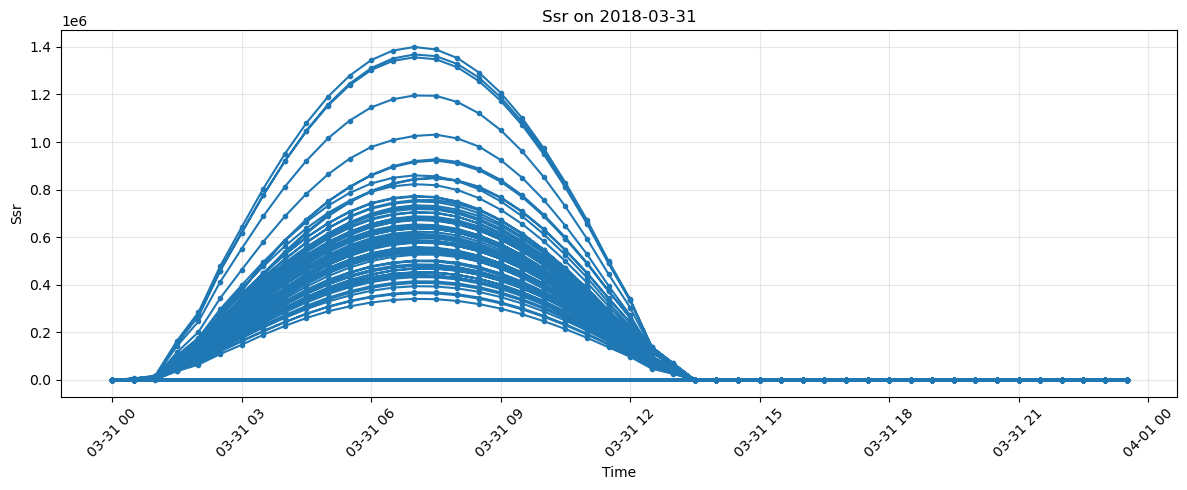

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-38.209976,0.0,0.50415,32.5,0.0,79.0,0.0,2.7000e-12,0.0,0.0,0.0,-76153.289062,-124966.257812,217088.109375,229299.234375,252.212601,0.0,2018-03-31 00:00:00,0.0,0.0,0.0,-298614.59375,-330255.53125,-0.678864,-0.477264,0.0,-0.961151,-3.562607
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",3266.442871,0.0,0.756005,3266.442871,1.0,0.0,-38.468601,0.0,0.50415,32.5,0.0,79.0,0.0,3486.658691,4027.434814,9412.03125,8870.396484,-73282.9375,-123107.5625,215665.609375,228164.375,251.853622,0.0,2018-03-31 00:30:00,0.0,9858.625,10370.765625,-296449.1875,-328761.28125,-0.720383,-0.615479,1013.748779,-0.960419,-3.436974
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",9149.556641,0.0,0.756005,9149.556641,1.0,0.0,-38.727226,0.0,0.50415,32.5,0.0,79.0,0.0,9249.34082,10756.56543,24955.96875,23577.603516,-77867.320312,-123716.429688,215713.671875,227139.75,251.494644,0.0,2018-03-31 01:00:00,0.0,24829.373047,26365.232422,-298993.8125,-328589.71875,-0.761902,-0.753693,2642.251221,-0.959686,-3.31134
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",159767.0,0.0,0.756005,159765.625,1.0,0.0,-39.367546,0.0,0.50415,32.5,0.0,79.0,0.0,89085.773438,109585.289062,239122.4375,230235.46875,-87053.195312,-121829.6875,217037.6875,225828.0625,251.80423,0.0,2018-03-31 01:30:00,0.0,166301.390625,186551.625,-303716.625,-326593.40625,-0.815155,-1.021309,21539.328125,-0.997673,-3.20607
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",289897.0,0.0,0.756005,289898.375,1.0,0.0,-40.007866,0.0,0.50415,32.5,0.0,79.0,0.0,153410.234375,190574.71875,412333.5625,399012.53125,-105185.875,-134268.75,218391.625,225581.3125,252.113815,0.0,2018-03-31 02:00:00,0.0,271330.59375,308552.375,-314653.375,-333484.59375,-0.868408,-1.288925,38148.671875,-1.03566,-3.1008
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-41.22118,0.0,0.507324,35.25,0.01683,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-98810.398438,-99999.570312,234458.03125,229737.546875,251.699448,0.01683,2018-03-31 21:30:00,0.0,0.0,0.0,-316222.4375,-313256.71875,-0.648216,0.868614,0.0,0.275894,1.829506
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-39.679871,0.0,0.507324,35.25,0.024719,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-95811.601562,-98571.4375,236371.9375,230132.4375,251.119446,0.024719,2018-03-31 22:00:00,0.0,0.0,0.0,-315859.5625,-312636.28125,-0.728592,0.765091,0.0,0.301544,1.978165
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-38.349304,0.0,0.507324,35.25,0.056931,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-94097.585938,-97967.34375,236789.125,230528.859375,250.690338,0.056931,2018-03-31 22:30:00,0.0,0.0,0.0,-315026.53125,-312523.6875,-0.721428,0.836044,0.0,0.26841,1.945374


In [22]:
plot_day_polars_direct(step4_interpolated_data_2018_pldf.filter(pl.col("adm2_code") == "76128533B57183548666997"), date='2018-03-31', column='ssr')

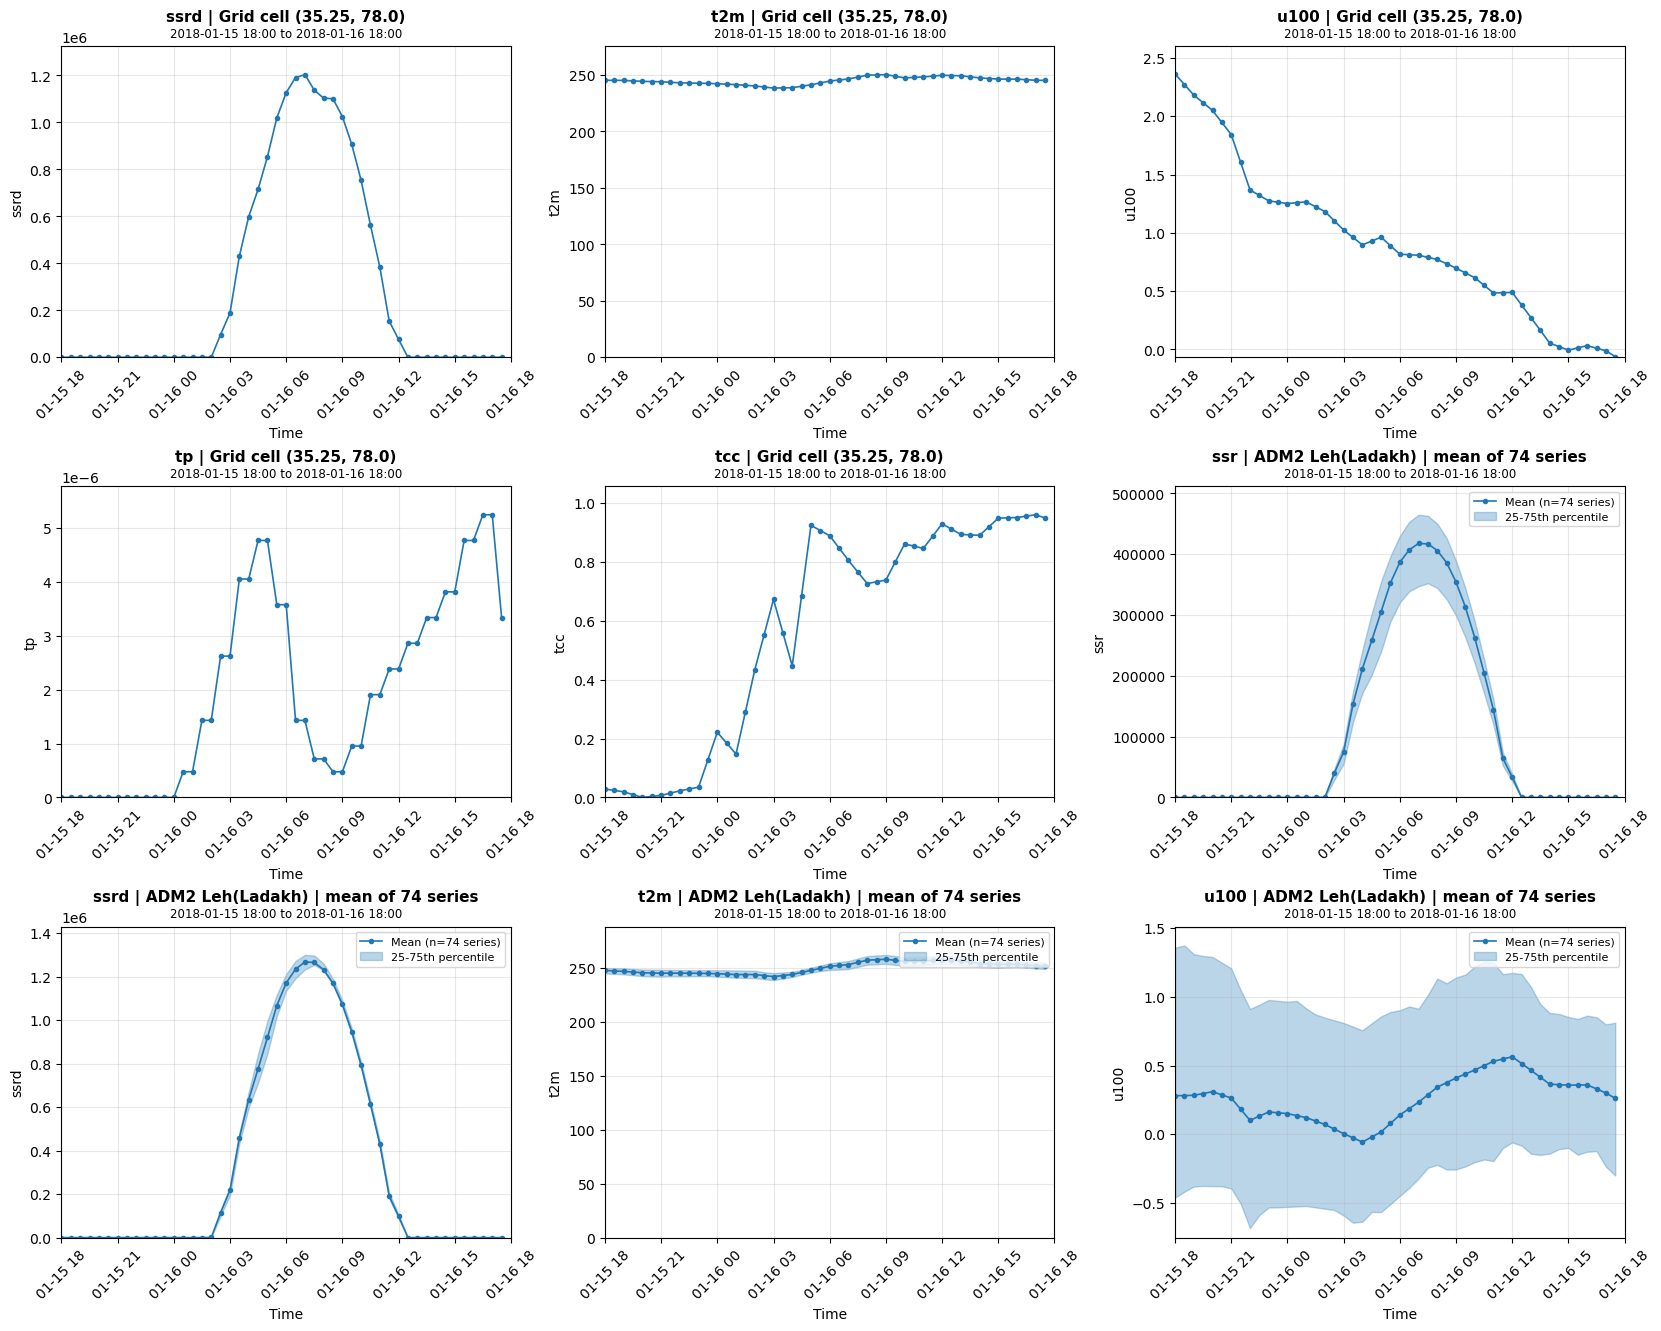

In [25]:
fig, axes, extracted = plot_polars_time_series_grid(df=step4_interpolated_data_2018_pldf, plot_specs=plot_specs_2018)

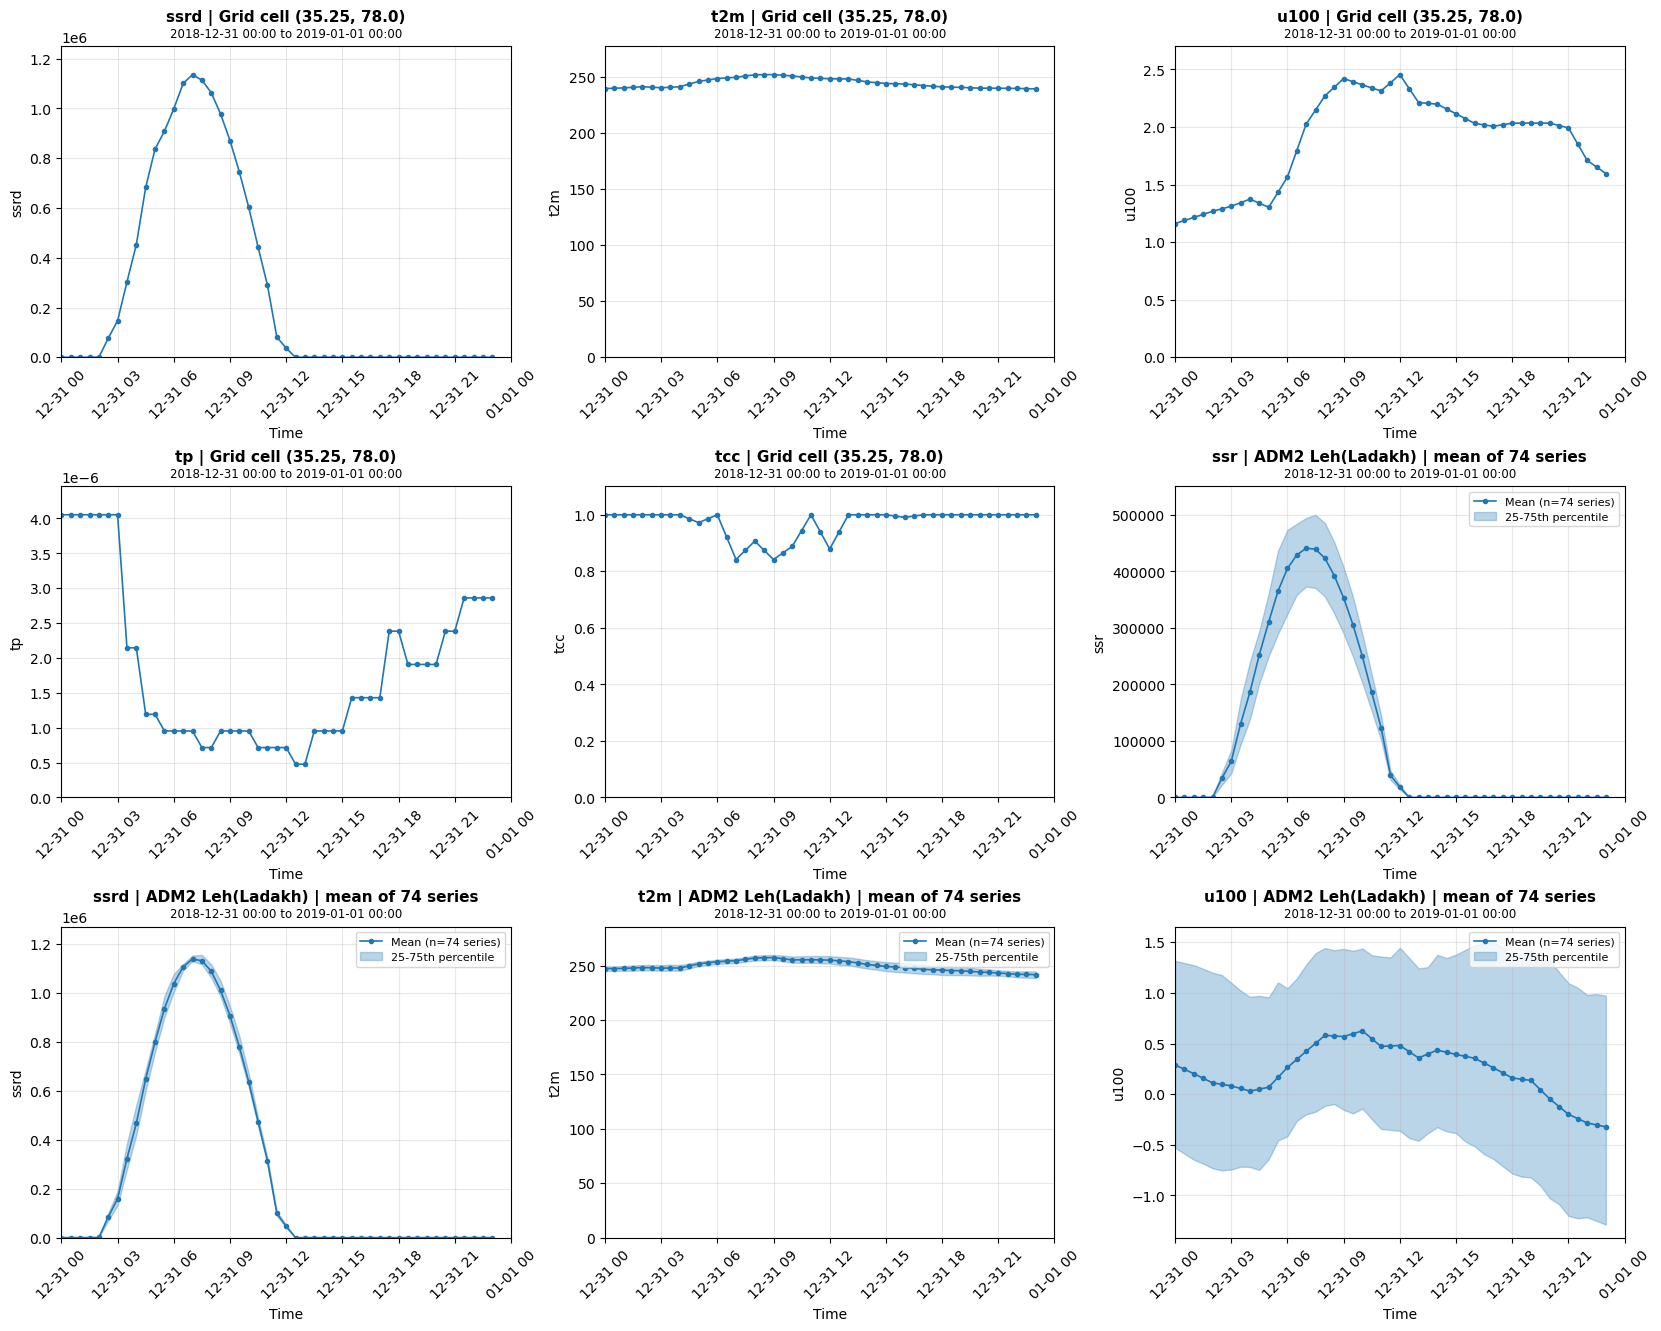

In [26]:
fig, axes, extracted = plot_polars_time_series_grid(df=step4_interpolated_data_2018_pldf, plot_specs=eo_plot_specs_2018)

In [27]:
step4_interpolated_data_2019_pldf = pl.read_parquet(source=step4_interpolated_data_2019_path)

In [28]:
print('Step 4 Interpolated Data 2018 — First 8 rows:')
display(step4_interpolated_data_2019_pldf.head(8))
print('Step 4 Interpolated Data 2018 — Last 8 rows:')
display(step4_interpolated_data_2019_pldf.tail(8))

Step 4 Interpolated Data 2018 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.0,3.926323,2.009766,2.217529,8.25,0.006683,77.25,0.0,1.8000e-12,0.0,0.0,0.0,-129453.328125,-141323.5625,659452.5625,658091.25,297.763855,0.006683,2019-01-01 00:00:00,0.0,0.0,0.0,-536230.25,-539044.75,-3.098755,-4.340668,0.0,-1.828659,-3.378967
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.0,3.175156,2.009766,2.21759,8.25,0.004059,77.25,0.0,9.0000e-13,0.0,0.0,0.0,-121109.09375,-142527.46875,667021.0625,655604.3125,297.775269,0.004059,2019-01-01 00:30:00,0.0,0.0,0.0,-534438.875,-538963.5,-3.016296,-4.25914,0.0,-1.924324,-3.545372
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.0,2.423988,2.009766,2.217651,8.25,0.001434,77.25,0.0,2.7000e-12,0.0,0.0,0.0,-123146.648438,-143583.765625,664789.4375,653899.8125,297.786713,0.001434,2019-01-01 01:00:00,0.0,0.0,0.0,-534913.125,-539164.5625,-2.933838,-4.177612,0.0,-2.019989,-3.711777
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",37154.75,0.611776,0.388224,37498.589844,1.0,0.0,1.827965,2.009827,2.217651,8.25,0.000717,77.25,0.0,56427.347656,50900.75,65679.164062,65048.296875,-134787.84375,-143930.84375,650937.25,652094.0,297.975098,0.000717,2019-01-01 01:30:00,0.0,111121.804688,105197.804688,-537206.0625,-539409.375,-2.97789,-4.156593,7096.179688,-2.09819,-3.747108
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",81373.25,0.611776,0.388224,81477.414062,1.0,0.0,1.231941,2.009888,2.217651,8.25,0.0,77.25,0.0,117588.664062,108715.25,136240.84375,135463.703125,-143397.46875,-146677.671875,648435.1875,651403.75,298.163452,0.0,2019-01-01 02:00:00,0.0,219630.203125,210962.1875,-539503.0,-540283.625,-3.021942,-4.135574,14575.819336,-2.176392,-3.78244
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",270463.375,0.611776,0.388224,260697.609375,1.0,0.0,0.93581,2.009888,2.217712,8.25,0.0,77.25,0.0,326477.03125,331423.40625,372717.75,377102.9375,-151529.96875,-151638.171875,654209.1875,651407.125,298.607117,0.0,2019-01-01 02:30:00,0.0,513937.6875,519125.8125,-542362.0625,-541725.75,-3.169548,-4.147217,38194.03125,-2.365631,-3.702255
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",426240.59375,0.611776,0.388224,414054.375,1.0,0.0,0.639679,2.009888,2.217773,8.25,0.0,77.25,0.0,497074.9375,507744.5625,564690.25,569201.125,-161670.046875,-156697.8125,657413.0,652568.0,299.050751,0.0,2019-01-01 03:00:00,0.0,748270.3125,759210.25,-545381.0,-543402.25,-3.317154,-4.158859,58397.96875,-2.554871,-3.62207
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",630219.25,0.611776,0.388224,631882.1875,1.0,0.0,0.348885,2.009949,2.217773,8.25,0.0,77.25,0.0,704742.3125,712826.3125,794093.8125,787206.75,-174975.953125,-163029.375,660241.3125,655124.9375,299.595154,0.0,2019-01-01 03:30:00,0.0,997888.5,1.0059e6,-549036.4375,-545612.1875,-3.300034,-4.118179,84430.546875,-2.62487,-3.663116


Step 4 Interpolated Data 2018 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-20.871525,0.0,0.507324,35.25,1.0,78.0,0.915161,1.8000e-12,0.0,0.0,0.0,-53938.484375,-137103.03125,276952.84375,179416.1875,247.255737,1.0,2019-12-31 19:30:00,0.000017,0.0,0.0,-296017.875,-293809.8125,0.10865,0.590126,0.0,1.153381,2.816704
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-21.266663,0.0,0.507324,35.25,1.0,78.0,0.915497,1.8000e-12,0.0,0.0,0.0,-53497.511719,-134056.96875,275535.375,178932.109375,246.809204,1.0,2019-12-31 20:00:00,0.000017,0.0,0.0,-295972.15625,-291853.21875,0.113266,0.625702,0.0,1.203003,2.90567
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-21.523586,0.0,0.507324,35.25,1.0,78.0,0.948441,1.8000e-12,0.0,0.0,0.0,-43044.148438,-130592.0,286752.65625,178272.8125,246.510773,1.0,2019-12-31 20:30:00,0.000014,0.0,0.0,-293445.65625,-289583.65625,0.110542,0.650726,0.0,1.260254,2.994614
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-21.78051,0.0,0.507324,35.25,1.0,78.0,0.981384,1.8000e-12,0.0,0.0,0.0,-42090.039062,-129743.0,286795.0,177813.328125,246.212357,1.0,2019-12-31 21:00:00,0.000014,0.0,0.0,-292916.34375,-288864.34375,0.107819,0.675751,0.0,1.317505,3.083557
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.163815,0.0,0.507324,35.25,1.0,78.0,0.948792,1.8000e-12,0.0,0.0,0.0,-47864.460938,-132315.109375,279141.0625,177564.265625,245.678146,1.0,2019-12-31 21:30:00,0.000012,0.0,0.0,-293828.375,-290187.53125,0.154305,0.82206,0.0,1.356194,3.14254
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.547119,0.0,0.507324,35.25,1.0,78.0,0.916199,1.8000e-12,0.0,0.0,0.0,-51128.167969,-131956.640625,273680.03125,177105.984375,245.143936,1.0,2019-12-31 22:00:00,0.000012,0.0,0.0,-293914.59375,-289699.46875,0.20079,0.968369,0.0,1.394882,3.201523
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.967968,0.0,0.507324,35.25,1.0,78.0,0.711304,1.8000e-12,0.0,0.0,0.0,-54785.285156,-129168.914062,266368.40625,176351.359375,244.713531,1.0,2019-12-31 22:30:00,0.000012,0.0,0.0,-293568.71875,-287609.96875,0.143471,0.993813,0.0,1.420074,3.283943
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-23.388817,0.0,0.507324,35.25,1.0,78.0,0.506409,1.8000e-12,0.0,0.0,0.0,-56345.09375,-128327.53125,263534.21875,176070.765625,244.283142,1.0,2019-12-31 23:00:00,0.000012,0.0,0.0,-293482.25,-286945.03125,0.086151,1.019257,0.0,1.445267,3.366364


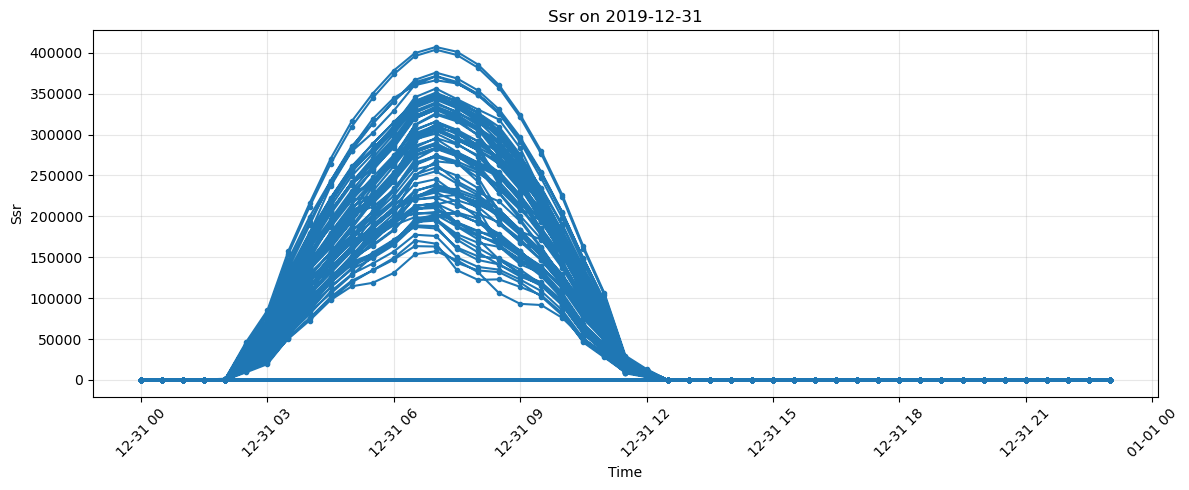

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-27.812408,0.0,0.5078125,32.5,0.028137,79.0,0.857513,1.8000e-12,0.0,0.0,0.0,-54847.039062,-74247.8125,229941.671875,209136.640625,250.24646,0.866058,2019-12-31 00:00:00,7.1526e-7,0.0,0.0,-282545.03125,-284630.3125,-0.886353,-0.985565,0.0,0.973969,4.161301
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-27.394005,0.0,0.5078125,32.5,0.014694,79.0,0.811874,9.0000e-13,0.0,0.0,0.0,-59946.792969,-75744.960938,223080.515625,209030.21875,250.139069,0.816147,2019-12-31 00:30:00,7.1526e-7,0.0,0.0,-282446.28125,-285361.5,-0.91259,-1.121712,0.0,1.005783,4.203522
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-26.975601,0.0,0.5078125,32.5,0.001251,79.0,0.766235,2.7000e-12,0.0,0.0,0.0,-60399.015625,-75750.476562,221690.84375,208788.59375,250.031693,0.766235,2019-12-31 01:00:00,7.1526e-7,0.0,0.0,-282502.71875,-285275.5,-0.938828,-1.257858,0.0,1.037598,4.245743
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",485.91983,0.0,0.756005,306.771606,1.0,0.0,-26.486149,0.0,0.5078125,32.5,0.021027,79.0,0.699249,443.902039,460.747986,1496.376709,1562.14209,-55106.125,-74126.351562,225503.171875,208361.921875,250.012817,0.704163,2019-12-31 01:30:00,4.7684e-7,1640.3125,1674.766357,-282522.34375,-284313.0625,-0.958374,-1.32988,190.461075,1.067169,4.286354
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1434.0802,0.0,0.756005,909.228394,1.0,0.0,-25.996696,0.0,0.5078125,32.5,0.040802,79.0,0.632263,1284.0979,1331.252075,4327.623535,4517.85791,-58109.75,-74087.710938,223802.8125,208070.828125,249.993958,0.64209,2019-12-31 02:00:00,4.7684e-7,4631.6875,4725.233887,-283519.65625,-284125.9375,-0.977921,-1.401901,545.53894,1.096741,4.326965
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-21.78051,0.0,0.507324,35.25,1.0,78.0,0.981384,1.8000e-12,0.0,0.0,0.0,-42090.039062,-129743.0,286795.0,177813.328125,246.212357,1.0,2019-12-31 21:00:00,0.000014,0.0,0.0,-292916.34375,-288864.34375,0.107819,0.675751,0.0,1.317505,3.083557
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.163815,0.0,0.507324,35.25,1.0,78.0,0.948792,1.8000e-12,0.0,0.0,0.0,-47864.460938,-132315.109375,279141.0625,177564.265625,245.678146,1.0,2019-12-31 21:30:00,0.000012,0.0,0.0,-293828.375,-290187.53125,0.154305,0.82206,0.0,1.356194,3.14254
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.547119,0.0,0.507324,35.25,1.0,78.0,0.916199,1.8000e-12,0.0,0.0,0.0,-51128.167969,-131956.640625,273680.03125,177105.984375,245.143936,1.0,2019-12-31 22:00:00,0.000012,0.0,0.0,-293914.59375,-289699.46875,0.20079,0.968369,0.0,1.394882,3.201523


In [29]:
plot_day_polars_direct(step4_interpolated_data_2019_pldf.filter(pl.col("adm2_code") == "76128533B57183548666997"), date='2019-12-31', column='ssr')

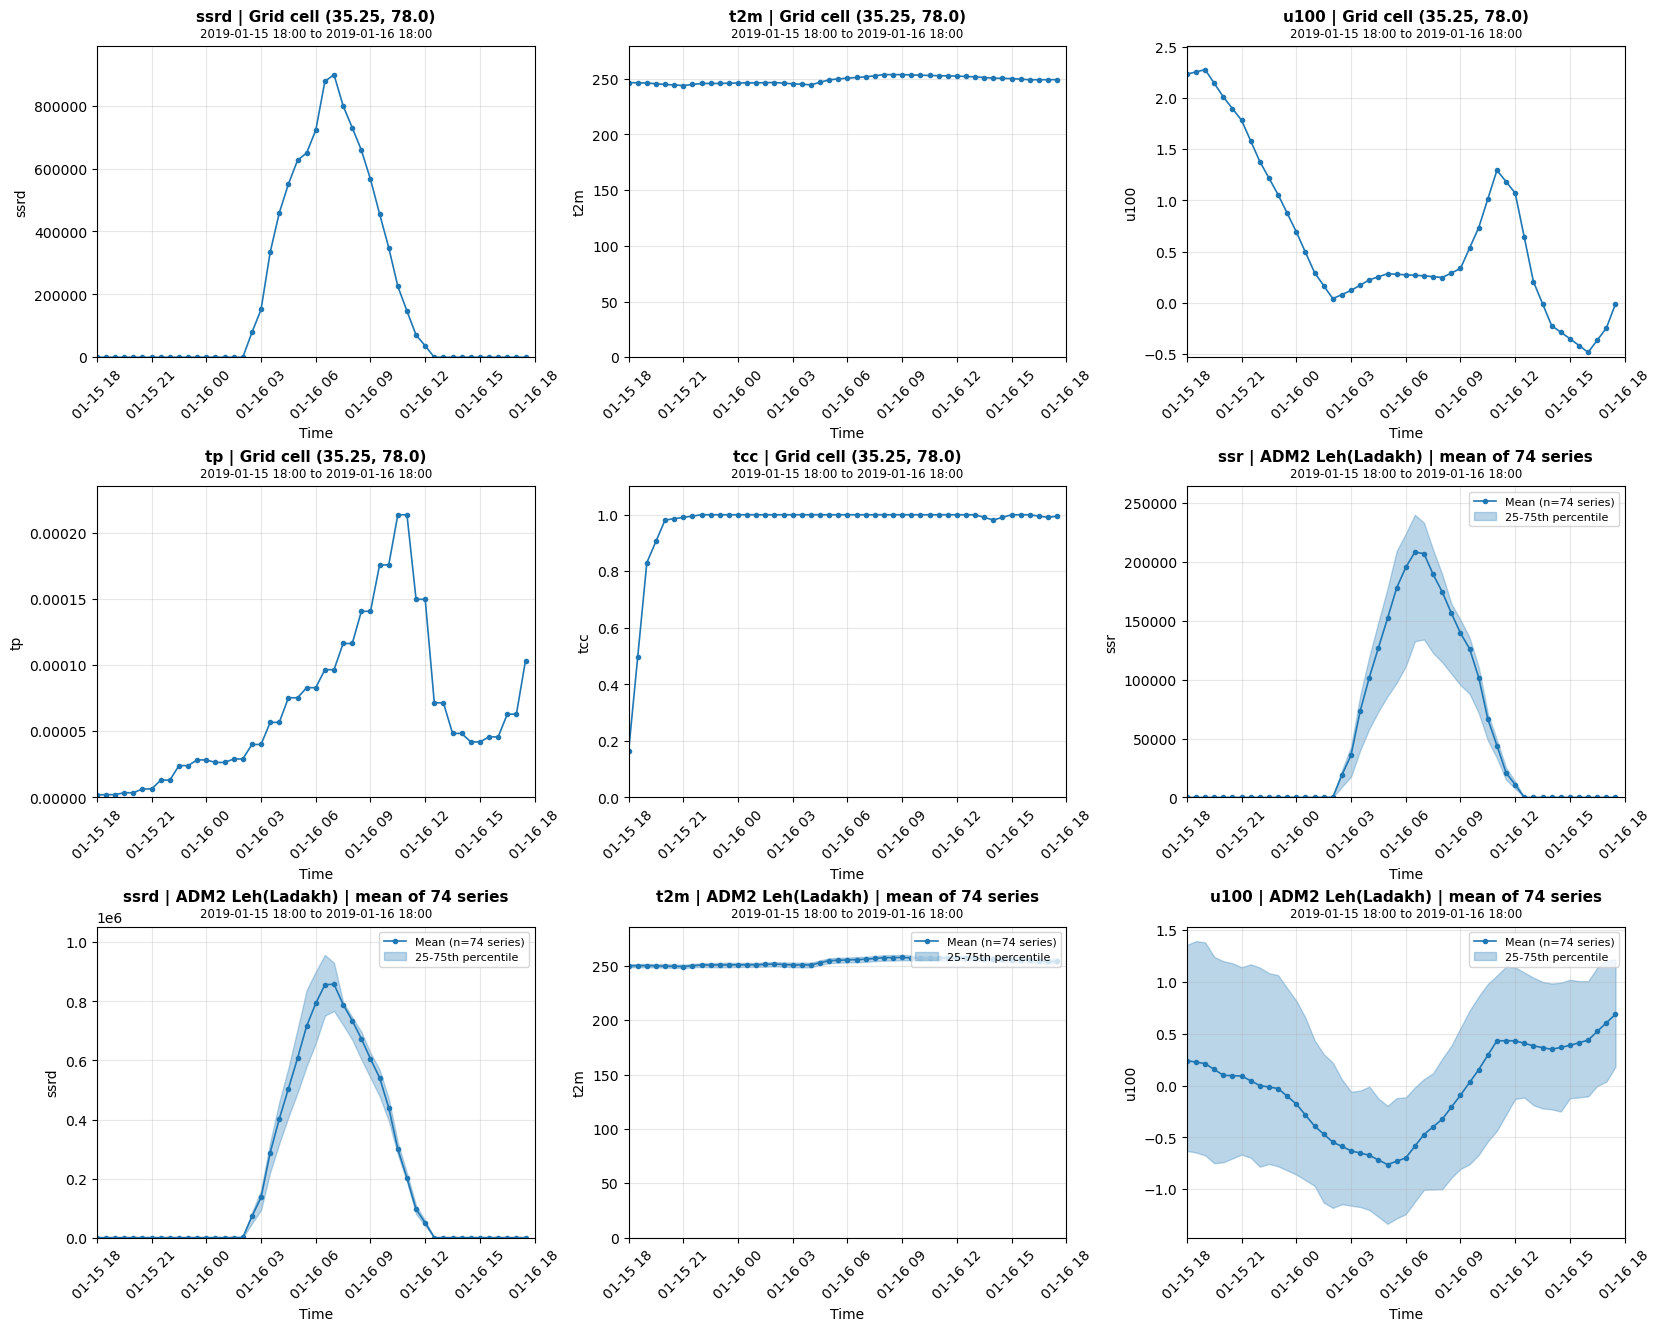

In [30]:
fig, axes, extracted = plot_polars_time_series_grid(df=step4_interpolated_data_2019_pldf, plot_specs=plot_specs_2019)

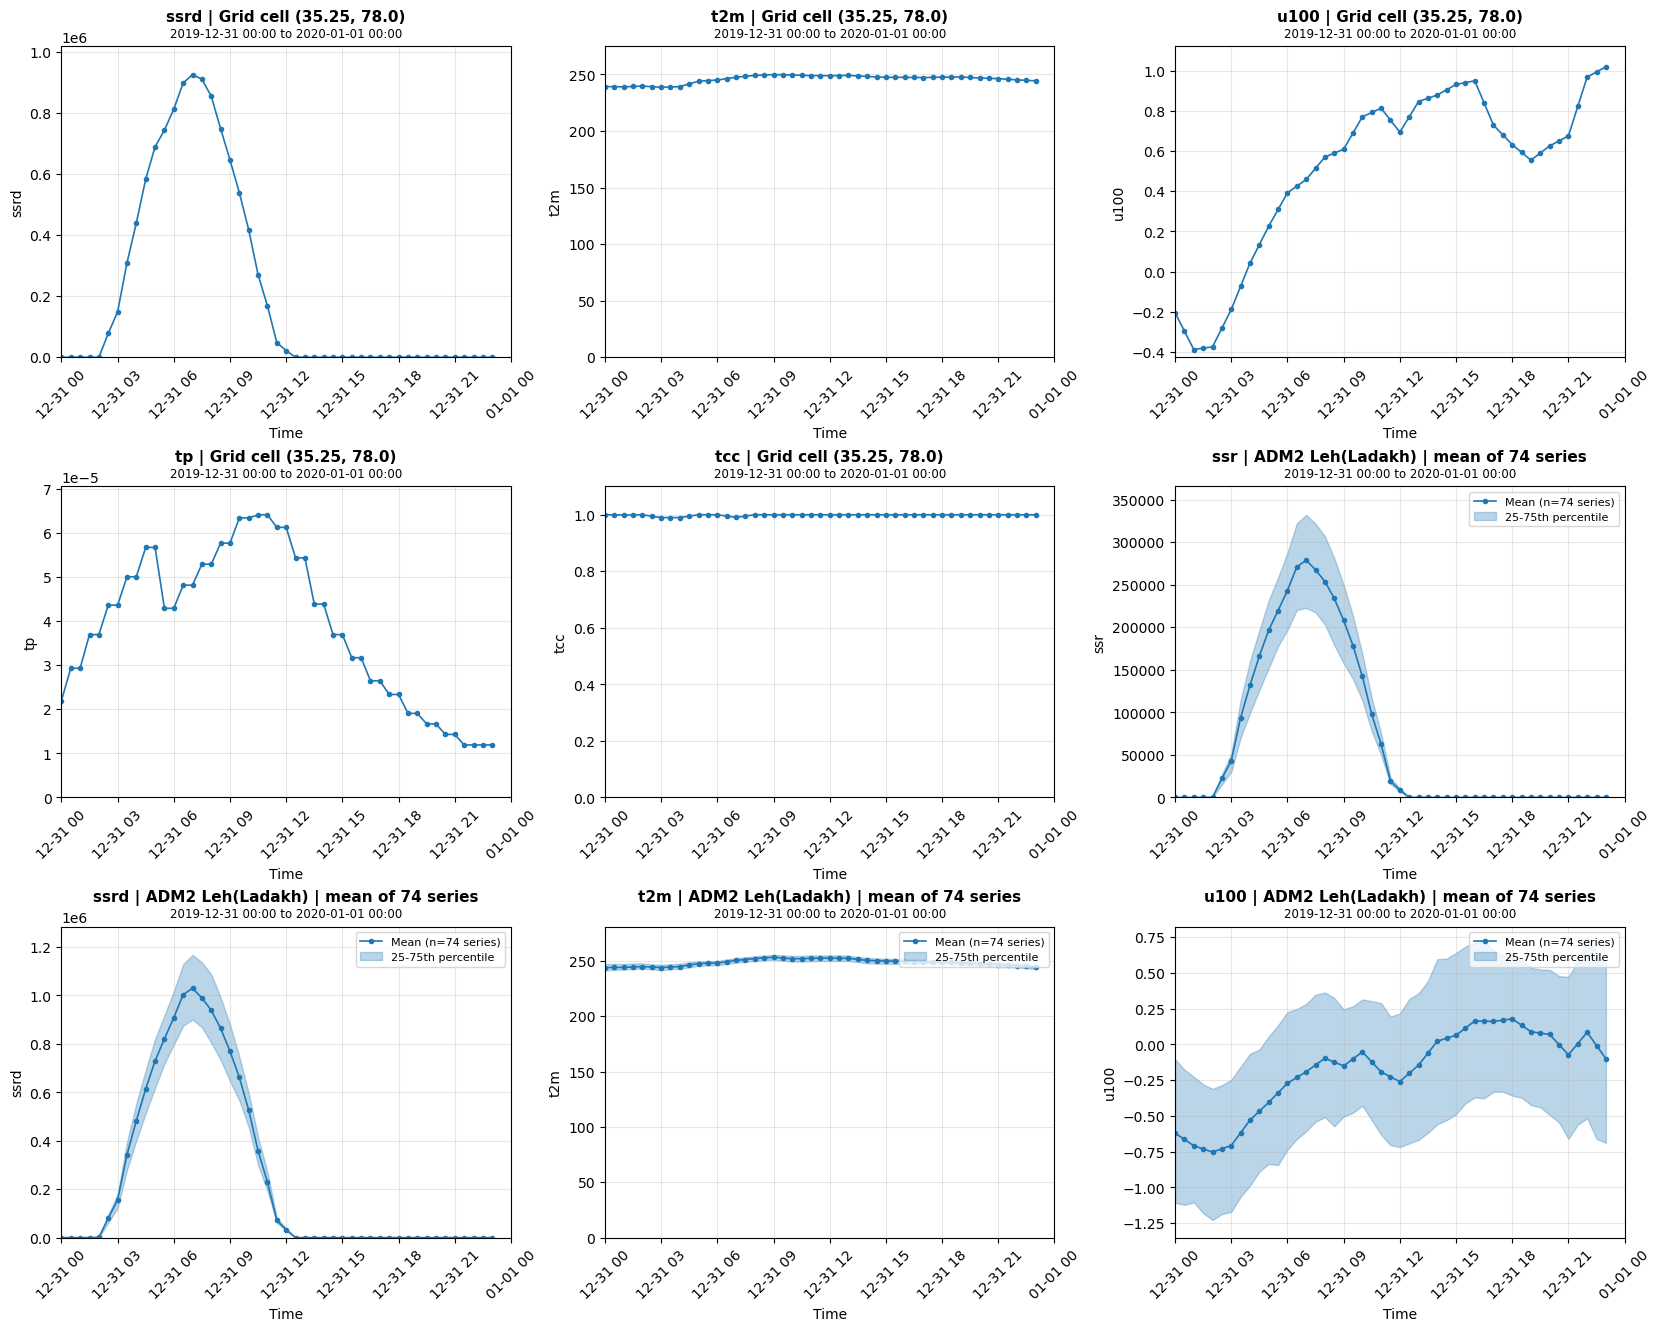

In [31]:
fig, axes, extracted = plot_polars_time_series_grid(df=step4_interpolated_data_2019_pldf, plot_specs=eo_plot_specs_2019)

##### Step 5 Data: 

In [32]:
step5_interpolated_boundary_fixed_data_2018_pldf = pl.read_parquet(source=step5_interpolated_boundary_fixed_data_2018_path)

In [33]:
# Describe
print('Step 5 Interpolated Boundary Fixed Data 2018 Description')
display(step5_interpolated_boundary_fixed_data_2018_pldf.describe())

Step 5 Interpolated Boundary Fixed Data 2018 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""77823840""","""77823840""","""77823840""","""77823840""","""77823840""","""77823840""",7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,"""77823840""",7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,372091.875,0.279998,0.663284,268641.21875,1.0,0.339123,15.01128,1.794127,1.656656,22.886875,0.145376,79.613518,0.196462,309858.1875,380475.28125,384867.625,470369.46875,-127371.835938,-145357.078125,670853.875,651931.1875,297.215393,0.446709,"""2018-07-02 11:45:00""",0.000067,490147.09375,561632.625,-467708.65625,-510055.53125,0.530051,0.814341,43896.234375,0.055113,0.051284
"""std""",null,null,null,null,null,null,496889.125,0.31615,0.325826,412490.4375,0.0,0.413964,22.095919,1.230856,0.750643,5.504276,0.268535,5.880583,0.274953,428676.6875,495816.96875,526308.9375,604391.0,79763.867188,68066.460938,109703.382812,109617.445312,9.873069,0.411805,null,0.000289,627006.9375,705073.375,86644.273438,41792.515625,2.255062,3.613466,60772.910156,1.608761,2.578426
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-117.629463,0.0,0.0,8.25,0.0,68.25,0.0,9.0000e-13,0.0,0.0,0.0,-9.6494144e7,-661168.375,149618.6875,149703.953125,226.659988,0.0,"""2018-01-01 00:00:00""",0.0,0.0,0.0,-721858.4375,-724650.1875,-14.483887,-19.481308,0.0,-18.665878,-20.938965
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,2.100697,0.981934,1.084717,19.5,0.0,75.5,0.0,1.8000e-12,0.0,0.0,0.0,-164232.21875,-175909.3125,605255.4375,594861.1875,293.936768,0.010818,"""2018-04-02 06:00:00""",0.0,0.0,0.0,-527433.75,-534732.375,-1.009964,-1.580956,0.0,-0.999878,-1.547997
"""50%""",null,null,null,null,null,null,5473.385254,0.149811,0.755631,861.55127,1.0,0.045227,23.122555,1.973877,1.619019,23.5,0.0,78.25,0.060883,11787.571289,15394.000977,15072.543945,20933.759766,-116135.976562,-129448.03125,689558.75,672905.75,299.03833,0.335999,"""2018-07-02 12:00:00""",0.0,35812.320312,41408.015625,-495751.96875,-509873.09375,0.317116,0.510239,1899.929932,-0.017548,-0.034409
"""75%""",null,null,null,null,null,null,797344.625,0.504298,0.976124,457876.53125,1.0,0.837326,32.26231,2.349365,2.261597,26.75,0.149811,82.5,0.291443,592645.4375,810368.4375,751884.1875,1.0161e6,-71236.476562,-97354.570312,757689.3125,731065.8125,302.88208,0.941223,"""2018-10-01 17:30:00""",0.000006,1006678.5,1.1964e6,-420653.125,-486953.59375,1.947708,3.25177,84104.835938,0.999451,1.547821
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",1.8378e6,1.0,1.0,1.9950e6,1.0,1.0,46.955696,6.530518,3.891846,35.25,1.0,97.25,1.0,1.7732e6,1.812096e6,2.19841e6,2.1419e6,9.6503064e7,-32247.685547,938047.375,937519.5,322.637939,1.0,"""2018-12-31 23:30:00""",0.027919,2.2742e6,2243491.5,-117882.671875,-248044.53125,12.241653,16.166748,278455.46875,15.475861,19.226913


In [34]:
print('Step 5 Interpolated Boundary Fixed Data 2018 — First 8 rows:')
display(step5_interpolated_boundary_fixed_data_2018_pldf.head(8))
print('Step 5 Interpolated Boundary Fixed Data 2018 — Last 8 rows:')
display(step5_interpolated_boundary_fixed_data_2018_pldf.tail(8))

Step 5 Interpolated Boundary Fixed Data 2018 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.679626,23.215073,2.009766,2.217529,8.25,0.025208,77.25,0.00946,1.8000e-12,0.0,0.0,0.0,-103075.914062,-114321.546875,682848.75,684819.125,296.919067,0.685303,2018-01-01 00:00:00,0.0,0.0,0.0,-509683.21875,-515147.8125,-0.143936,-0.339081,0.0,-1.499603,-1.808823
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.462158,22.438404,2.009766,2.21759,8.25,0.041428,77.25,0.021362,9.0000e-13,0.0,0.0,0.0,-101169.679688,-114271.460938,682860.8125,683819.0,296.855988,0.486664,2018-01-01 00:30:00,0.0,0.0,0.0,-510147.8125,-514594.46875,-0.148972,-0.316956,0.0,-1.54351,-1.792931
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.24469,21.661736,2.009766,2.217651,8.25,0.057648,77.25,0.033264,2.7000e-12,0.0,0.0,0.0,-102304.382812,-114291.96875,681977.375,683064.8125,296.792908,0.288025,2018-01-01 01:00:00,0.0,0.0,0.0,-510727.15625,-514376.53125,-0.154007,-0.29483,0.0,-1.587418,-1.777039
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",35116.691406,0.611776,0.388224,35387.386719,1.0,0.296631,21.0975,2.009827,2.217651,8.25,0.0336,77.25,0.020416,54545.515625,49042.128906,63345.363281,62709.472656,-104842.679688,-112994.53125,678783.4375,681865.75,297.284882,0.3228,2018-01-01 01:30:00,0.0,110319.257812,105197.804688,-511171.3125,-514074.3125,-0.218918,-0.366295,6914.79248,-1.493935,-1.719696
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",77139.304688,0.611776,0.388224,77316.617188,1.0,0.348572,20.533264,2.009888,2.217651,8.25,0.009552,77.25,0.007568,113710.476562,104941.867188,131534.625,130826.523438,-110942.453125,-115824.09375,679976.4375,682133.0,297.776855,0.357574,2018-01-01 02:00:00,0.0,218256.734375,210962.1875,-512615.65625,-514666.6875,-0.283829,-0.437759,14213.208008,-1.400452,-1.662354
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",259271.53125,0.611776,0.388224,253880.484375,1.0,0.286743,20.340279,2.009888,2.217712,8.25,0.035721,77.25,0.022079,316483.78125,322087.40625,361637.53125,366417.09375,-121966.125,-123112.203125,685045.6875,683374.6875,298.161194,0.312195,2018-01-01 02:30:00,0.0,512892.375,519120.75,-515157.9375,-516181.96875,-0.300034,-0.402771,37213.625,-1.182655,-1.424461
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",409592.46875,0.611776,0.388224,401415.5,1.0,0.224915,20.147293,2.009888,2.217773,8.25,0.06189,77.25,0.036591,481084.21875,494104.59375,546970.5,553838.9375,-131754.875,-128648.78125,689374.375,685650.1875,298.545532,0.266815,2018-01-01 03:00:00,0.0,745859.625,759215.1875,-517288.09375,-517534.0625,-0.316238,-0.367783,57226.375,-0.964859,-1.186569
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",607773.9375,0.611776,0.388224,600141.1875,1.0,0.271591,20.151382,2.009949,2.217773,8.25,0.052383,77.25,0.027573,677341.125,694851.5,763186.5,767314.1875,-142384.125,-134072.09375,694408.9375,689434.1875,298.897827,0.300873,2018-01-01 03:30:00,0.0,989000.8125,1005866.5,-519321.1875,-519081.34375,-0.21563,-0.261841,84299.296875,-0.85746,-

Step 5 Interpolated Boundary Fixed Data 2018 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-35.663307,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-82822.367188,-95016.242188,202769.578125,186703.875,239.976242,1.0,2018-12-31 20:00:00,0.000002,0.0,0.0,-285102.625,-279475.84375,0.115356,2.032974,0.0,1.293716,3.246399
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-35.239201,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-87872.0,-95533.242188,194252.3125,186698.328125,239.956177,1.0,2018-12-31 20:30:00,0.000002,0.0,0.0,-280749.625,-278969.25,0.115654,2.012619,0.0,1.274635,3.293961
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-34.815094,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-85929.992188,-93499.765625,193998.015625,187114.53125,239.936111,1.0,2018-12-31 21:00:00,0.000002,0.0,0.0,-279044.375,-277477.78125,0.115952,1.992264,0.0,1.255554,3.341522
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-33.501263,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-78269.523438,-88872.398438,200577.484375,188131.109375,239.85376,1.0,2018-12-31 21:30:00,0.000003,0.0,0.0,-279291.5625,-274774.71875,-0.015335,1.851021,0.0,1.247879,3.305145
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-32.187431,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-73830.476562,-86914.601562,204032.875,188835.03125,239.771393,1.0,2018-12-31 22:00:00,0.000003,0.0,0.0,-279076.4375,-273699.28125,-0.146622,1.709778,0.0,1.240204,3.268768
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-30.965366,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-69795.085938,-86732.453125,207198.25,189565.84375,239.543671,1.0,2018-12-31 22:30:00,0.000003,0.0,0.0,-279054.5,-273948.6875,-0.112793,1.652725,0.0,1.292587,3.341362
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-29.743301,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-67891.757812,-85951.007812,208165.3125,190085.125,239.315948,1.0,2018-12-31 23:00:00,0.000003,0.0,0.0,-278508.9375,-273776.9375,-0.078964,1.595673,0.0,1.344971,3.413956
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-28.484661,0.0,0.507324,35.25,1.0,78.0,0.016144,1.8000e-12,0.0,0.0,0.0,-68735.40625,-86785.15625,208638.1875,189560.515625,239.670746,1.0,2018-12-31 23:30:00,0.000003,0.0,0.0,-279532.6875,-273907.78125,-0.145988,1.490784,0.0,1.286964,3.397865


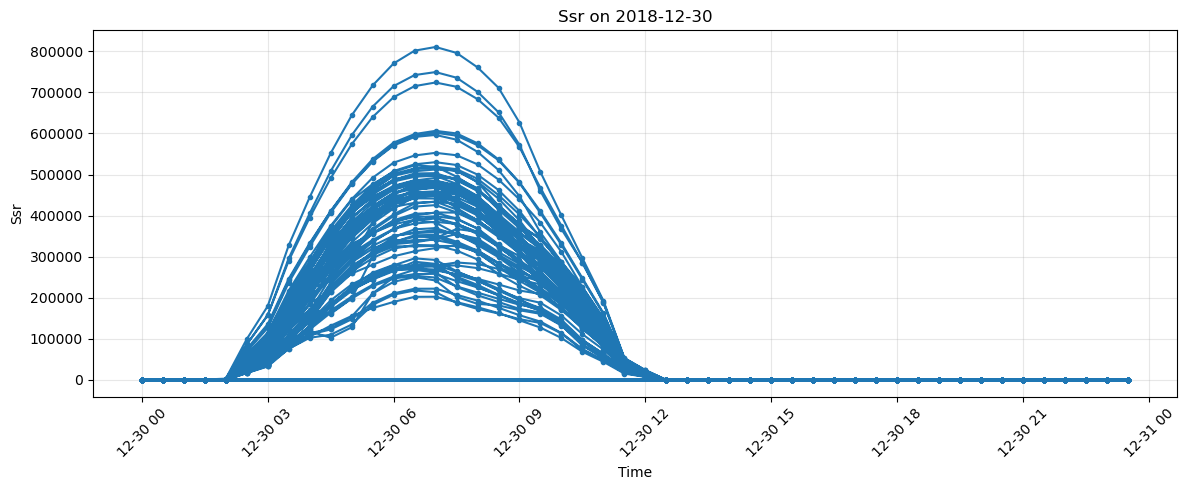

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-17.546402,0.0,0.5078125,32.5,0.0,79.0,0.003754,1.8000e-12,0.0,0.0,0.0,-71711.5625,-89209.835938,231269.796875,232524.75,252.457428,0.003754,2018-12-30 00:00:00,0.0,0.0,0.0,-299522.46875,-307755.4375,-0.957489,0.510681,0.0,0.257141,2.945953
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-17.49799,0.0,0.5078125,32.5,0.001251,79.0,0.003326,9.0000e-13,0.0,0.0,0.0,-69952.078125,-88610.5625,231990.125,232324.015625,252.520081,0.003326,2018-12-30 00:30:00,0.0,0.0,0.0,-299310.875,-307465.6875,-0.920998,0.533394,0.0,0.314903,3.080391
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-17.449577,0.0,0.5078125,32.5,0.002502,79.0,0.002899,2.7000e-12,0.0,0.0,0.0,-69259.859375,-87962.9375,231405.390625,232227.375,252.582733,0.002899,2018-12-30 01:00:00,0.0,0.0,0.0,-298543.125,-307190.34375,-0.884506,0.556107,0.0,0.372665,3.214828
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",502.305511,0.0,0.756005,486.007507,1.0,0.0,-16.996914,0.0,0.5078125,32.5,0.001877,79.0,0.002274,806.617615,889.621033,1612.871948,1579.613159,-67911.140625,-87321.601562,228730.34375,232182.9375,253.395828,0.002274,2018-12-30 01:30:00,0.0,2070.109863,2170.738281,-295819.15625,-306935.1875,-0.884598,0.456978,186.364166,0.426018,3.305687
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1481.694458,0.0,0.756005,1433.992432,1.0,0.0,-16.54425,0.0,0.5078125,32.5,0.001251,79.0,0.001648,2329.382568,2566.378906,4659.12793,4564.387207,-71224.046875,-86807.71875,229143.484375,232205.546875,254.208923,0.001648,2018-12-30 02:00:00,0.0,5865.890137,6149.262207,-297626.8125,-306764.84375,-0.884689,0.357849,533.635803,0.47937,3.396545
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-26.920086,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-55716.082031,-116724.445312,256626.625,193661.078125,240.859985,1.0,2018-12-30 21:30:00,0.000005,0.0,0.0,-307367.28125,-294829.21875,-0.243683,1.538696,0.0,0.721138,2.593903
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-27.602905,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-57807.914062,-115696.546875,252544.359375,192718.859375,239.978424,1.0,2018-12-30 22:00:00,0.000005,0.0,0.0,-305217.71875,-293735.8125,-0.263763,1.464676,0.0,0.679871,2.520645
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-28.042309,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-41382.839844,-109632.53125,270433.625,191836.078125,239.47818,1.0,2018-12-30 22:30:00,0.000004,0.0,0.0,-307817.78125,-289896.5,-0.260185,1.395943,0.0,0.786255,2.659996


In [35]:
plot_day_polars_direct(step5_interpolated_boundary_fixed_data_2018_pldf.filter(pl.col("adm2_code") == "76128533B57183548666997"), date='2018-12-30', column='ssr')

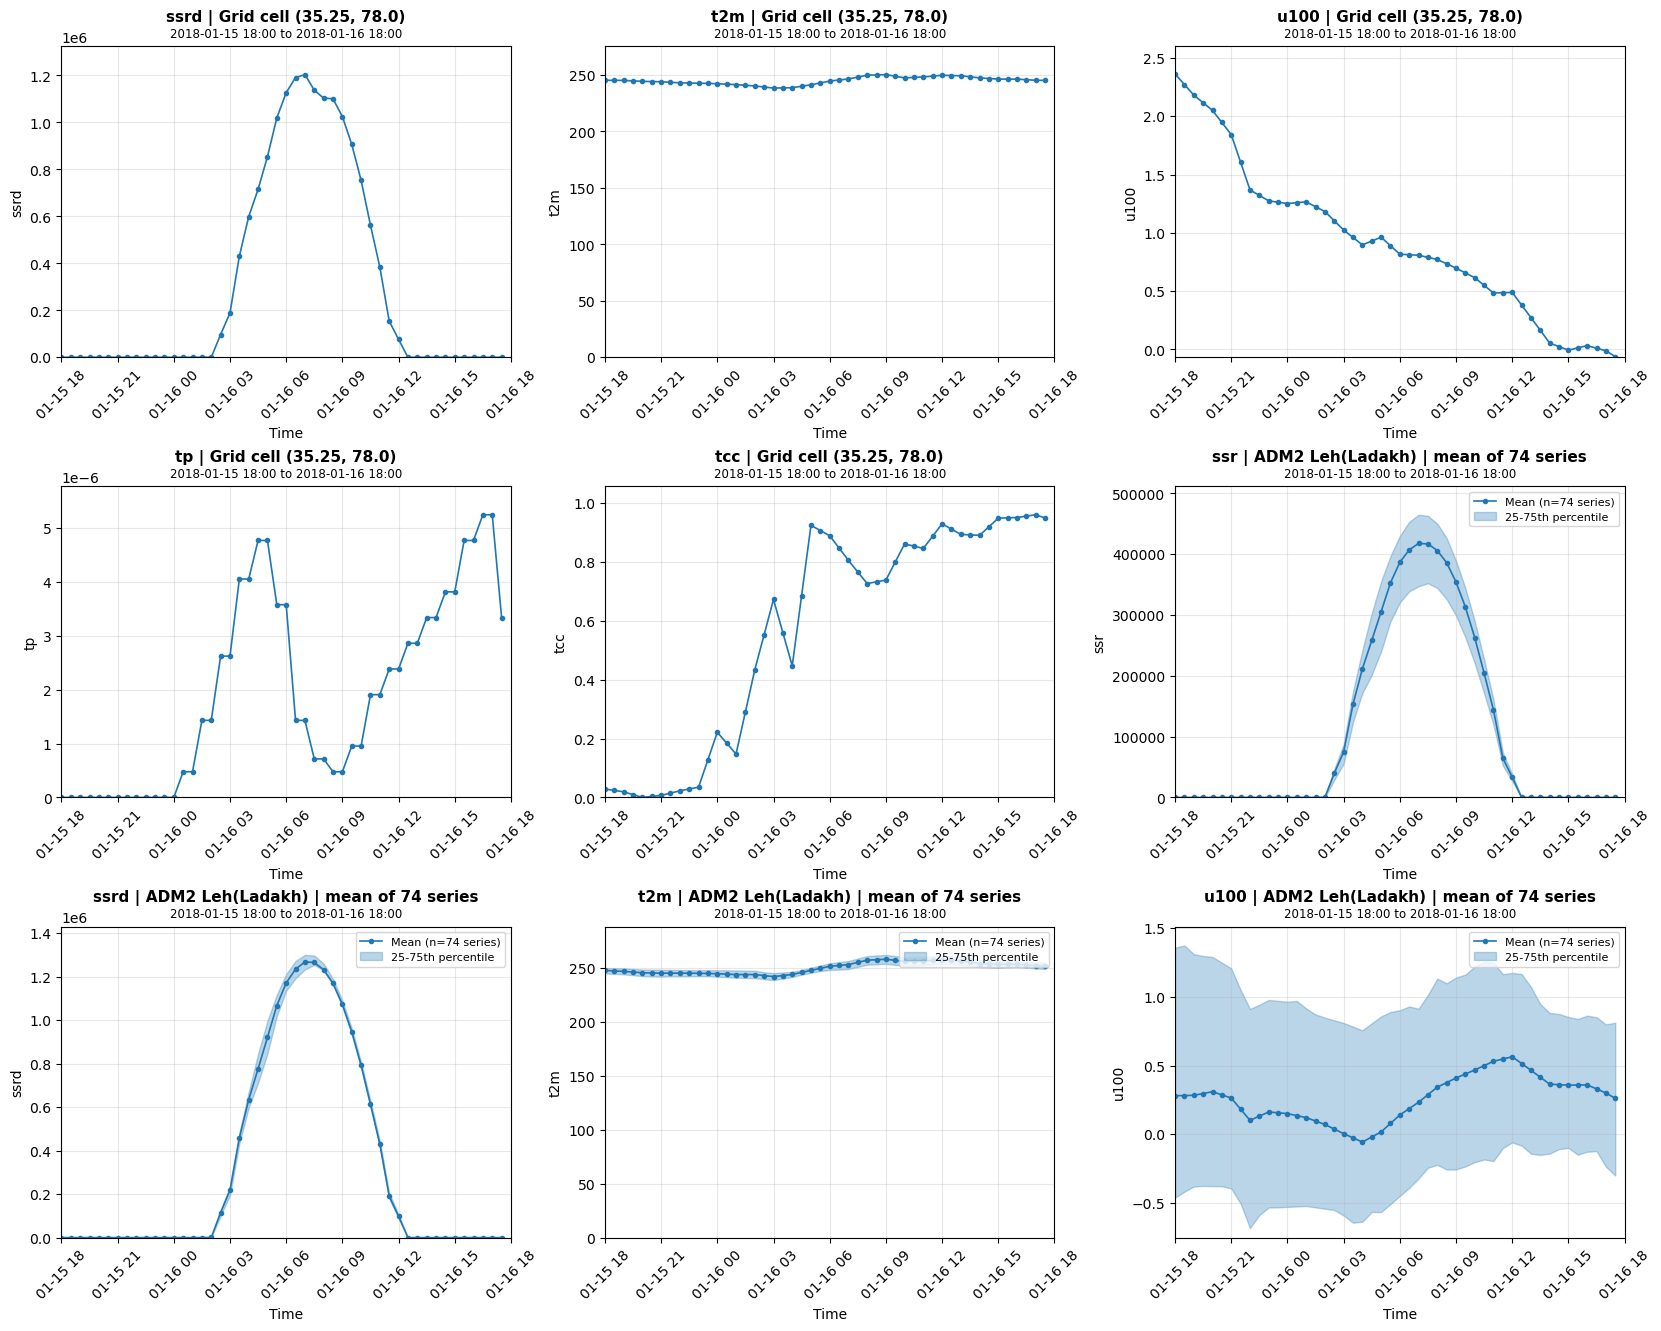

In [36]:
fig, axes, extracted = plot_polars_time_series_grid(df=step5_interpolated_boundary_fixed_data_2018_pldf, plot_specs=plot_specs_2018)

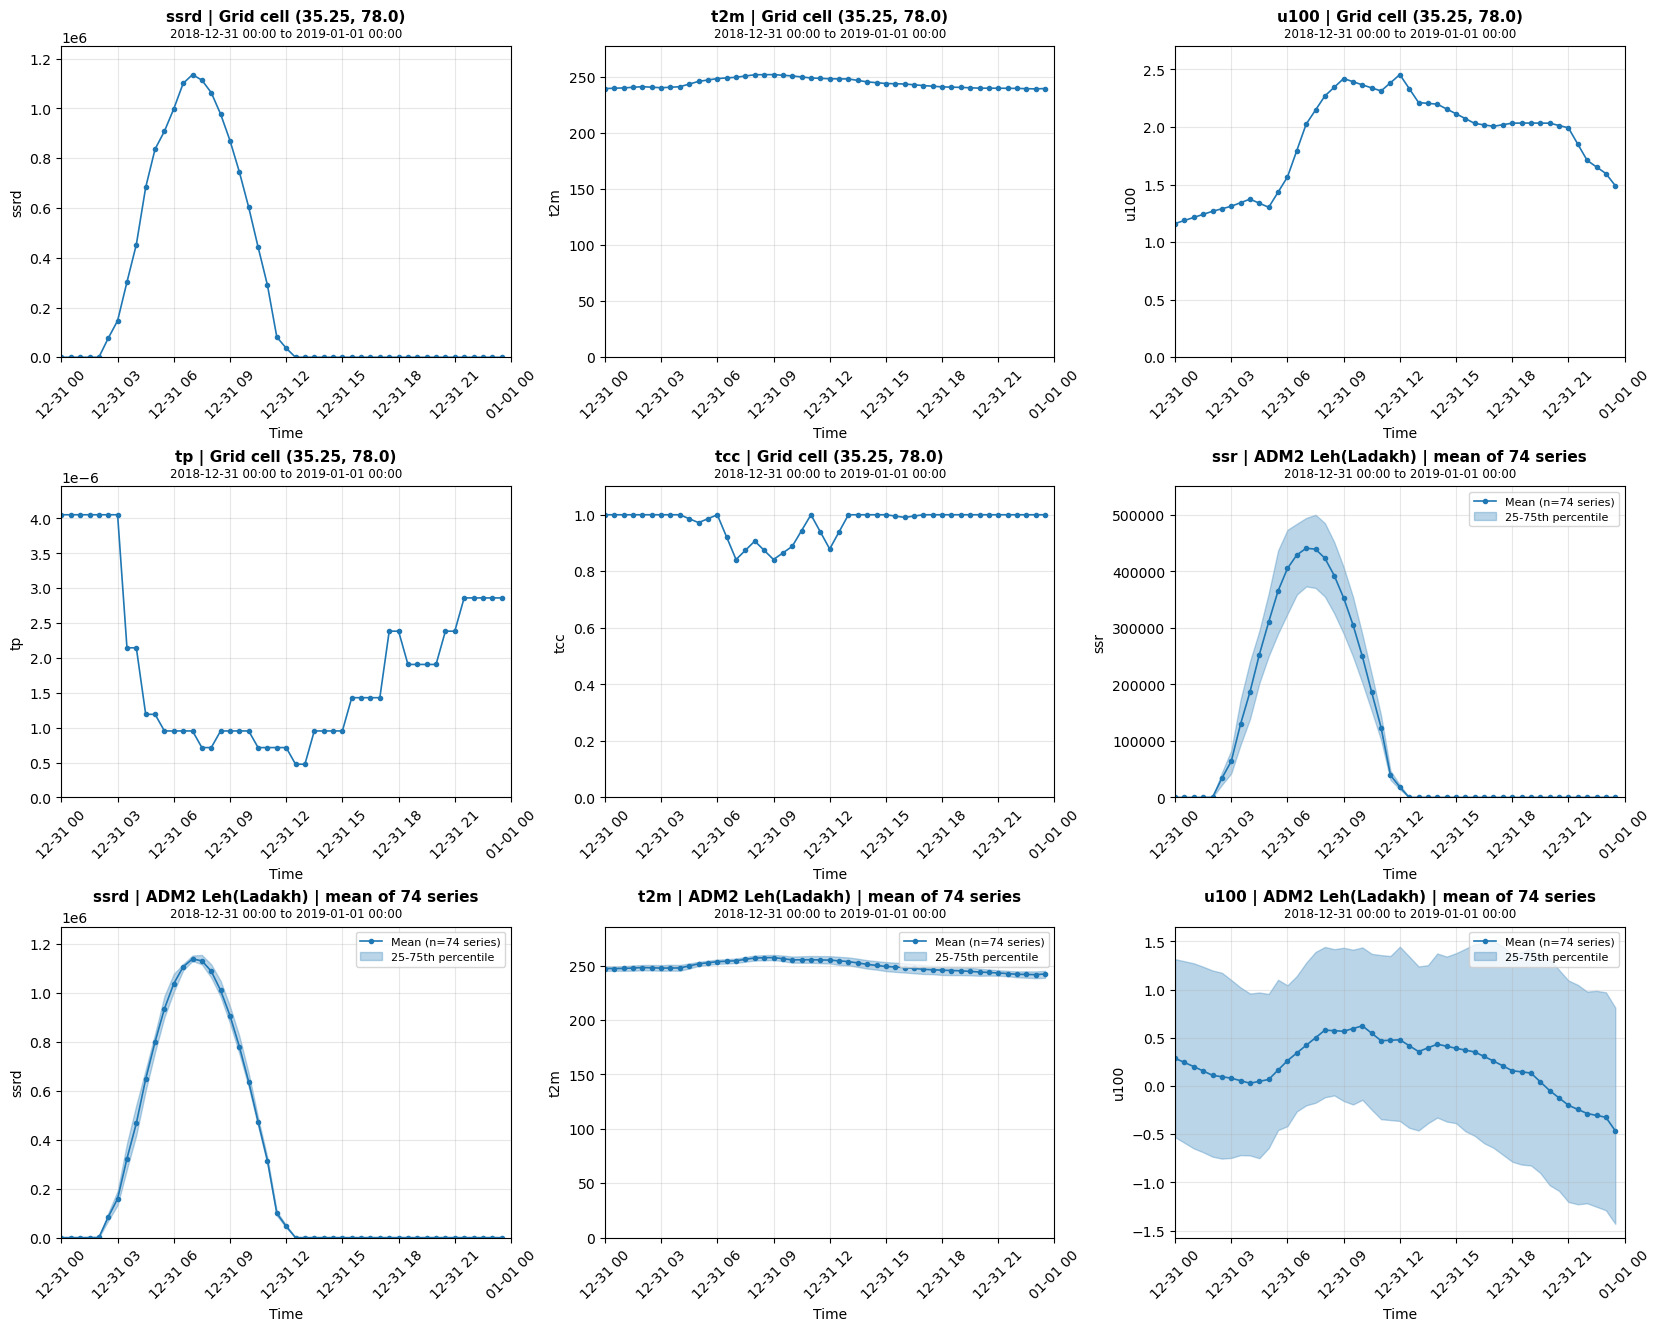

In [37]:
fig, axes, extracted = plot_polars_time_series_grid(df=step5_interpolated_boundary_fixed_data_2018_pldf, plot_specs=eo_plot_specs_2018)

In [38]:
step5_interpolated_boundary_fixed_data_2019_pldf = pl.read_parquet(source=step5_interpolated_boundary_fixed_data_2019_path)

In [39]:
print('Step 5 Interpolated Boundary Fixed Data 2019 — First 8 rows:')
display(step5_interpolated_boundary_fixed_data_2019_pldf.head(8))
print('Step 5 Interpolated Boundary Fixed Data 2019 — Last 8 rows:')
display(step5_interpolated_boundary_fixed_data_2019_pldf.tail(8))

Step 5 Interpolated Boundary Fixed Data 2019 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.0,3.926323,2.009766,2.217529,8.25,0.006683,77.25,0.0,1.3500e-12,0.0,0.0,0.0,-124319.992188,-142259.796875,663688.8125,655937.6875,297.763855,0.006683,2019-01-01 00:00:00,0.0,0.0,0.0,-534936.9375,-538928.6875,-3.098755,-4.340668,0.0,-1.828659,-3.378967
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.0,3.175156,2.009766,2.21759,8.25,0.004059,77.25,0.0,9.0000e-13,0.0,0.0,0.0,-121109.09375,-142527.46875,667021.0625,655604.3125,297.775269,0.004059,2019-01-01 00:30:00,0.0,0.0,0.0,-534438.875,-538963.5,-3.016296,-4.25914,0.0,-1.924324,-3.545372
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.0,2.423988,2.009766,2.217651,8.25,0.001434,77.25,0.0,2.7000e-12,0.0,0.0,0.0,-123146.648438,-143583.765625,664789.4375,653899.8125,297.786713,0.001434,2019-01-01 01:00:00,0.0,0.0,0.0,-534913.125,-539164.5625,-2.933838,-4.177612,0.0,-2.019989,-3.711777
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",37154.75,0.611776,0.388224,37498.589844,1.0,0.0,1.827965,2.009827,2.217651,8.25,0.000717,77.25,0.0,56427.347656,50900.75,65679.164062,65048.296875,-134787.84375,-143930.84375,650937.25,652094.0,297.975098,0.000717,2019-01-01 01:30:00,0.0,111121.804688,105197.804688,-537206.0625,-539409.375,-2.97789,-4.156593,7096.179688,-2.09819,-3.747108
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",81373.25,0.611776,0.388224,81477.414062,1.0,0.0,1.231941,2.009888,2.217651,8.25,0.0,77.25,0.0,117588.664062,108715.25,136240.84375,135463.703125,-143397.46875,-146677.671875,648435.1875,651403.75,298.163452,0.0,2019-01-01 02:00:00,0.0,219630.203125,210962.1875,-539503.0,-540283.625,-3.021942,-4.135574,14575.819336,-2.176392,-3.78244
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",270463.375,0.611776,0.388224,260697.609375,1.0,0.0,0.93581,2.009888,2.217712,8.25,0.0,77.25,0.0,326477.03125,331423.40625,372717.75,377102.9375,-151529.96875,-151638.171875,654209.1875,651407.125,298.607117,0.0,2019-01-01 02:30:00,0.0,513937.6875,519125.8125,-542362.0625,-541725.75,-3.169548,-4.147217,38194.03125,-2.365631,-3.702255
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",426240.59375,0.611776,0.388224,414054.375,1.0,0.0,0.639679,2.009888,2.217773,8.25,0.0,77.25,0.0,497074.9375,507744.5625,564690.25,569201.125,-161670.046875,-156697.8125,657413.0,652568.0,299.050751,0.0,2019-01-01 03:00:00,0.0,748270.3125,759210.25,-545381.0,-543402.25,-3.317154,-4.158859,58397.96875,-2.554871,-3.62207
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",630219.25,0.611776,0.388224,631882.1875,1.0,0.0,0.348885,2.009949,2.217773,8.25,0.0,77.25,0.0,704742.3125,712826.3125,794093.8125,787206.75,-174975.953125,-163029.375,660241.3125,655124.9375,299.595154,0.0,2019-01-01 03:30:00,0.0,997888.5,1.0059e6,-549036.4375,-545612.1875,-3.300034,-4.118179,84430.546875,-2.62487,-3.663116


Step 5 Interpolated Boundary Fixed Data 2019 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-21.266663,0.0,0.507324,35.25,1.0,78.0,0.915497,1.8000e-12,0.0,0.0,0.0,-53497.511719,-134056.96875,275535.375,178932.109375,246.809204,1.0,2019-12-31 20:00:00,0.000017,0.0,0.0,-295972.15625,-291853.21875,0.113266,0.625702,0.0,1.203003,2.90567
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-21.523586,0.0,0.507324,35.25,1.0,78.0,0.948441,1.8000e-12,0.0,0.0,0.0,-43044.148438,-130592.0,286752.65625,178272.8125,246.510773,1.0,2019-12-31 20:30:00,0.000014,0.0,0.0,-293445.65625,-289583.65625,0.110542,0.650726,0.0,1.260254,2.994614
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-21.78051,0.0,0.507324,35.25,1.0,78.0,0.981384,1.8000e-12,0.0,0.0,0.0,-42090.039062,-129743.0,286795.0,177813.328125,246.212357,1.0,2019-12-31 21:00:00,0.000014,0.0,0.0,-292916.34375,-288864.34375,0.107819,0.675751,0.0,1.317505,3.083557
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.163815,0.0,0.507324,35.25,1.0,78.0,0.948792,1.8000e-12,0.0,0.0,0.0,-47864.460938,-132315.109375,279141.0625,177564.265625,245.678146,1.0,2019-12-31 21:30:00,0.000012,0.0,0.0,-293828.375,-290187.53125,0.154305,0.82206,0.0,1.356194,3.14254
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.547119,0.0,0.507324,35.25,1.0,78.0,0.916199,1.8000e-12,0.0,0.0,0.0,-51128.167969,-131956.640625,273680.03125,177105.984375,245.143936,1.0,2019-12-31 22:00:00,0.000012,0.0,0.0,-293914.59375,-289699.46875,0.20079,0.968369,0.0,1.394882,3.201523
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.967968,0.0,0.507324,35.25,1.0,78.0,0.711304,1.8000e-12,0.0,0.0,0.0,-54785.285156,-129168.914062,266368.40625,176351.359375,244.713531,1.0,2019-12-31 22:30:00,0.000012,0.0,0.0,-293568.71875,-287609.96875,0.143471,0.993813,0.0,1.420074,3.283943
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-23.388817,0.0,0.507324,35.25,1.0,78.0,0.506409,1.8000e-12,0.0,0.0,0.0,-58573.988281,-127180.257812,259310.734375,175848.5625,244.283142,1.0,2019-12-31 23:00:00,0.000012,0.0,0.0,-292730.9375,-286153.78125,0.086151,1.019257,0.0,1.445267,3.366364
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-23.756706,0.0,0.507324,35.25,1.0,78.0,0.408279,1.8000e-12,0.0,0.0,0.0,-53128.539062,-129415.890625,269193.6875,176373.78125,244.072754,1.0,2019-12-31 23:30:00,0.000012,0.0,0.0,-294096.9375,-287772.8125,0.029343,0.958748,0.0,1.456055,3.437134


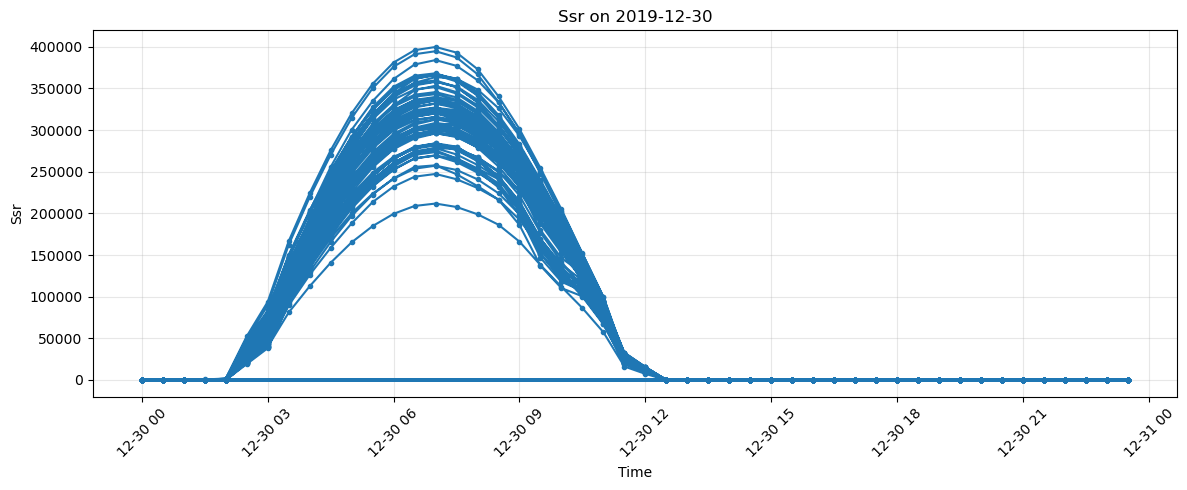

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-46.938042,0.0,0.5078125,32.5,0.0,79.0,0.0,1.8000e-12,0.0,0.0,0.0,-80186.851562,-79944.195312,189074.21875,189468.03125,252.50351,0.0,2019-12-30 00:00:00,0.0,0.0,0.0,-275054.84375,-275257.25,-1.031998,-0.288055,0.0,0.439941,3.41803
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-46.934719,0.0,0.5078125,32.5,0.0,79.0,0.0,9.0000e-13,0.0,0.0,0.0,-79309.476562,-79277.226562,188641.171875,189025.875,252.506287,0.0,2019-12-30 00:30:00,0.0,0.0,0.0,-274142.125,-274443.34375,-1.026108,-0.31916,0.0,0.467072,3.454681
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-46.931396,0.0,0.5078125,32.5,0.0,79.0,0.0,2.7000e-12,0.0,0.0,0.0,-78383.398438,-78603.648438,188304.421875,188619.875,252.509048,0.0,2019-12-30 01:00:00,0.0,0.0,0.0,-273302.875,-273674.65625,-1.020218,-0.350266,0.0,0.494202,3.491333
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",600.442444,0.0,0.756005,600.447327,1.0,0.0,-46.993053,0.0,0.5078125,32.5,0.0,79.0,0.0,510.69278,494.264496,1729.28064,1729.136597,-76194.429688,-77770.789062,187876.234375,188266.296875,252.528915,0.0,2019-12-30 01:30:00,0.0,1711.99231,1713.400513,-271794.875,-272924.09375,-1.028496,-0.424034,200.94519,0.487564,3.489639
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1767.557495,0.0,0.756005,1767.552612,1.0,0.0,-47.05471,0.0,0.5078125,32.5,0.0,79.0,0.0,1473.307251,1425.735474,4990.719238,4990.86377,-77677.757812,-77430.898438,188097.140625,187937.578125,252.548782,0.0,2019-12-30 02:00:00,0.0,4816.007812,4814.599609,-272639.15625,-272378.90625,-1.036774,-0.497803,575.05481,0.480927,3.487946
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.480766,0.0,0.507324,35.25,0.110687,78.0,0.947418,1.8000e-12,0.0,0.0,0.0,-46138.402344,-78486.539062,224755.40625,181407.046875,241.268311,0.947418,2019-12-30 21:30:00,0.000007,0.0,0.0,-270583.65625,-265383.25,-0.48764,0.344528,0.0,0.546112,2.491188
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-21.126656,0.0,0.507324,35.25,0.184113,78.0,0.942749,1.8000e-12,0.0,0.0,0.0,-42139.535156,-79025.648438,229676.9375,181794.65625,240.450027,0.942749,2019-12-30 22:00:00,0.000007,0.0,0.0,-270404.34375,-265888.78125,-0.518478,0.365891,0.0,0.555496,2.470856
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-20.133076,0.0,0.507324,35.25,0.374496,78.0,0.966721,1.8000e-12,0.0,0.0,0.0,-40981.636719,-79383.90625,231289.40625,182277.40625,240.44751,0.966721,2019-12-30 22:30:00,0.000014,0.0,0.0,-270402.1875,-266398.59375,-0.604912,0.22776,0.0,0.514824,2.423119


In [40]:
# filter data to date
plot_day_polars_direct(step5_interpolated_boundary_fixed_data_2019_pldf.filter(pl.col("adm2_code") == "76128533B57183548666997"), date='2019-12-30', column='ssr')

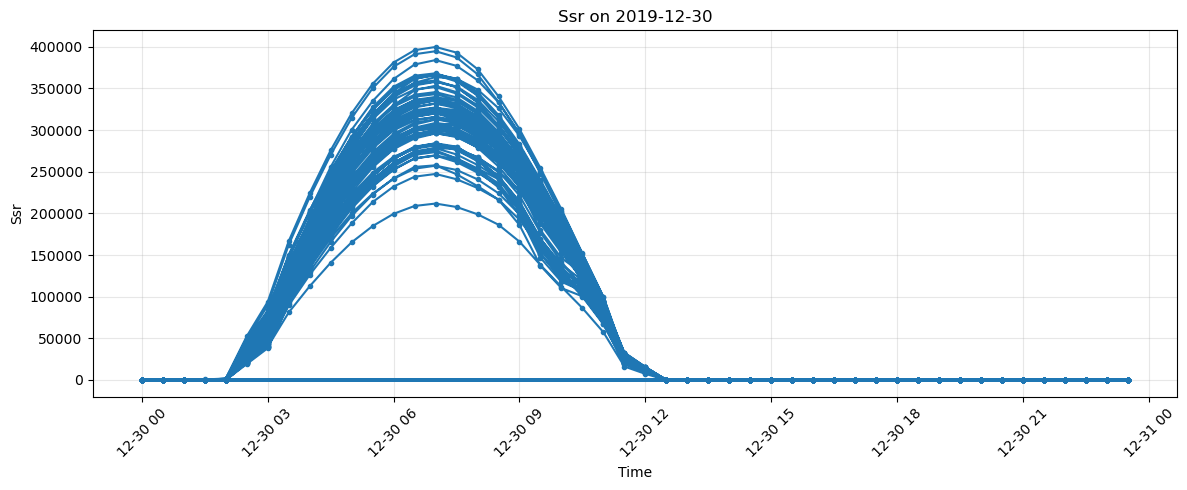

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-46.938042,0.0,0.5078125,32.5,0.0,79.0,0.0,1.8000e-12,0.0,0.0,0.0,-80186.851562,-79944.195312,189074.21875,189468.03125,252.50351,0.0,2019-12-30 00:00:00,0.0,0.0,0.0,-275054.84375,-275257.25,-1.031998,-0.288055,0.0,0.439941,3.41803
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-46.934719,0.0,0.5078125,32.5,0.0,79.0,0.0,9.0000e-13,0.0,0.0,0.0,-79309.476562,-79277.226562,188641.171875,189025.875,252.506287,0.0,2019-12-30 00:30:00,0.0,0.0,0.0,-274142.125,-274443.34375,-1.026108,-0.31916,0.0,0.467072,3.454681
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-46.931396,0.0,0.5078125,32.5,0.0,79.0,0.0,2.7000e-12,0.0,0.0,0.0,-78383.398438,-78603.648438,188304.421875,188619.875,252.509048,0.0,2019-12-30 01:00:00,0.0,0.0,0.0,-273302.875,-273674.65625,-1.020218,-0.350266,0.0,0.494202,3.491333
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",600.442444,0.0,0.756005,600.447327,1.0,0.0,-46.993053,0.0,0.5078125,32.5,0.0,79.0,0.0,510.69278,494.264496,1729.28064,1729.136597,-76194.429688,-77770.789062,187876.234375,188266.296875,252.528915,0.0,2019-12-30 01:30:00,0.0,1711.99231,1713.400513,-271794.875,-272924.09375,-1.028496,-0.424034,200.94519,0.487564,3.489639
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1767.557495,0.0,0.756005,1767.552612,1.0,0.0,-47.05471,0.0,0.5078125,32.5,0.0,79.0,0.0,1473.307251,1425.735474,4990.719238,4990.86377,-77677.757812,-77430.898438,188097.140625,187937.578125,252.548782,0.0,2019-12-30 02:00:00,0.0,4816.007812,4814.599609,-272639.15625,-272378.90625,-1.036774,-0.497803,575.05481,0.480927,3.487946
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.480766,0.0,0.507324,35.25,0.110687,78.0,0.947418,1.8000e-12,0.0,0.0,0.0,-46138.402344,-78486.539062,224755.40625,181407.046875,241.268311,0.947418,2019-12-30 21:30:00,0.000007,0.0,0.0,-270583.65625,-265383.25,-0.48764,0.344528,0.0,0.546112,2.491188
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-21.126656,0.0,0.507324,35.25,0.184113,78.0,0.942749,1.8000e-12,0.0,0.0,0.0,-42139.535156,-79025.648438,229676.9375,181794.65625,240.450027,0.942749,2019-12-30 22:00:00,0.000007,0.0,0.0,-270404.34375,-265888.78125,-0.518478,0.365891,0.0,0.555496,2.470856
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-20.133076,0.0,0.507324,35.25,0.374496,78.0,0.966721,1.8000e-12,0.0,0.0,0.0,-40981.636719,-79383.90625,231289.40625,182277.40625,240.44751,0.966721,2019-12-30 22:30:00,0.000014,0.0,0.0,-270402.1875,-266398.59375,-0.604912,0.22776,0.0,0.514824,2.423119


In [41]:
plot_day_polars_direct(step5_interpolated_boundary_fixed_data_2019_pldf.filter(pl.col("adm2_code") == "76128533B57183548666997"), date='2019-12-30', column='ssr')

In [46]:
display(step5_interpolated_boundary_fixed_data_2018_pldf.filter(
    (pl.col("longitude") == 78.0) &
    (pl.col("latitude") == 35.25) &
    (pl.col("time")>=pl.datetime(2018,12,31,18)))) #& (pl.col("time")<pl.datetime(2019,12,31,2))))

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-30.364983,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-90230.28125,-104918.539062,207225.015625,188303.546875,241.128036,1.0,2018-12-31 18:00:00,0.000002,0.0,0.0,-291285.15625,-285497.3125,0.061005,2.033279,0.0,1.146744,3.07074
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-31.879326,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-93336.664062,-102985.710938,199393.734375,188003.25,240.894241,1.0,2018-12-31 18:30:00,0.000002,0.0,0.0,-288148.34375,-284662.75,0.068008,2.033714,0.0,1.17218,3.125473
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-33.393669,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-91702.328125,-100595.296875,197908.203125,187588.125,240.660446,1.0,2018-12-31 19:00:00,0.000002,0.0,0.0,-286548.625,-283261.25,0.075012,2.034149,0.0,1.197617,3.180206
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-34.528488,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-84176.625,-96813.765625,203920.734375,186925.875,240.318344,1.0,2018-12-31 19:30:00,0.000002,0.0,0.0,-286973.375,-280908.15625,0.095184,2.033562,0.0,1.245667,3.213303
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-35.663307,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-82822.367188,-95016.242188,202769.578125,186703.875,239.976242,1.0,2018-12-31 20:00:00,0.000002,0.0,0.0,-285102.625,-279475.84375,0.115356,2.032974,0.0,1.293716,3.246399
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-33.501263,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-78269.523438,-88872.398438,200577.484375,188131.109375,239.85376,1.0,2018-12-31 21:30:00,0.000003,0.0,0.0,-279291.5625,-274774.71875,-0.015335,1.851021,0.0,1.247879,3.305145
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-32.187431,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-73830.476562,-86914.601562,204032.875,188835.03125,239.771393,1.0,2018-12-31 22:00:00,0.000003,0.0,0.0,-279076.4375,-273699.28125,-0.146622,1.709778,0.0,1.240204,3.268768
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-30.965366,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-69795.085938,-86732.453125,207198.25,189565.84375,239.543671,1.0,2018-12-31 22:30:00,0.000003,0.0,0.0,-279054.5,-273948.6875,-0.112793,1.652725,0.0,1.292587,3.341362


In [ ]:
display(step5_interpolated_boundary_fixed_data_2019_pldf.filter(
    (pl.col("longitude") == 78.0) &
    (pl.col("latitude") == 35.25)
))

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-27.226021,0.0,0.507324,35.25,1.0,78.0,0.032288,1.8000e-12,0.0,0.0,0.0,-66849.164062,-82240.625,204407.359375,191690.375,240.025558,1.0,2019-01-01 00:00:00,0.000002,0.0,0.0,-274475.21875,-272996.28125,-0.213013,1.385895,0.0,1.228958,3.381775
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-26.656876,0.0,0.507324,35.25,1.0,78.0,0.027817,1.8000e-12,0.0,0.0,0.0,-64716.011719,-81156.882812,206706.671875,191792.453125,240.170776,1.0,2019-01-01 00:30:00,0.000002,0.0,0.0,-274888.3125,-272480.125,-0.221375,1.309219,0.0,1.227043,3.36869
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-26.08773,0.0,0.507324,35.25,1.0,78.0,0.023346,1.8000e-12,0.0,0.0,0.0,-61379.734375,-79866.367188,209487.828125,192303.640625,240.31601,1.0,2019-01-01 01:00:00,0.000002,0.0,0.0,-275039.6875,-272191.875,-0.229736,1.232544,0.0,1.225128,3.355606
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-25.654457,0.0,0.507324,35.25,1.0,78.0,0.030426,9.0000e-13,0.0,0.0,0.0,-58272.445312,-80311.234375,211200.515625,192714.359375,240.560028,1.0,2019-01-01 01:30:00,0.000002,0.0,0.0,-275176.34375,-272842.96875,-0.234726,1.16909,0.0,1.2397,3.403282
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-25.221184,0.0,0.507324,35.25,1.0,78.0,0.037506,2.7000e-12,0.0,0.0,0.0,-57800.871094,-80137.265625,213388.046875,193087.34375,240.804062,1.0,2019-01-01 02:00:00,0.000002,0.0,0.0,-276220.65625,-273106.03125,-0.239716,1.105637,0.0,1.254272,3.450958
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.163815,0.0,0.507324,35.25,1.0,78.0,0.948792,1.8000e-12,0.0,0.0,0.0,-47864.460938,-132315.109375,279141.0625,177564.265625,245.678146,1.0,2019-12-31 21:30:00,0.000012,0.0,0.0,-293828.375,-290187.53125,0.154305,0.82206,0.0,1.356194,3.14254
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.547119,0.0,0.507324,35.25,1.0,78.0,0.916199,1.8000e-12,0.0,0.0,0.0,-51128.167969,-131956.640625,273680.03125,177105.984375,245.143936,1.0,2019-12-31 22:00:00,0.000012,0.0,0.0,-293914.59375,-289699.46875,0.20079,0.968369,0.0,1.394882,3.201523
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-22.967968,0.0,0.507324,35.25,1.0,78.0,0.711304,1.8000e-12,0.0,0.0,0.0,-54785.285156,-129168.914062,266368.40625,176351.359375,244.713531,1.0,2019-12-31 22:30:00,0.000012,0.0,0.0,-293568.71875,-287609.96875,0.143471,0.993813,0.0,1.420074,3.283943


: 

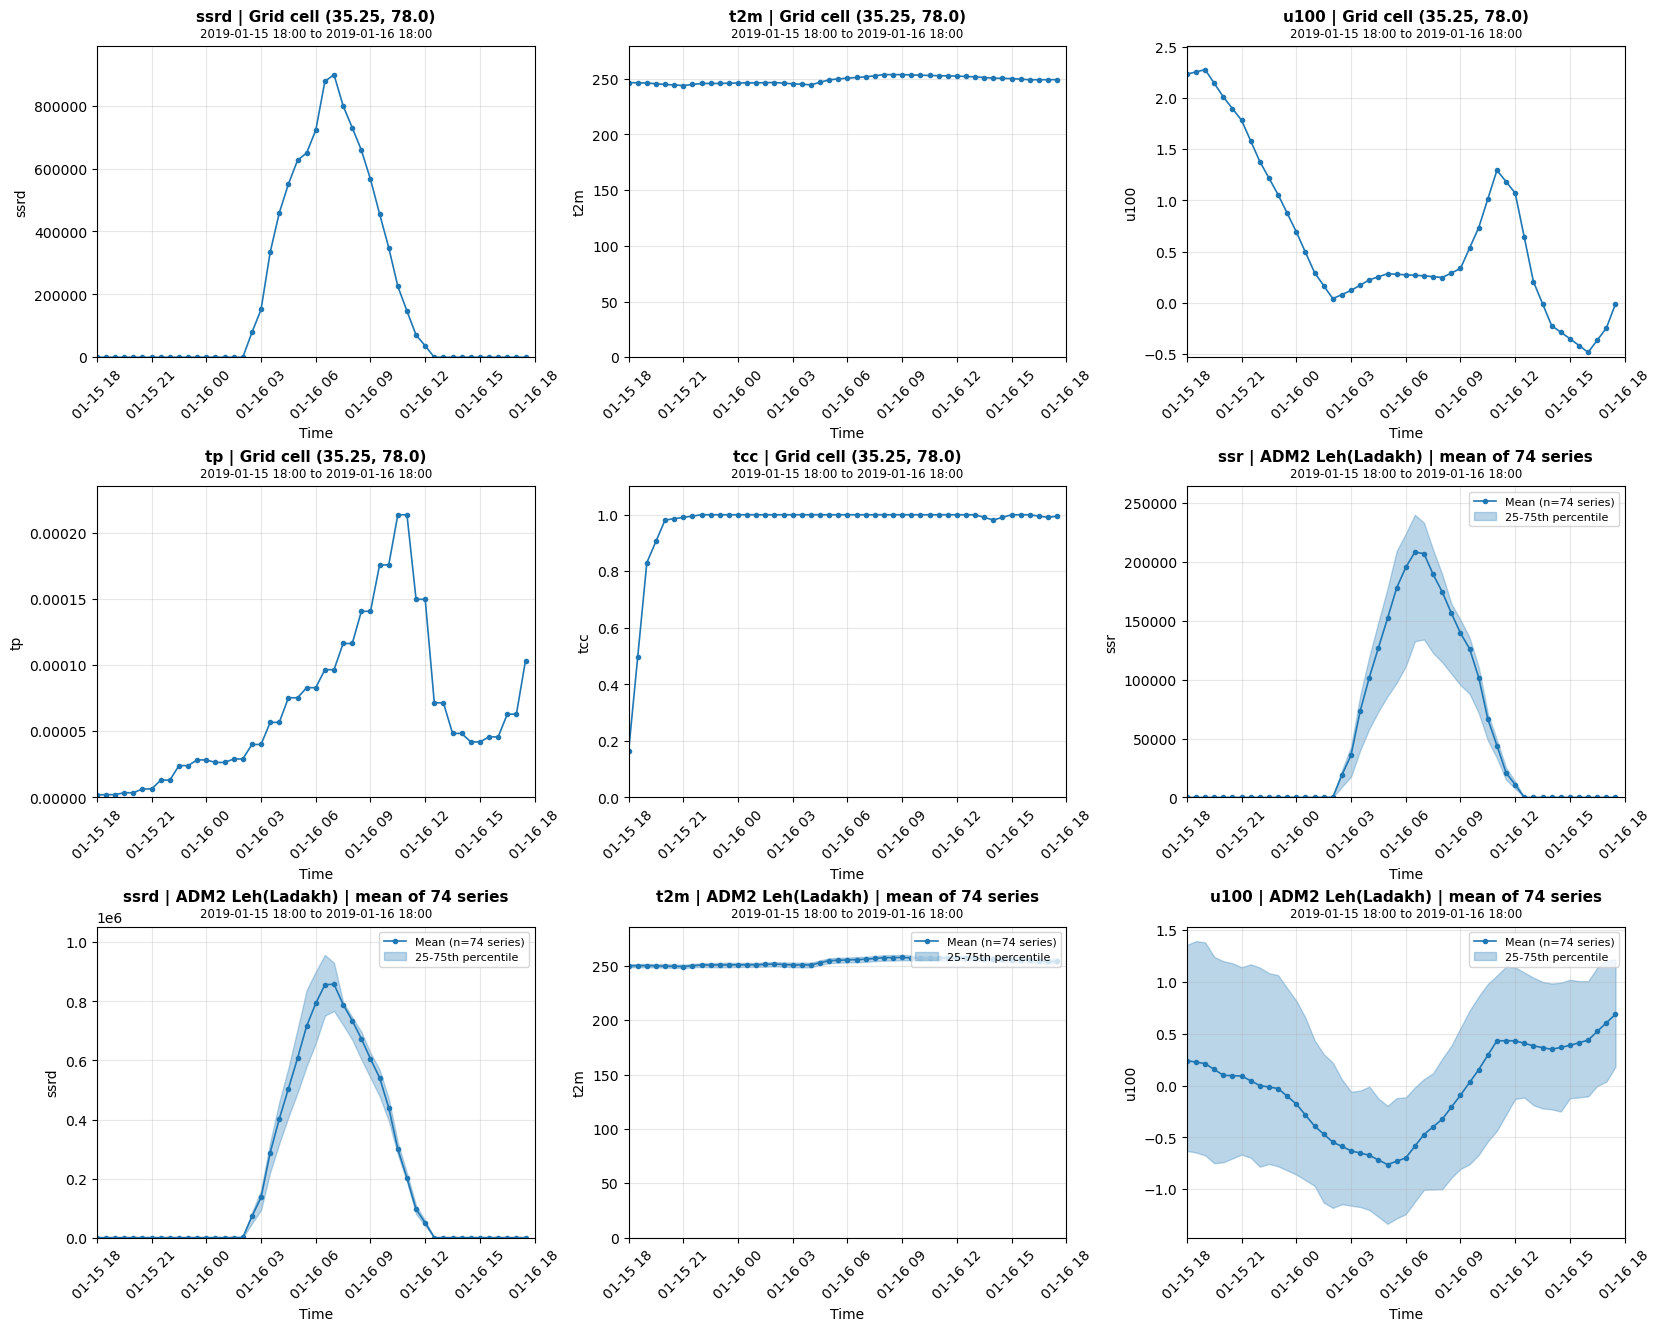

In [44]:
fig, axes, extracted = plot_polars_time_series_grid(df=step5_interpolated_boundary_fixed_data_2019_pldf, plot_specs=plot_specs_2019)

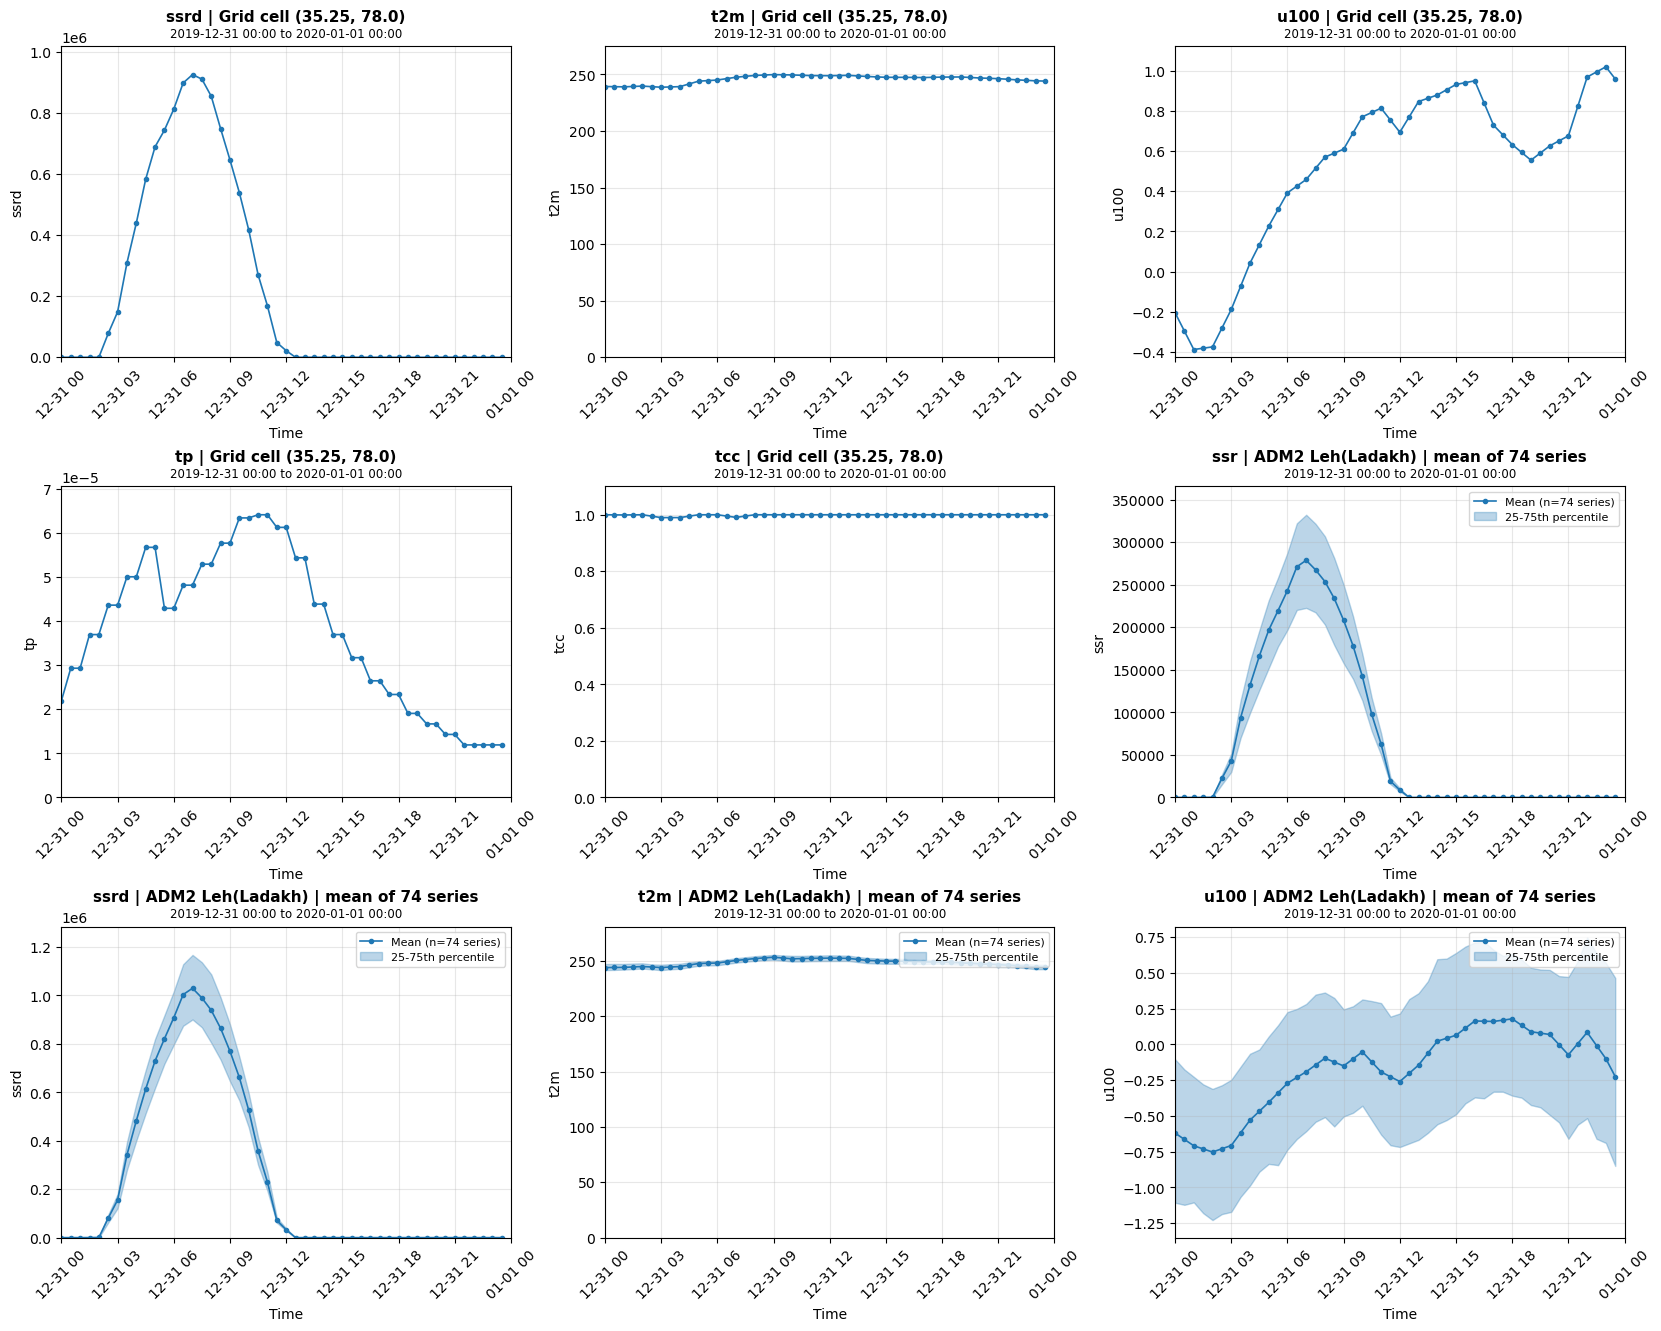

In [45]:
fig, axes, extracted = plot_polars_time_series_grid(df=step5_interpolated_boundary_fixed_data_2019_pldf, plot_specs=eo_plot_specs_2019)

##### Step 6 Data:

In [25]:
step6_interpolated_final_data_2018_pldf = pl.read_parquet(step6_interpolated_final_data_2018_path)

In [26]:
# Describe
print('Step 6 Interpolated Final Data 2018 Description')
display(step6_interpolated_final_data_2018_pldf.describe())

Step 6 Interpolated Final Data 2018 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""77823840""","""77823840""","""77823840""","""77823840""","""77823840""","""77823840""",7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,"""77823840""",7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7,7.782384e7
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,372091.875,0.279998,0.663284,268641.21875,1.0,0.339123,15.01128,1.794127,1.656656,22.886875,0.145376,79.613518,0.196462,309858.1875,380475.28125,384867.625,470369.46875,-127364.734375,-145349.65625,670825.1875,651902.75,297.215393,0.446709,"""2018-07-02 11:45:00""",0.000067,490147.09375,561632.625,-467681.59375,-510028.28125,0.530051,0.814341,43896.234375,0.055113,0.051284
"""std""",null,null,null,null,null,null,496889.125,0.31615,0.325826,412490.4375,0.0,0.413964,22.095919,1.230856,0.750643,5.504276,0.268535,5.880583,0.274953,428676.6875,495816.96875,526308.9375,604391.0,79766.632812,68071.546875,109778.78125,109687.804688,9.873069,0.411805,null,0.000289,627006.9375,705073.375,86678.375,41889.738281,2.255062,3.613466,60772.910156,1.608761,2.578426
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-117.629463,0.0,0.0,8.25,0.0,68.25,0.0,8.5000e-13,0.0,0.0,0.0,-9.6494144e7,-661168.375,100709.109375,94867.390625,226.659988,0.0,"""2018-01-01 00:00:00""",0.0,0.0,0.0,-721858.4375,-724650.1875,-14.483887,-19.481308,0.0,-18.665878,-20.938965
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,2.100697,0.981934,1.084717,19.5,0.0,75.5,0.0,1.8000e-12,0.0,0.0,0.0,-164231.703125,-175908.90625,605254.125,594859.875,293.936768,0.010818,"""2018-04-02 06:00:00""",0.0,0.0,0.0,-527433.1875,-534732.0625,-1.009964,-1.580956,0.0,-0.999878,-1.547997
"""50%""",null,null,null,null,null,null,5473.385254,0.149811,0.755631,861.55127,1.0,0.045227,23.122555,1.973877,1.619019,23.5,0.0,78.25,0.060883,11787.571289,15394.000977,15072.543945,20933.759766,-116122.53125,-129441.546875,689558.6875,672905.75,299.03833,0.335999,"""2018-07-02 12:00:00""",0.0,35812.320312,41408.015625,-495748.375,-509871.4375,0.317116,0.510239,1899.929932,-0.017548,-0.034409
"""75%""",null,null,null,null,null,null,797344.625,0.504298,0.976124,457876.53125,1.0,0.837326,32.26231,2.349365,2.261597,26.75,0.149811,82.5,0.291443,592645.4375,810368.4375,751884.1875,1.0161e6,-71218.1875,-97337.945312,757689.3125,731065.8125,302.88208,0.941223,"""2018-10-01 17:30:00""",0.000006,1006678.5,1.1964e6,-420602.5,-486950.25,1.947708,3.25177,84104.835938,0.999451,1.547821
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",1.8378e6,1.0,1.0,1.9950e6,1.0,1.0,46.955696,6.530518,3.891846,35.25,1.0,97.25,1.0,1.7732e6,1.812096e6,2.19841e6,2.1419e6,9.6503064e7,-32247.685547,938047.375,937519.5,322.637939,1.0,"""2018-12-31 23:30:00""",0.027919,2.2742e6,2243491.5,-117882.671875,-136009.609375,12.241653,16.166748,278455.46875,15.475861,19.226913


In [27]:
print('Step 6 Interpolated Final Data 2018 — First 8 rows:')
display(step6_interpolated_final_data_2018_pldf.head(8))
print('Step 6 Interpolated Final Data 2018 — Last 8 rows:')
display(step6_interpolated_final_data_2018_pldf.tail(8))

Step 6 Interpolated Final Data 2018 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.679626,23.215073,2.009766,2.217529,8.25,0.025208,77.25,0.00946,1.8000e-12,0.0,0.0,0.0,-103075.914062,-114321.546875,682848.75,684819.125,296.919067,0.685303,2018-01-01 00:00:00,0.0,0.0,0.0,-509683.21875,-515147.8125,-0.143936,-0.339081,0.0,-1.499603,-1.808823
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.462158,22.438404,2.009766,2.21759,8.25,0.041428,77.25,0.021362,9.0000e-13,0.0,0.0,0.0,-101169.679688,-114271.460938,682860.8125,683819.0,296.855988,0.486664,2018-01-01 00:30:00,0.0,0.0,0.0,-510147.8125,-514594.46875,-0.148972,-0.316956,0.0,-1.54351,-1.792931
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",0.0,0.611776,0.388224,0.0,1.0,0.24469,21.661736,2.009766,2.217651,8.25,0.057648,77.25,0.033264,2.7000e-12,0.0,0.0,0.0,-102304.382812,-114291.96875,681977.375,683064.8125,296.792908,0.288025,2018-01-01 01:00:00,0.0,0.0,0.0,-510727.15625,-514376.53125,-0.154007,-0.29483,0.0,-1.587418,-1.777039
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",35116.691406,0.611776,0.388224,35387.386719,1.0,0.296631,21.0975,2.009827,2.217651,8.25,0.0336,77.25,0.020416,54545.515625,49042.128906,63345.363281,62709.472656,-104842.679688,-112994.53125,678783.4375,681865.75,297.284882,0.3228,2018-01-01 01:30:00,0.0,110319.257812,105197.804688,-511171.3125,-514074.3125,-0.218918,-0.366295,6914.79248,-1.493935,-1.719696
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",77139.304688,0.611776,0.388224,77316.617188,1.0,0.348572,20.533264,2.009888,2.217651,8.25,0.009552,77.25,0.007568,113710.476562,104941.867188,131534.625,130826.523438,-110942.453125,-115824.09375,679976.4375,682133.0,297.776855,0.357574,2018-01-01 02:00:00,0.0,218256.734375,210962.1875,-512615.65625,-514666.6875,-0.283829,-0.437759,14213.208008,-1.400452,-1.662354
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",259271.53125,0.611776,0.388224,253880.484375,1.0,0.286743,20.340279,2.009888,2.217712,8.25,0.035721,77.25,0.022079,316483.78125,322087.40625,361637.53125,366417.09375,-121966.125,-123112.203125,685045.6875,683374.6875,298.161194,0.312195,2018-01-01 02:30:00,0.0,512892.375,519120.75,-515157.9375,-516181.96875,-0.300034,-0.402771,37213.625,-1.182655,-1.424461
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",409592.46875,0.611776,0.388224,401415.5,1.0,0.224915,20.147293,2.009888,2.217773,8.25,0.06189,77.25,0.036591,481084.21875,494104.59375,546970.5,553838.9375,-131754.875,-128648.78125,689374.375,685650.1875,298.545532,0.266815,2018-01-01 03:00:00,0.0,745859.625,759215.1875,-517288.09375,-517534.0625,-0.316238,-0.367783,57226.375,-0.964859,-1.186569
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",607773.9375,0.611776,0.388224,600141.1875,1.0,0.271591,20.151382,2.009949,2.217773,8.25,0.052383,77.25,0.027573,677341.125,694851.5,763186.5,767314.1875,-142384.125,-134072.09375,694408.9375,689434.1875,298.897827,0.300873,2018-01-01 03:30:00,0.0,989000.8125,1005866.5,-519321.1875,-519081.34375,-0.21563,-0.261841,84299.296875,-0.85746,-

Step 6 Interpolated Final Data 2018 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-35.663307,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-82822.367188,-95016.242188,202769.578125,186703.875,239.976242,1.0,2018-12-31 20:00:00,0.000002,0.0,0.0,-285102.625,-279475.84375,0.115356,2.032974,0.0,1.293716,3.246399
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-35.239201,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-87872.0,-95533.242188,194252.3125,186698.328125,239.956177,1.0,2018-12-31 20:30:00,0.000002,0.0,0.0,-280749.625,-278969.25,0.115654,2.012619,0.0,1.274635,3.293961
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-34.815094,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-85929.992188,-93499.765625,193998.015625,187114.53125,239.936111,1.0,2018-12-31 21:00:00,0.000002,0.0,0.0,-279044.375,-277477.78125,0.115952,1.992264,0.0,1.255554,3.341522
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-33.501263,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-78269.523438,-88872.398438,200577.484375,188131.109375,239.85376,1.0,2018-12-31 21:30:00,0.000003,0.0,0.0,-279291.5625,-274774.71875,-0.015335,1.851021,0.0,1.247879,3.305145
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-32.187431,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-73830.476562,-86914.601562,204032.875,188835.03125,239.771393,1.0,2018-12-31 22:00:00,0.000003,0.0,0.0,-279076.4375,-273699.28125,-0.146622,1.709778,0.0,1.240204,3.268768
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-30.965366,0.0,0.507324,35.25,1.0,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-69795.085938,-86732.453125,207198.25,189565.84375,239.543671,1.0,2018-12-31 22:30:00,0.000003,0.0,0.0,-279054.5,-273948.6875,-0.112793,1.652725,0.0,1.292587,3.341362
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-29.743301,0.0,0.507324,35.25,1.0,78.0,0.0,9.0000e-13,0.0,0.0,0.0,-35782.105469,-41792.941406,100709.109375,94939.125,239.315948,1.0,2018-12-31 23:00:00,0.000001,0.0,0.0,-137688.984375,-136009.609375,-0.078964,1.595673,0.0,1.344971,3.413956
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-28.484661,0.0,0.507324,35.25,1.0,78.0,0.016144,9.0000e-13,0.0,0.0,0.0,-33880.273438,-43299.585938,104715.992188,94867.390625,239.670746,1.0,2018-12-31 23:30:00,0.000001,0.0,0.0,-139755.9375,-136930.71875,-0.145988,1.490784,0.0,1.286964,3.397865


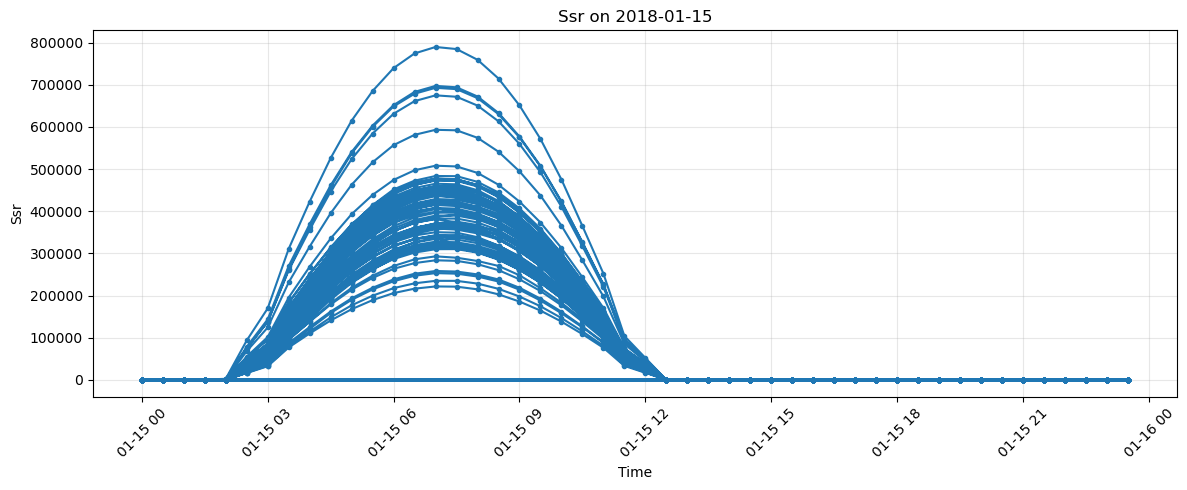

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-47.061348,0.0,0.5078125,32.5,0.341827,79.0,0.0,1.8000e-12,0.0,0.0,0.0,-73529.6875,-101125.765625,217273.0625,200328.265625,245.452087,0.341827,2018-01-15 00:00:00,2.3842e-7,0.0,0.0,-297580.84375,-297290.25,-0.809845,1.471481,0.0,-0.24942,1.065002
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-45.946278,0.0,0.5078125,32.5,0.325714,79.0,0.0,9.0000e-13,0.0,0.0,0.0,-75116.242188,-102362.765625,215713.625,199875.3125,244.868896,0.325714,2018-01-15 00:30:00,2.3842e-7,0.0,0.0,-297004.78125,-297454.5625,-0.865601,1.350204,0.0,-0.290337,1.152512
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.756005,0.0,1.0,0.0,-44.831207,0.0,0.5078125,32.5,0.309601,79.0,0.0,2.7000e-12,0.0,0.0,0.0,-75636.882812,-102471.171875,215177.625,199578.625,244.285721,0.309601,2018-01-15 01:00:00,2.3842e-7,0.0,0.0,-296305.1875,-297168.4375,-0.921356,1.228928,0.0,-0.331253,1.240021
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",485.540619,0.0,0.756005,371.752625,1.0,0.0,-44.108688,0.0,0.5078125,32.5,0.364746,79.0,0.0,639.746338,689.438354,1393.910156,1459.781006,-74856.3125,-101402.703125,213533.078125,199409.78125,244.419403,0.364746,2018-01-15 01:30:00,2.3842e-7,1661.728394,1729.205811,-293789.75,-296465.0,-0.939072,1.124802,162.79155,-0.310486,1.532059
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1434.459473,0.0,0.756005,1100.247437,1.0,0.0,-43.386169,0.0,0.5078125,32.5,0.419891,79.0,0.0,1856.253662,1998.561646,4046.0896,4236.219238,-78049.125,-100837.679688,214268.84375,199413.78125,244.553101,0.419891,2018-01-15 02:00:00,2.3842e-7,4738.271484,4926.794434,-295108.25,-296033.0,-0.956787,1.020676,469.208435,-0.289719,1.824097
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-37.298222,0.0,0.507324,35.25,0.014771,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-77196.75,-75306.109375,192690.65625,191855.078125,243.482849,0.014771,2018-01-15 21:30:00,0.0,0.0,0.0,-273779.75,-272066.46875,0.105476,1.606201,0.0,1.539131,4.357491
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-36.944191,0.0,0.507324,35.25,0.022675,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-75704.117188,-74209.320312,192612.9375,192023.9375,243.010529,0.022675,2018-01-15 22:00:00,0.0,0.0,0.0,-273093.25,-271709.5625,-0.028397,1.369034,0.0,1.451538,4.264587
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.958188,0.0,1.0,0.0,-36.601288,0.0,0.507324,35.25,0.028854,78.0,0.0,1.8000e-12,0.0,0.0,0.0,-74566.351562,-73082.523438,192101.5625,192086.296875,242.844635,0.028854,2018-01-15 22:30:00,0.0,0.0,0.0,-272061.53125,-271326.09375,-0.05336,1.321899,0.0,1.426369,4.194954


In [28]:
plot_day_polars_direct(step6_interpolated_final_data_2018_pldf.filter(pl.col("adm2_code") == "76128533B57183548666997"), date='2018-01-15', column='ssr')

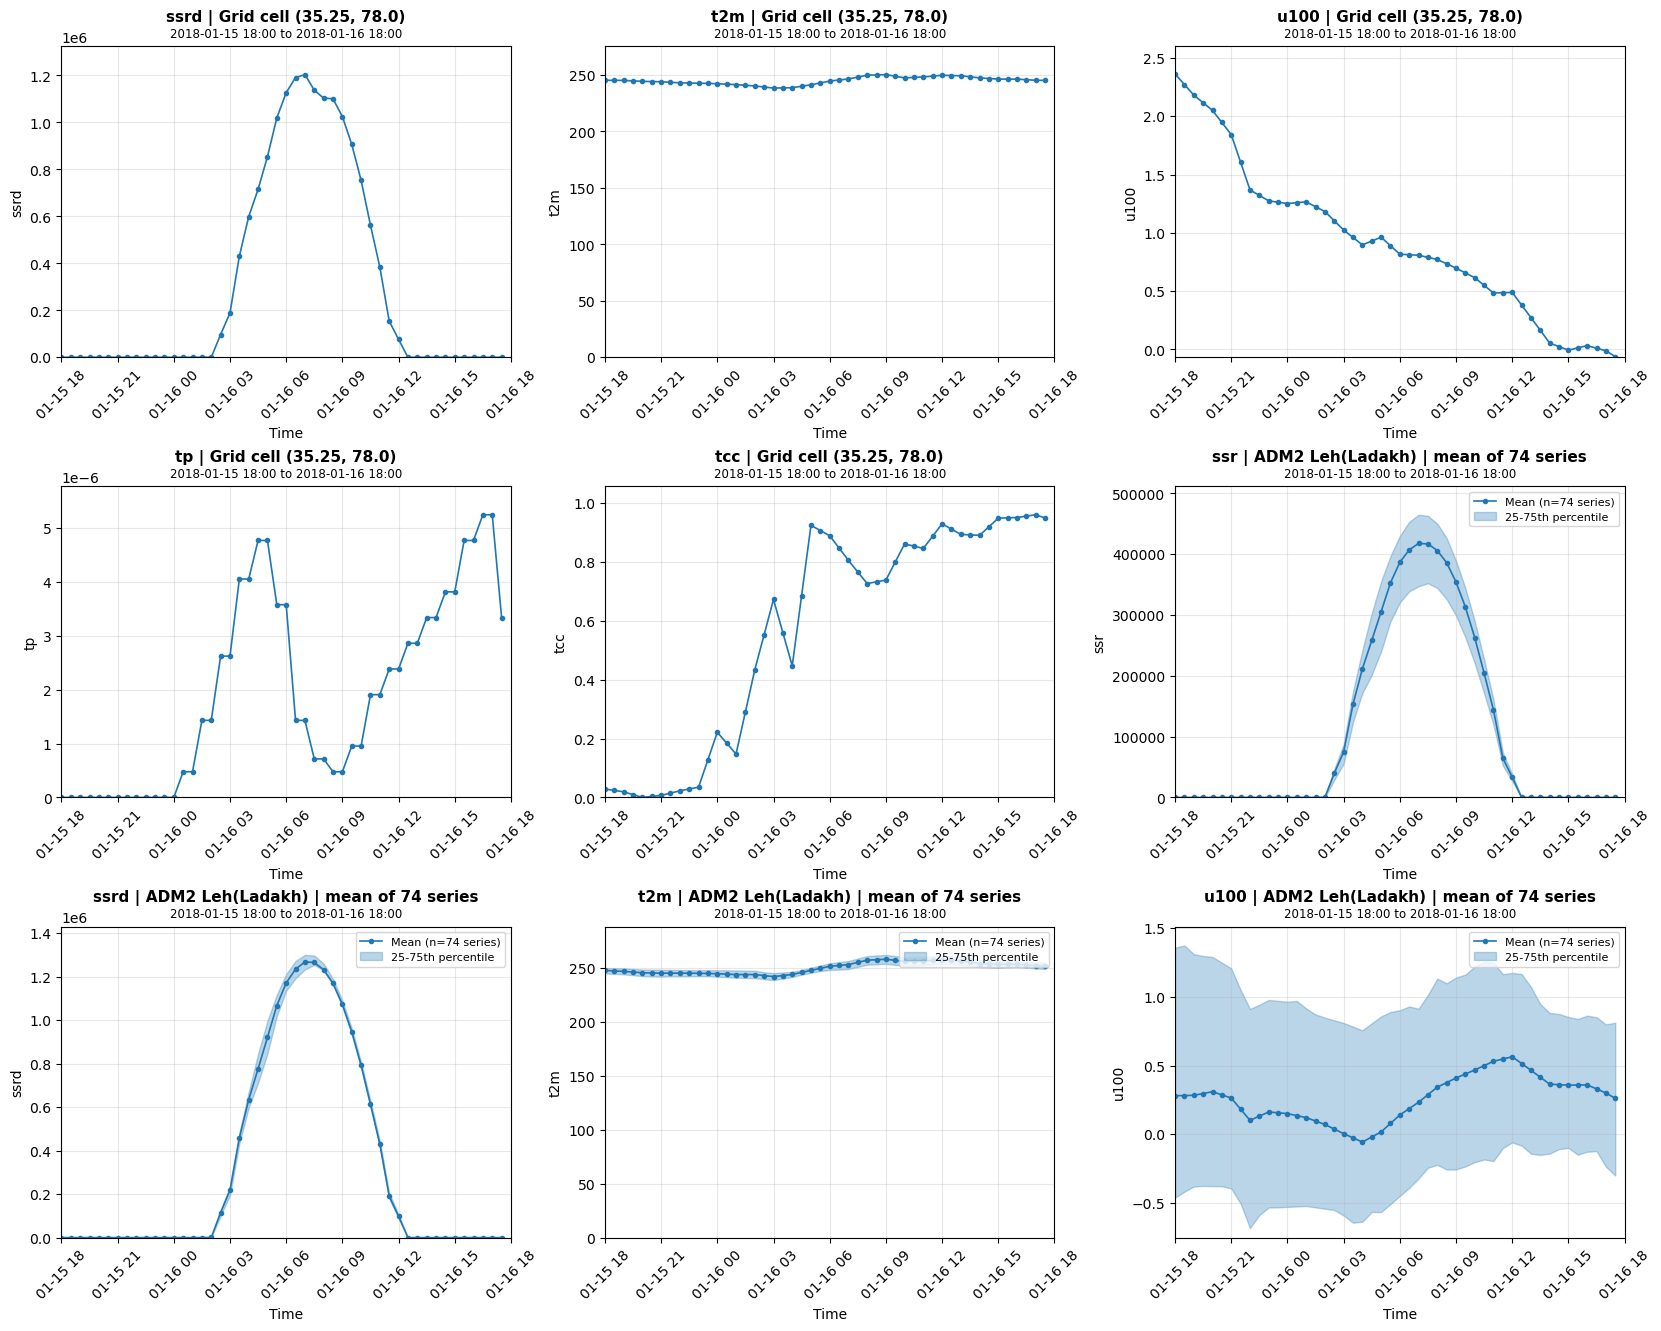

In [29]:
fig, axes, extracted = plot_polars_time_series_grid(df=step6_interpolated_final_data_2018_pldf, plot_specs=plot_specs_2018)

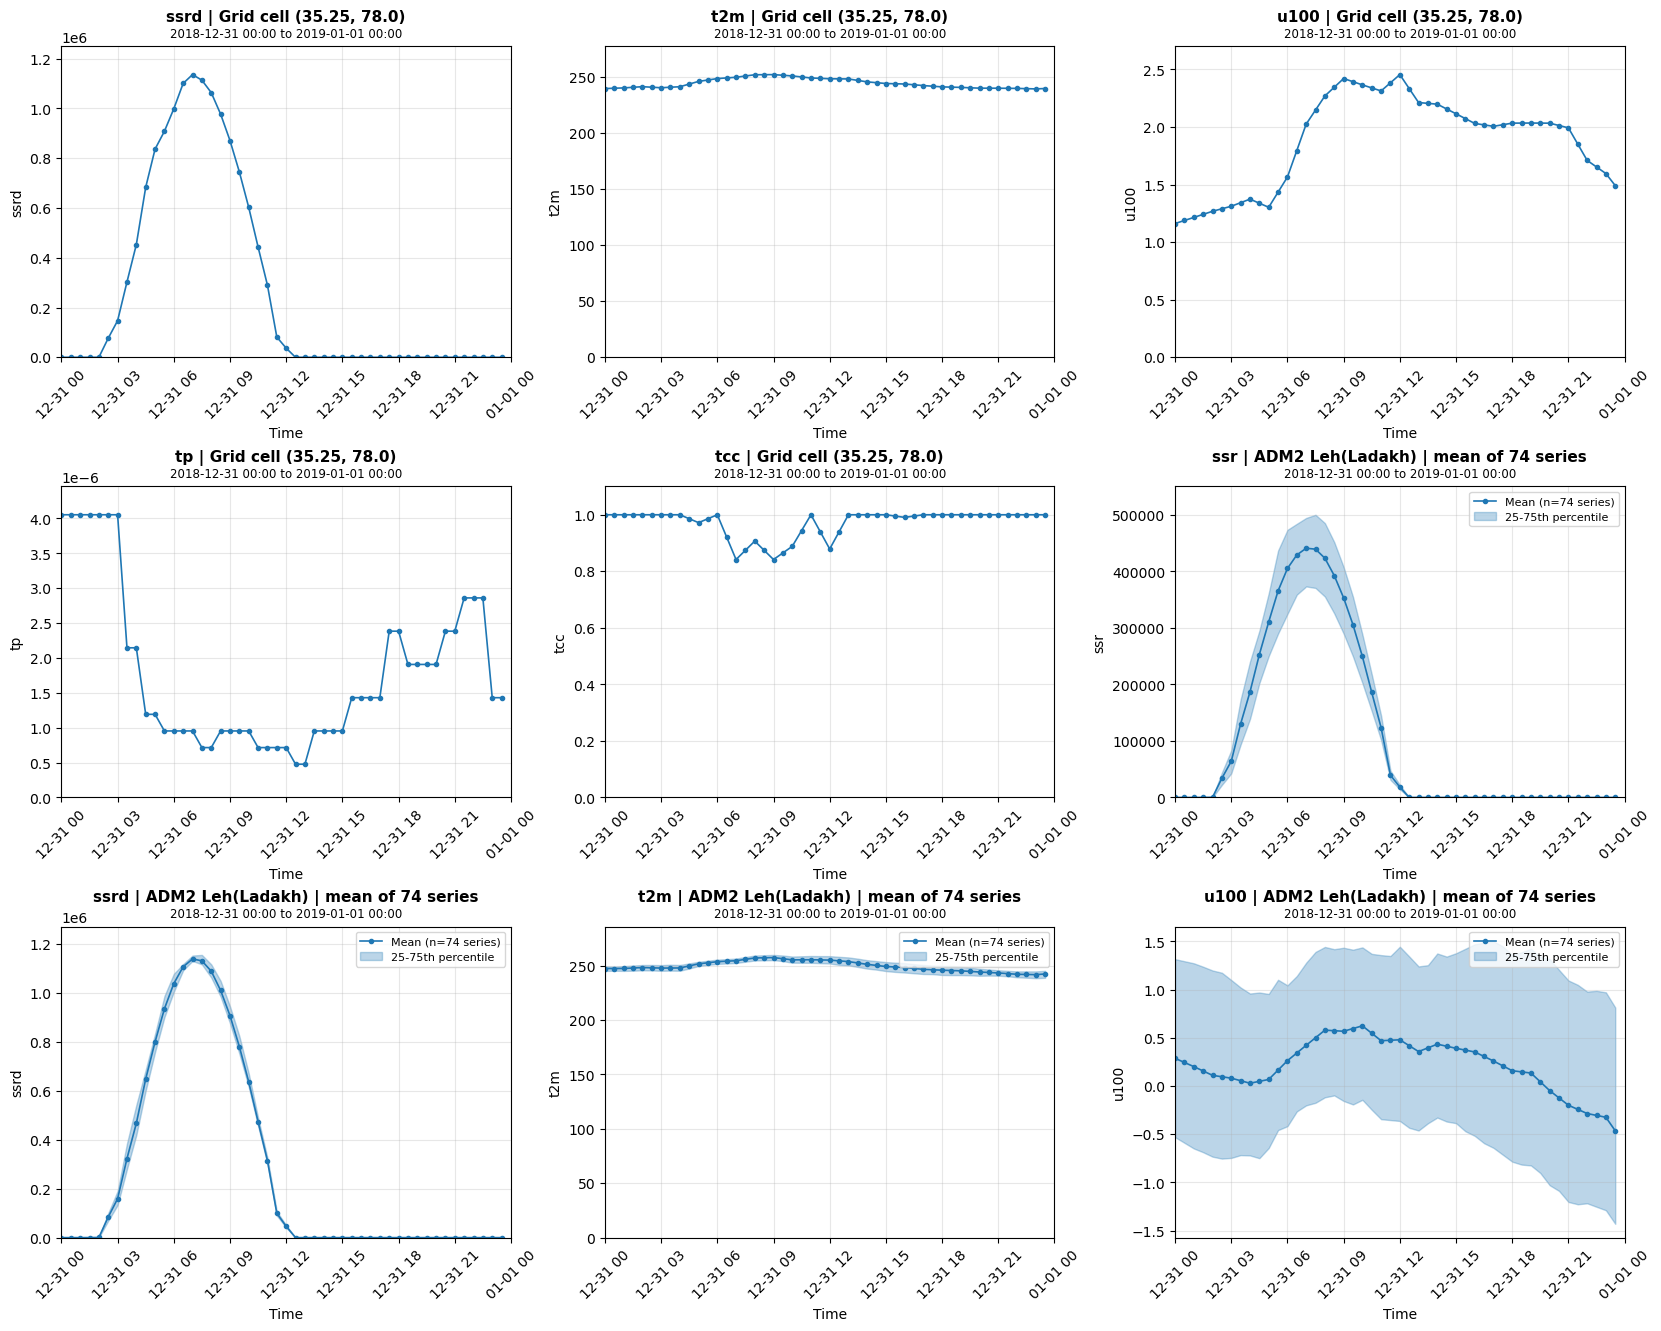

In [30]:
fig, axes, extracted = plot_polars_time_series_grid(df=step6_interpolated_final_data_2018_pldf, plot_specs=eo_plot_specs_2018)

##### Step 7 Data:

In [ ]:
# step1_masked_data_2018_01_pldf = pl.read_parquet(source=step1_masked_data_2018_01_path)
# step1_masked_data_2018_03_pldf = pl.read_parquet(source=step1_masked_data_2018_03_path)
# step1_masked_data_2018_12_pldf = pl.read_parquet(source=step1_masked_data_2018_12_path)
# step2_trimmed_data_2018_01_pldf = pl.read_parquet(source=step2_trimmed_data_2018_01_path)
# step2_trimmed_data_2018_03_pldf = pl.read_parquet(source=step2_trimmed_data_2018_03_path)
# step2_trimmed_data_2018_12_pldf = pl.read_parquet(source=step2_trimmed_data_2018_12_path)
# step3_consolidated_data_2018_pldf = pl.read_parquet(source=step3_consolidated_data_2018_path)
# step3_consolidated_data_2019_pldf = pl.read_parquet(source=step3_consolidated_data_2019_path)
# step4_interpolated_data_2018_pldf = pl.read_parquet(source=step4_interpolated_data_2018_path)
# step4_interpolated_data_2019_pldf = pl.read_parquet(source=step4_interpolated_data_2019_path)
# step5_interpolated_boundary_fixed_data_2018_pldf = pl.read_parquet(source=step5_interpolated_boundary_fixed_data_2018_path)
# step5_interpolated_boundary_fixed_data_2019_pldf = pl.read_parquet(source=step5_interpolated_boundary_fixed_data_2019_path)
# step6_interpolated_final_data_2018_pldf = pl.read_parquet(step6_interpolated_final_data_2018_path)
# step6_interpolated_final_data_2019_pldf = pl.read_parquet(source=step6_interpolated_final_data_2019_path)
# step7_processed_data_ADM0_pldf = pl.read_parquet(source=step7_processed_data_ADM0_path)
# step8_processed_data_ADM0_pldf = pl.read_parquet(source=step8_processed_data_ADM0_path)
# step7_processed_data_ADM1_pldf = pl.read_parquet(source=step7_processed_data_ADM1_path)
# step8_processed_data_ADM1_pldf = pl.read_parquet(source=step8_processed_data_ADM1_path)

In [ ]:
# step7_processed_data_ADM0_pldf = pl.read_parquet(source=step7_processed_data_ADM0_path)


In [ ]:
step7_processed_data_2018_pldf = pl.read_parquet(source=step7_processed_data_2018_path)

In [ ]:
# Describe
print('Step 7 Processed Data 2018 Description')
display(step7_processed_data_2018_pldf.describe())

Step 7 Processed Data 2018 Description


statistic,time,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr_avg,ssr_total,ssrc_avg,ssrc_total,ssrd_avg,ssrd_total,ssrdc_avg,ssrdc_total,str_avg,str_total,strc_avg,strc_total,strd_avg,strd_total,strdc_avg,strdc_total,tsr_avg,tsr_total,tsrc_avg,tsrc_total,ttr_avg,ttr_total,ttrc_avg,ttrc_total,cdir_avg,cdir_total,fdir_avg,fdir_total,uvb_avg,uvb_total,tp_avg,tp_total,wind_10m_speed,wind_10m_dir_deg,wind_100m_speed,wind_100m_dir_deg
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""4320""",4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2018-02-14 23:45:00""",-0.015315,-0.329214,-0.070613,-0.579174,293.659698,0.245332,0.153197,0.093394,0.055225,1.155082,0.28261,0.661743,1.753866,1.623087,331654.6875,1.3510e9,355095.75,1.4464e9,410483.1875,1.6721e9,439007.25,1.7882e9,-162446.9375,-6.6171e8,-174080.984375,-7.0910e8,598400.875,2.4375e9,585867.375,2.3865e9,471966.46875,1.9225e9,495127.59375,2.0168e9,-498209.0,-2.0294e9,-513290.25,-2.0908e9,357929.59375,1.4580e9,316588.46875,1.2896e9,45453.511719,1.85149056e8,0.000011,0.04624,0.694158,158.719757,1.205652,166.00444
"""std""",null,0.542517,0.419188,0.905872,0.740302,8.414896,0.14931,0.147267,0.069189,0.031398,15.575339,0.006083,0.014243,0.046743,0.046493,440926.8125,1.7961e9,470912.09375,1.9182e9,545681.125,2.2228e9,580766.1875,2.3657e9,56786.808594,2.31313808e8,55518.421875,2.26147184e8,42703.5,1.73947248e8,40822.289062,1.66284368e8,608710.625,2.4795e9,637600.5,2.5972e9,33672.0625,1.37158832e8,26345.796875,1.07316232e8,487985.9375,1.9877e9,436639.125,1.7786e9,61561.632812,2.5076344e8,0.000015,0.060301,0.310995,127.310852,0.505198,127.197853
"""min""","""2018-01-01 00:00:00""",-1.290666,-1.359942,-2.242899,-2.258142,0.0,0.0,0.0,0.0,0.0,-31.804468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-309404.28125,-1.2603e9,-316614.21875,-1.2897e9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-632823.5,-2.5777e9,-642873.25,-2.6187e9,0.0,0.0,0.0,0.0,0.0,0.0,5.9713e-8,0.000243,0.0,0.011597,0.0,0.05835
"""25%""","""2018-01-23 12:00:00""",-0.413622,-0.635513,-0.778483,-1.1259,289.225464,0.150754,0.054298,0.047503,0.032336,-14.434318,0.282741,0.662049,1.726371,1.603896,1.2090e-13,4.9245e-10,0.0,0.0,0.0,0.0,0.0,0.0,-212949.109375,-8.6742e8,-226710.359375,-9.2348e8,568672.0,2.3164e9,557228.6875,2.2698e9,0.0,0.0,0.0,0.0,-517947.90625,-2.1098e9,-531003.625,-2.1630e9,0.0,0.0,0.0,0.0,0.0,0.0,0.000002,0.009792,0.489007,38.939606,0.845374,44.040314
"""50%""","""2018-02-15 00:00:00""",-0.101078,-0.364462,-0.148749,-0.589086,293.737213,0.208933,0.115441,0.076326,0.050156,6.565648,0.282741,0.662049,1.755693,1.631411,10114.074219,4.1198388e7,10225.564453,4.1652528e7,12522.097656,5.1007164e7,13677.920898,5.571526e7,-132767.25,-5.4081e8,-142954.046875,-5.8231e8,597805.4375,2.4351e9,584627.4375,2.3814e9,22132.677734,9.0154632e7,23301.787109,9.4916848e7,-498858.84375,-2.0320e9,-508323.5625,-2.0706e9,6314.433594,2.5721038e7,5003.492676,2.0381088e7,1359.960938,5.539627e6,0.000006,0.02511,0.659378,107.306122,1.187766,123.930969
"""75%""","""2018-03-09 11:30:00""",0.326021,-0.0588,0.615939,-0.105941,297.393616,0.285086,0.193844,0.117561,0.071164,14.77595,0.282741,0.662049,1.777946,1.647439,713509.4375,2.9064e9,773464.625,3.1506e9,884942.125,3.6047e9,953206.875,3.8828e9,-118325.125,-4.8198e8,-129138.148438,-5.260

In [ ]:
print('Step 5 Interpolated Boundary Fixed Data 2018 — First 8 rows:')
display(step5_interpolated_boundary_fixed_data_2018_pldf.head(8))
print('Step 5 Interpolated Boundary Fixed Data 2018 — Last 8 rows:')
display(step5_interpolated_boundary_fixed_data_2018_pldf.tail(8))

Step 5 Interpolated Boundary Fixed Data 2018 — First 8 rows:


latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
8.25,77.25,2018-01-01 00:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.143936,-1.499603,-0.339081,-1.808823,296.919067,0.685303,0.679626,0.00946,0.025208,23.215073,0.611776,0.388224,2.009766,2.217529,6.1480e-14,0.0,0.0,0.0,-69101.445312,-76225.757812,455355.25,456939.84375,0.0,0.0,-339573.40625,-343621.1875,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 00:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.148972,-1.54351,-0.316956,-1.792931,296.855988,0.486664,0.462158,0.021362,0.041428,22.438404,0.611776,0.388224,2.009766,2.21759,1.2296e-13,0.0,0.0,0.0,-137434.5625,-152428.75,910464.9375,913092.125,0.0,0.0,-679577.625,-686863.75,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 01:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.154007,-1.587418,-0.29483,-1.777039,296.792908,0.288025,0.24469,0.033264,0.057648,21.661736,0.611776,0.388224,2.009766,2.217651,2.0540e-28,0.0,0.0,0.0,-100882.03125,-114266.335938,683081.5625,684007.5,0.0,0.0,-510002.96875,-514648.96875,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 01:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.218918,-1.493935,-0.366295,-1.719696,297.284882,0.3228,0.296631,0.020416,0.0336,21.0975,0.611776,0.388224,2.009827,2.217651,3.6000e-12,0.0,0.0,0.0,-102592.03125,-114297.101562,681756.75,682876.25,0.0,0.0,-510872.03125,-514322.0625,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 02:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.283829,-1.400452,-0.437759,-1.662354,297.776855,0.357574,0.348572,0.007568,0.009552,20.533264,0.611776,0.388224,2.009888,2.217651,34734.046875,29724.925781,40621.679688,39879.859375,-103284.507812,-112274.234375,678484.3125,681798.9375,76438.648438,71432.578125,-510809.84375,-513926.0625,20135.501953,20534.251953,4512.660645,0.0
8.25,77.25,2018-01-01 02:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.300034,-1.182655,-0.402771,-1.424461,298.161194,0.312195,0.286743,0.022079,0.035721,20.340279,0.611776,0.388224,2.009888,2.217712,133521.953125,124259.078125,154258.328125,153656.140625,-112500.609375,-116544.390625,680275.5625,682199.9375,252137.359375,244727.421875,-512977.125,-514814.90625,92120.492188,92169.75,16615.339844,0.0
8.25,77.25,2018-01-01 03:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.316238,-0.964859,-0.367783,-1.186569,298.545532,0.266815,0.224915,0.036591,0.06189,20.147293,0.611776,0.388224,2.009888,2.217773,274397.0625,278217.59375,314429.53125,318833.21875,-119514.164062,-121729.78125,683962.9375,682805.1875,454603.96875,459147.90625,-514625.4375,-515843.875,220055.890625,215257.15625,31988.390625,0.0
8.25,77.25,2018-01-01 03:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.21563,-0.85746,-0.261841,-1.069206,298.897827,0.300873,0.271591,0.027573,0.052383,20.151382,0.611776,0.388224,2.009949,2.217773,523170.9375,537974.375,594178.4375,601422.75,-134206.828125,-130031.210938,690456.9375,686219.6875,804148.0625,819188.0625,-517820.59375,-517872.125,448808.09375,440038.84375,62451.613281,0.0


Step 5 Interpolated Boundary Fixed Data 2018 — Last 8 rows:


latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
35.25,78.0,2018-03-31 20:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.525284,0.232193,0.894547,1.621445,252.837418,0.0,0.0,0.0,0.0,-45.744987,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-111012.78125,-109222.804688,228592.203125,228186.5625,0.0,0.0,-318986.71875,-317858.46875,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 20:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.546562,0.241219,0.933342,1.651146,252.558441,0.004471,0.0,0.0,0.004471,-44.253738,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-107632.210938,-105612.195312,229201.828125,228646.375,0.0,0.0,-317256.3125,-315918.53125,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 21:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.567841,0.250244,0.972137,1.680847,252.279449,0.008942,0.0,0.0,0.008942,-42.762489,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-107196.21875,-104644.976562,228613.5625,228862.59375,0.0,0.0,-316497.65625,-315503.96875,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 21:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.648216,0.275894,0.868614,1.829506,251.699448,0.01683,0.0,0.0,0.01683,-41.22118,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-102665.773438,-101598.023438,231048.578125,229432.015625,0.0,0.0,-315718.34375,-314026.0,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 22:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.728592,0.301544,0.765091,1.978165,251.119446,0.024719,0.0,0.0,0.024719,-39.679871,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-99564.609375,-100357.890625,233980.921875,229638.828125,0.0,0.0,-316313.09375,-313411.9375,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 22:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.721428,0.26841,0.836044,1.945374,250.690338,0.056931,0.0,0.0,0.056931,-38.349304,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-95057.390625,-98213.109375,236849.078125,230231.171875,0.0,0.0,-315768.9375,-312481.0625,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 23:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0
35.25,78.0,2018-03-31 23:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0


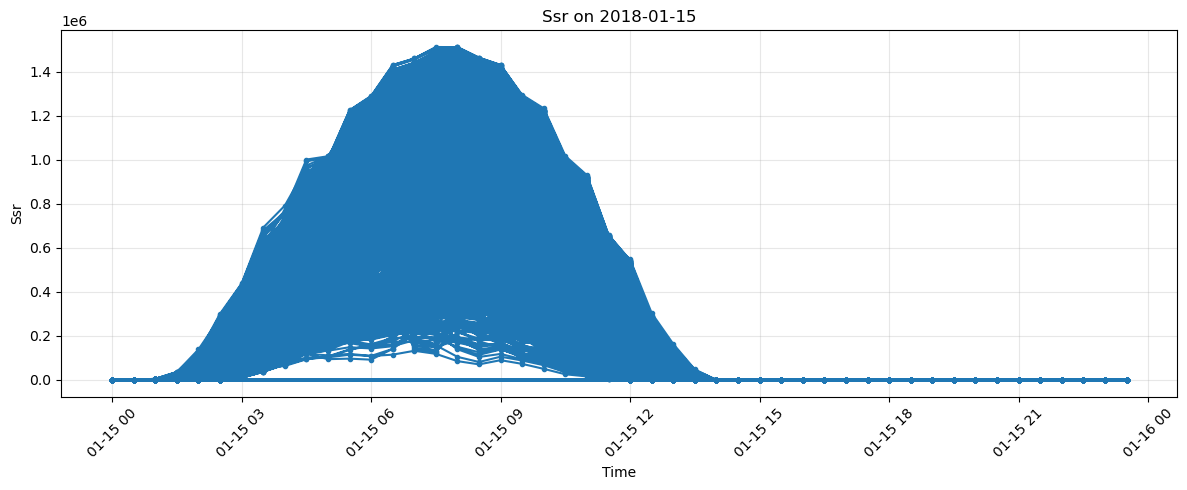

latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
8.25,77.25,2018-01-15 00:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.693634,-0.955475,-3.824417,-2.104919,297.192322,0.015228,0.0,0.0,0.015228,10.075371,0.611776,0.388224,2.026245,2.22937,1.2090e-13,0.0,0.0,0.0,-110911.09375,-140621.390625,674713.125,658792.375,0.0,0.0,-524939.125,-526919.9375,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 00:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.732788,-1.061333,-3.814346,-2.234207,297.279053,0.077164,0.0,0.0,0.077164,10.307629,0.611776,0.388224,2.026184,2.22937,1.2090e-13,0.0,0.0,0.0,-100788.15625,-142102.171875,686044.3125,658470.375,0.0,0.0,-524699.875,-526793.0,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 01:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.771942,-1.167191,-3.804276,-2.363495,297.365784,0.139099,0.0,0.0,0.139099,10.539886,0.611776,0.388224,2.026123,2.22937,2.8081e-28,0.0,0.0,0.0,-89386.476562,-142717.828125,698714.125,658066.375,0.0,0.0,-524236.125,-526734.4375,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 01:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.770615,-1.333435,-3.683792,-2.50798,297.519012,0.151718,0.0,0.0,0.151718,10.304398,0.611776,0.388224,2.026123,2.22937,3.6000e-12,0.0,0.0,0.0,-89558.648438,-146020.125,699793.125,656011.625,0.0,0.0,-524753.8125,-527184.5,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 02:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.769287,-1.49968,-3.563309,-2.652466,297.672241,0.164337,0.0,0.0,0.164337,10.068909,0.611776,0.388224,2.026123,2.22937,23338.603516,22736.205078,27255.773438,30551.970703,-98980.273438,-147485.515625,687417.125,654821.3125,56150.875,54743.953125,-525330.375,-527511.1875,14664.990234,13048.165039,2829.795898,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
35.25,78.0,2018-01-15 21:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.105476,1.539131,1.606201,4.357491,243.482849,0.014771,0.0,0.0,0.014771,-37.298222,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-78212.578125,-75887.8125,192833.265625,191643.75,0.0,0.0,-274083.28125,-272132.46875,0.0,0.0,0.0,0.0
35.25,78.0,2018-01-15 22:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.028397,1.451538,1.369034,4.264587,243.010529,0.022675,0.0,0.0,0.022675,-36.944191,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-77570.648438,-75580.265625,192710.09375,191812.875,0.0,0.0,-273951.3125,-272155.6875,0.0,0.0,0.0,0.0
35.25,78.0,2018-01-15 22:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.05336,1.426369,1.321899,4.194954,242.844635,0.028854,0.0,0.0,0.028854,-36.601288,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-75330.242188,-73935.164062,192593.515625,192066.125,0.0,0.0,-272921.65625,-271620.3125,0.0,0.0,0.0,0.0


In [ ]:
plot_day_polars_direct(step5_interpolated_boundary_fixed_data_2018_pldf, date='2018-01-15', column='ssr')

In [ ]:
plot_day_polars_direct(step5_interpolated_boundary_fixed_data_2018_pldf, date='2018-01-15', column='ssr')

In [ ]:
step7_processed_data_ADM1_pldf = pl.read_parquet(source=step7_processed_data_ADM1_path)

In [ ]:
print('Step 5 Interpolated Boundary Fixed Data First 8 rows:')
display(step7_processed_data_ADM1_pldf.head(8))
print('Step 5 Interpolated Boundary Fixed Data Last 8 rows:')
display(step7_processed_data_ADM1_pldf.tail(8))

In [ ]:
plot_day_polars_direct(step7_processed_data_ADM1_pldf, date='2025-12-30', column='ssr')

In [ ]:
plot_day_polars_direct(step7_processed_data_ADM1_pldf, date='2025-12-31', column='ssr')